# Specify your name here, if possible, student id number
Firstname Lastname

In [4]:
# Import necessary packages
import numpy as np
import cvxpy as cp # for modeling
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import reliability as rb # for generating distributions and sample from them.

### You may not have all the above packages in your environment.
### Please install them before you use this notebook.
### If you want to use cvxpy + gurobi, please install gurobi first before installing cvxpy
### installing gurobi requires a reboot of system.

(10000,)


(array([  1.,   0.,   1.,   1.,   2.,   2.,   1.,   3.,   7.,   5.,  12.,
         13.,  21.,  23.,  33.,  48.,  46.,  56.,  48.,  65.,  82., 111.,
        123., 134., 126., 164., 171., 214., 217., 225., 261., 276., 296.,
        245., 306., 308., 306., 303., 346., 304., 307., 321., 292., 289.,
        314., 293., 261., 255., 261., 224., 220., 195., 212., 156., 158.,
        133., 121., 117.,  98., 102.,  88.,  79.,  79.,  69.,  54.,  56.,
         33.,  43.,  32.,  26.,  28.,  29.,  24.,  15.,  22.,  10.,  14.,
          7.,   9.,  14.,   3.,   4.,   4.,   6.,   4.,   2.,   3.,   0.,
          3.,   0.,   1.,   2.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([3.7383933 , 3.78141347, 3.82443364, 3.86745381, 3.91047398,
        3.95349415, 3.99651432, 4.03953449, 4.08255466, 4.12557483,
        4.168595  , 4.21161517, 4.25463534, 4.29765551, 4.34067568,
        4.38369585, 4.42671602, 4.46973619, 4.51275636, 4.55577653,
        4.5987967 , 4.64181687, 4.68483704, 4.

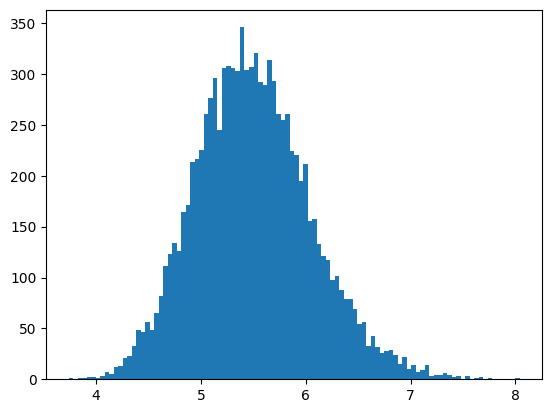

In [5]:
# A small example of constructing distributions and sampling for data: block 1.

# construct the distribution object by reliability package
dist_block_1 = rb.Distributions.Lognormal_Distribution(1.7, 0.1)

# take 10,000 samples from it by calling .random_samples
samp_block_1 = dist_block_1.random_samples(10000) 

# pay attention to the shape.
print(samp_block_1.shape) 

# visualize the samples, not necessary.
plt.hist(samp_block_1, bins = 100)


## Task 1 (5pt)
- Constructing your model for task 1 in the follow code block
- solve your model without advanced algorithm and a small number of samples, 100
- output the objective value and $x$ 

Shape of demand scenarios: (100, 3)


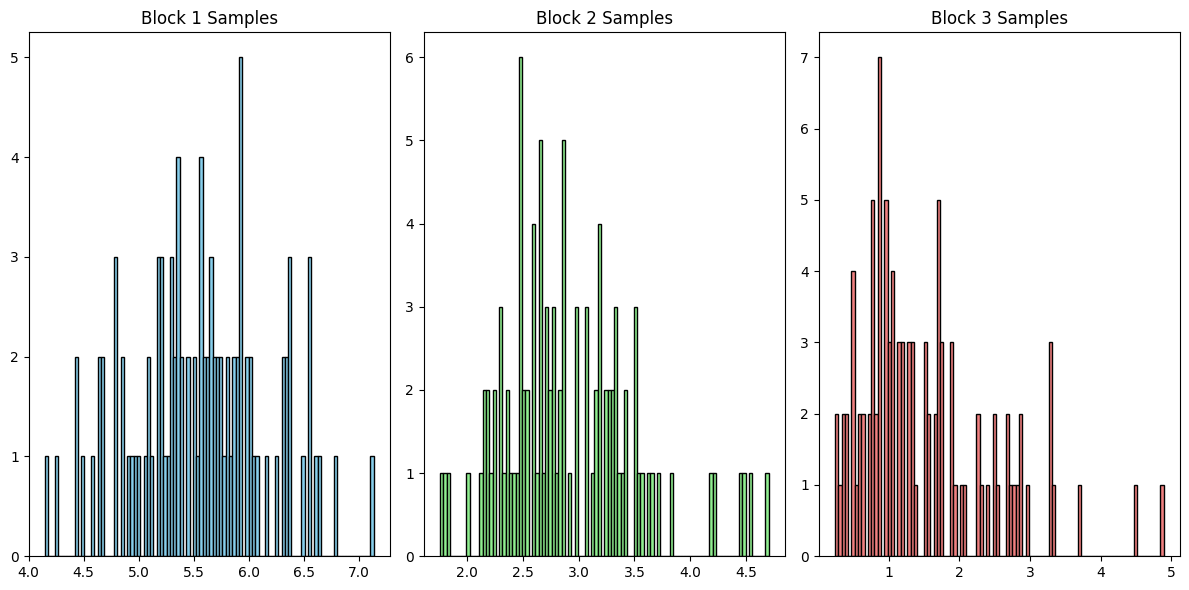

In [6]:
# Number of generator types and load blocks
J = 4  # Generator types: coal, gas, nuclear, oil
I = 3  # Load blocks: base, medium, peak

# Costs (in €/MWh)
c_inv = np.array([16, 5, 32, 2])  # Investment costs
c_prod = np.array([25, 80, 6.5, 160])  # Production costs
c_penl = np.array([180, 200, 220])  # Load shedding costs

# Load curve weights (normalized)
beta = np.array([1, 0.8, 0.25])

# Minimum capacity to be installed
P = 15


# Parameters for the distributions
mu_1, sigma_1 = 1.7, 0.1
mu_2, sigma_2 = 1.0, 0.2
mu_3, sigma_3 = 0.2, 0.6

# Construct the distribution objects
dist_block_1 = rb.Distributions.Lognormal_Distribution(mu_1, sigma_1)
dist_block_2 = rb.Distributions.Lognormal_Distribution(mu_2, sigma_2)
dist_block_3 = rb.Distributions.Lognormal_Distribution(mu_3, sigma_3)


# Number of scenarios to generate
num_scenarios = 100

# Generate samples from each distribution
samp_block_1 = dist_block_1.random_samples(num_scenarios)
samp_block_2 = dist_block_2.random_samples(num_scenarios)
samp_block_3 = dist_block_3.random_samples(num_scenarios)

# Combine scenarios into a matrix
demand_scenarios = np.vstack((samp_block_1, samp_block_2, samp_block_3)).T

# Print the shape of the demand scenarios matrix
print("Shape of demand scenarios:", demand_scenarios.shape)


# Visualize the samples
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.hist(samp_block_1, bins=100, color='skyblue', edgecolor='black')
plt.title('Block 1 Samples')

plt.subplot(1, 3, 2)
plt.hist(samp_block_2, bins=100, color='lightgreen', edgecolor='black')
plt.title('Block 2 Samples')

plt.subplot(1, 3, 3)
plt.hist(samp_block_3, bins=100, color='lightcoral', edgecolor='black')
plt.title('Block 3 Samples')

plt.tight_layout()
plt.show()


In [7]:

# Create a new Gurobi model
model = gp.Model("StochasticPowerGeneration")

# First-stage variables: generator capacities
x = model.addVars(J, name="x", lb=0)

# Second-stage variables: power generation and load shedding for each scenario
y = model.addVars(I, J, len(demand_scenarios), name="y", lb=0)
p = model.addVars(I, len(demand_scenarios), name="p", lb=0)

# Capacity constraint
model.addConstr(gp.quicksum(x[j] for j in range(J)) >= P, name="capacity_constraint")

# Generation capacity limit
for i in range(I):
    for j in range(J):
        for s in range(len(demand_scenarios)):
            model.addConstr(gp.quicksum(y[i, j, s] for i in range(I)) <= x[j], name=f"gen_capacity_{i}_{j}_{s}")

# Demand satisfaction
for i in range(I):
    for s in range(len(demand_scenarios)):
        model.addConstr(gp.quicksum(y[i, j, s] for j in range(J)) + p[i, s] >= demand_scenarios[s, i], name=f"demand_{i}_{s}")


# Total cost: investment + expected production + expected load shedding penalty
total_cost = gp.quicksum(c_inv[j] * x[j] for j in range(J))
total_cost += gp.quicksum(beta[i] * (c_prod[j] * y[i, j, s] + c_penl[i] * p[i, s]) / num_scenarios for i in range(I) for j in range(J) for s in range(len(demand_scenarios)))
# total_cost += gp.quicksum(beta[i] * (c_prod[j] * y[i, j, s] + c_penl[i] * p[i, s]) * probabilities[s] for i in range(I) for j in range(J) for s in range(len(demand_scenarios)))

# Set the objective
model.setObjective(total_cost, GRB.MINIMIZE)


# Optimize the model
model.optimize()

# Output the results
if model.status == GRB.OPTIMAL:
    print("Optimal generator capacities:")
    for j in range(J):
        print(f"Generator {j+1}: {x[j].x}")
    print("Total expected cost:", model.objVal)
else:
    print("No optimal solution found.")



Set parameter Username
Set parameter LicenseID to value 2615848
Academic license - for non-commercial use only - expires 2026-01-28
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Manjaro Linux")

CPU model: Intel(R) Core(TM) i5-1035G4 CPU @ 1.10GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1501 rows, 1504 columns and 6304 nonzeros
Model fingerprint: 0x5f184e3b
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-02, 3e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-01, 2e+01]
Presolve removed 800 rows and 200 columns
Presolve time: 0.01s
Presolved: 701 rows, 1304 columns, 2904 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.011470e+03   0.000000e+00      0s
     591    3.7688545e+02   0.000000e+00   0.000000e+00      0s

Solved in 591 iterations and 0.02 seconds (0.01 work units)


In [8]:
x_val = [x[j].x for j in range(J)]
print(x_val)
np.sum(x_val)

[3.713969888811346, 1.700015665342395, 5.844126058628893, 3.741888387217366]


np.float64(15.0)

## Task 2 (5pt)
- You have solve the problem with a small number of samples to verify if your modeing is correct.
- Now you have to determine the number of samples $N$ for a stable results, which is way lager than 100.
- You should first design a mechanism to determine $N$ (either Lower/upper bound method with penalty, or chance-constraint without penalty).
- The $N$ probably is in the order of 1000. To solve such a large problem, you need advanced algorithms.
- In task 2, please design an algorithm to solve a large problem.
- Also report the results once the $N$ is determined and the problem is solved by your advanced algorithms.

In [9]:
def Benders_algorithm(num_scenarios):
    # === Problem Data ===
    # Number of generator types and load blocks
    J = 4  # Generator types: coal, gas, nuclear, oil
    I = 3  # Load blocks: base, medium, peak

    # Costs (in €/MWh)
    c_inv = np.array([16, 5, 32, 2])  # Investment costs
    c_prod = np.array([25, 80, 6.5, 160])  # Production costs
    c_penl = np.array([180, 200, 220])  # Load shedding costs

    # Load curve weights (normalized)
    beta = np.array([1, 0.8, 0.25])

    # Minimum capacity to be installed
    P = 15


    # Parameters for the distributions
    mu_1, sigma_1 = 1.7, 0.1
    mu_2, sigma_2 = 1.0, 0.2
    mu_3, sigma_3 = 0.2, 0.6

    # Construct the distribution objects
    dist_block_1 = rb.Distributions.Lognormal_Distribution(mu_1, sigma_1)
    dist_block_2 = rb.Distributions.Lognormal_Distribution(mu_2, sigma_2)
    dist_block_3 = rb.Distributions.Lognormal_Distribution(mu_3, sigma_3)

    # Generate samples from each distribution
    samp_block_1 = dist_block_1.random_samples(num_scenarios)
    samp_block_2 = dist_block_2.random_samples(num_scenarios)
    samp_block_3 = dist_block_3.random_samples(num_scenarios)

    # Combine scenarios into a matrix
    demand_scenarios = np.vstack((samp_block_1, samp_block_2, samp_block_3)).T

    # Print the shape of the demand scenarios matrix
    print("Shape of demand scenarios:", demand_scenarios.shape)


    # Visualize the samples
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.hist(samp_block_1, bins=100, color='skyblue', edgecolor='black')
    plt.title('Block 1 Samples')

    plt.subplot(1, 3, 2)
    plt.hist(samp_block_2, bins=100, color='lightgreen', edgecolor='black')
    plt.title('Block 2 Samples')

    plt.subplot(1, 3, 3)
    plt.hist(samp_block_3, bins=100, color='lightcoral', edgecolor='black')
    plt.title('Block 3 Samples')

    plt.tight_layout()
    plt.show()


    # === Solve Subproblem ===
    def solve_subproblem(x_val, demand):
        I, J = len(demand), len(x_val)
        sub = gp.Model("Sub")
        sub.setParam("OutputFlag", 0)

        y = sub.addVars(I, J, lb=0, name="y")
        p = sub.addVars(I, lb=0, name="p")

        demand_constrs = []
        for i in range(I):
            con = sub.addConstr(gp.quicksum(y[i, j] for j in range(J)) + p[i] >= demand[i],
                                name=f"demand_{i}")
            demand_constrs.append(con)

        gen_constrs = []
        for j in range(J):
            con = sub.addConstr(gp.quicksum(y[i, j] for i in range(I)) <= x_val[j],
                                name=f"gen_cap_{j}")
            gen_constrs.append(con)

        sub.setObjective(
            gp.quicksum(beta[i] * (
                gp.quicksum(c_prod[j] * y[i, j] for j in range(J)) + c_penl[i] * p[i]
            ) for i in range(I)), GRB.MINIMIZE
        )

        sub.optimize()

        if sub.status == GRB.OPTIMAL:
            obj_val = sub.ObjVal
            lambda_duals = [con.Pi for con in demand_constrs]
            mu_duals = [con.Pi for con in gen_constrs]
            return obj_val, lambda_duals, mu_duals
        else:
            return None, None, None


    # === Initialize Master Problem ===
    master = gp.Model("master")
    master.setParam("OutputFlag", 0)

    x = master.addVars(J, lb=0, name="x")
    theta = master.addVar(lb=-1e9, name="theta")

    master.addConstr(gp.quicksum(x[j] for j in range(J)) >= P)
    master.setObjective(gp.quicksum(c_inv[j] * x[j] for j in range(J)) + theta, GRB.MINIMIZE)

    # === Benders Loop ===
    max_iter = 50
    tolerance = 1e-3
    prev_obj = 1e10

    for it in range(max_iter):
        print(f"\n--- Iteration {it+1} ---")
        master.optimize()

        if master.status != GRB.OPTIMAL:
            print("Master problem not optimal.")
            break

        x_val = [x[j].x for j in range(J)]
        total_cost = 0
        cut_lhs = gp.LinExpr()
        cut_rhs = 0

        avg_cut_expr = 0
        avg_rhs = 0
        for s in range(num_scenarios):
            demand = demand_scenarios[s]
            obj, lambda_duals, mu_duals = solve_subproblem(x_val, demand)
            if obj is None:
                continue
            total_cost += obj / num_scenarios



            cut_expr = gp.LinExpr()
            for j in range(J):
                cut_expr += mu_duals[j] * x[j]
            rhs = sum(lambda_duals[i] * demand[i] for i in range(I))

            avg_cut_expr+=cut_expr/num_scenarios
            avg_rhs+=rhs/num_scenarios

        master.addConstr(theta >= (avg_cut_expr + avg_rhs), name=f"benders_cut_{it}_{s}")



        # Convergence check
        curr_obj = master.ObjVal
        print(f"Estimated total cost: {curr_obj:.4f}")
        if abs(curr_obj - prev_obj) < tolerance:
            print("Converged.")
            break
        prev_obj = curr_obj

    # === Final Output ===
    print("\n--- Final Solution ---")
    for j in range(J):
        print(f"Generator {j}: {x[j].x:.2f} MW")
    print(f"Expected second-stage cost (theta): {theta.x:.2f}")
    print(f"Total cost: {master.ObjVal:.2f}")

    return [x[j].x for j in range(J)], theta.x, master.ObjVal


Shape of demand scenarios: (1000, 3)


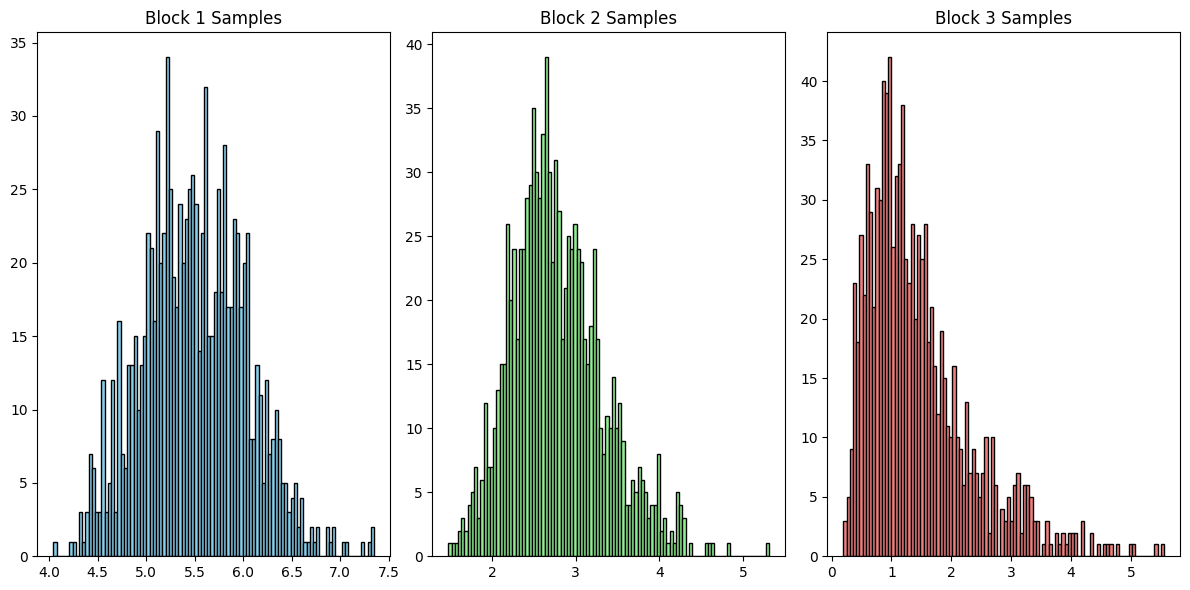


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937499919.1580

--- Iteration 3 ---
Estimated total cost: -709090720.9496

--- Iteration 4 ---
Estimated total cost: 325.0732

--- Iteration 5 ---
Estimated total cost: 331.7007

--- Iteration 6 ---
Estimated total cost: 345.7316

--- Iteration 7 ---
Estimated total cost: 348.8912

--- Iteration 8 ---
Estimated total cost: 348.9918

--- Iteration 9 ---
Estimated total cost: 352.0475

--- Iteration 10 ---
Estimated total cost: 358.4798

--- Iteration 11 ---
Estimated total cost: 363.3646

--- Iteration 12 ---
Estimated total cost: 364.0119

--- Iteration 13 ---
Estimated total cost: 365.7778

--- Iteration 14 ---
Estimated total cost: 365.9233

--- Iteration 15 ---
Estimated total cost: 366.1617

--- Iteration 16 ---
Estimated total cost: 366.5390

--- Iteration 17 ---
Estimated total cost: 366.5570

--- Iteration 18 ---
Estimated total cost: 366.6622

--- Iteration 19 ---
Estimated to

([3.566986474272048, 1.56687892393055, 5.77075216978456, 4.095382432012842],
 109.21902757562313,
 366.9800400807602)

In [11]:
Benders_algorithm(1000)

Shape of demand scenarios: (500, 3)


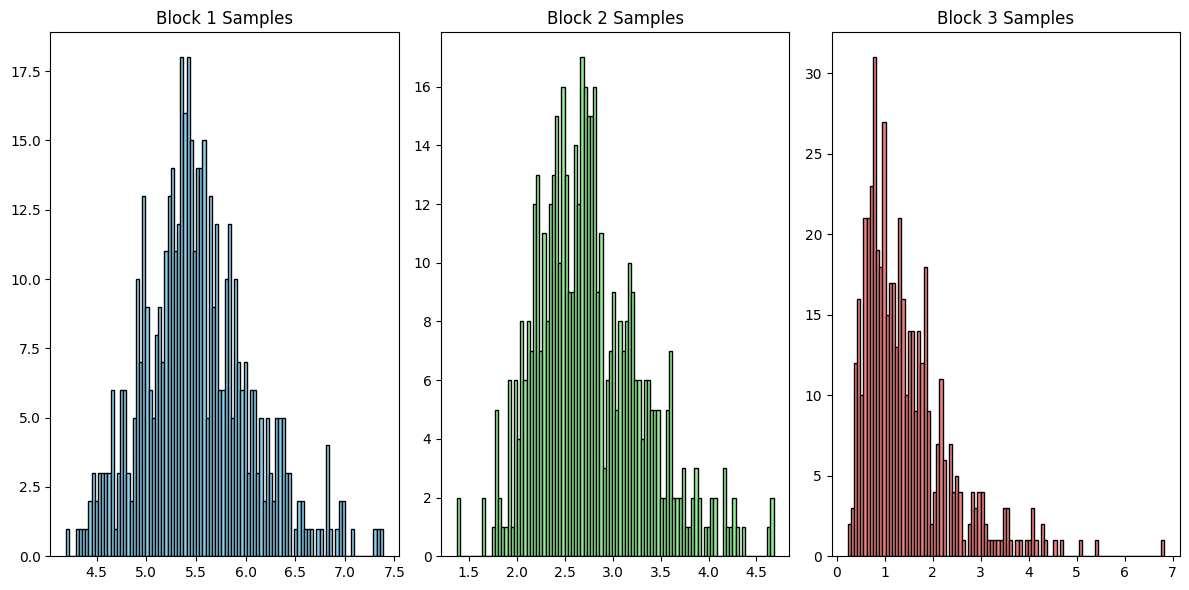


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937499919.2394

--- Iteration 3 ---
Estimated total cost: -709090721.1390

--- Iteration 4 ---
Estimated total cost: 324.7761

--- Iteration 5 ---
Estimated total cost: 331.5295

--- Iteration 6 ---
Estimated total cost: 344.9899

--- Iteration 7 ---
Estimated total cost: 348.3585

--- Iteration 8 ---
Estimated total cost: 348.8813

--- Iteration 9 ---
Estimated total cost: 352.1340

--- Iteration 10 ---
Estimated total cost: 358.0406

--- Iteration 11 ---
Estimated total cost: 363.0362

--- Iteration 12 ---
Estimated total cost: 363.7736

--- Iteration 13 ---
Estimated total cost: 366.2118

--- Iteration 14 ---
Estimated total cost: 366.2529

--- Iteration 15 ---
Estimated total cost: 366.3632

--- Iteration 16 ---
Estimated total cost: 366.3801

--- Iteration 17 ---
Estimated total cost: 366.5956

--- Iteration 18 ---
Estimated total cost: 366.6394

--- Iteration 19 ---
Estimated to

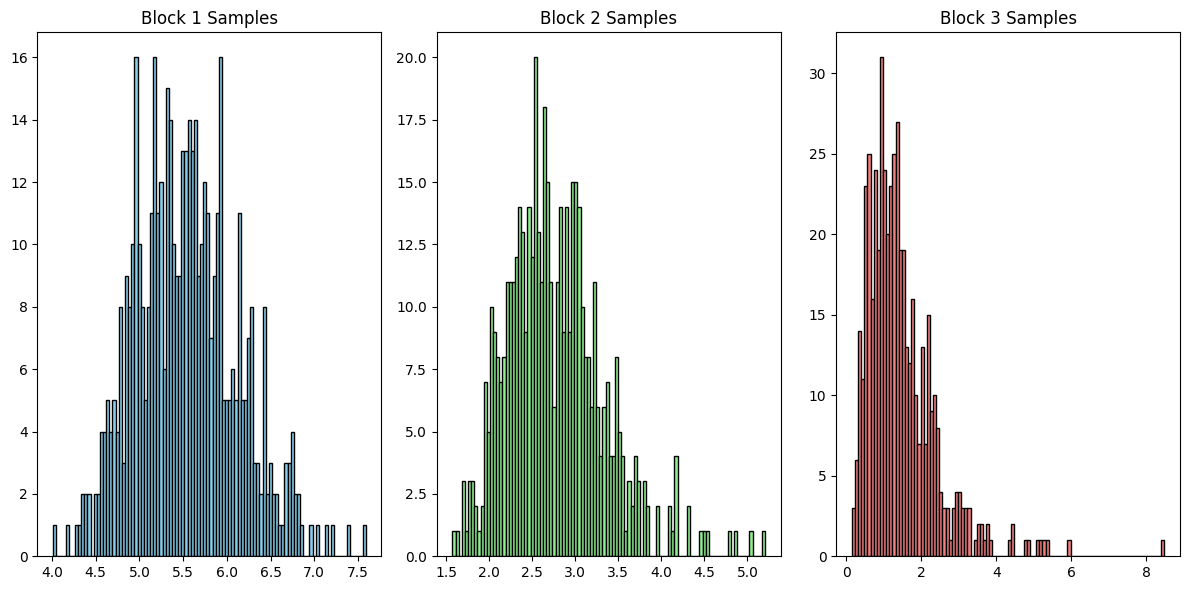


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937546758.7932

--- Iteration 3 ---
Estimated total cost: -709090720.4009

--- Iteration 4 ---
Estimated total cost: 325.9359

--- Iteration 5 ---
Estimated total cost: 332.7478

--- Iteration 6 ---
Estimated total cost: 346.6331

--- Iteration 7 ---
Estimated total cost: 350.1031

--- Iteration 8 ---
Estimated total cost: 350.3751

--- Iteration 9 ---
Estimated total cost: 353.9416

--- Iteration 10 ---
Estimated total cost: 359.9697

--- Iteration 11 ---
Estimated total cost: 365.5857

--- Iteration 12 ---
Estimated total cost: 365.6653

--- Iteration 13 ---
Estimated total cost: 367.7096

--- Iteration 14 ---
Estimated total cost: 367.9691

--- Iteration 15 ---
Estimated total cost: 368.0052

--- Iteration 16 ---
Estimated total cost: 368.1389

--- Iteration 17 ---
Estimated total cost: 368.5857

--- Iteration 18 ---
Estimated total cost: 368.5867

--- Iteration 19 ---
Estimated to

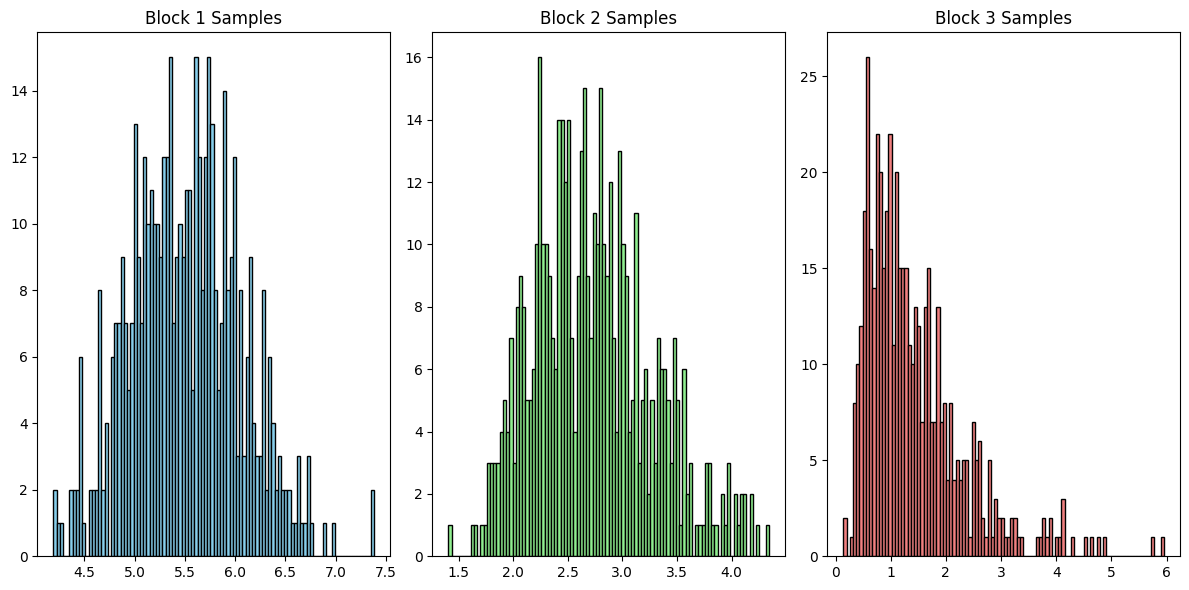


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937499919.5827

--- Iteration 3 ---
Estimated total cost: -709090721.9380

--- Iteration 4 ---
Estimated total cost: 323.5230

--- Iteration 5 ---
Estimated total cost: 330.2799

--- Iteration 6 ---
Estimated total cost: 343.6575

--- Iteration 7 ---
Estimated total cost: 347.1071

--- Iteration 8 ---
Estimated total cost: 347.6303

--- Iteration 9 ---
Estimated total cost: 350.9143

--- Iteration 10 ---
Estimated total cost: 356.9863

--- Iteration 11 ---
Estimated total cost: 362.0947

--- Iteration 12 ---
Estimated total cost: 362.5022

--- Iteration 13 ---
Estimated total cost: 364.4581

--- Iteration 14 ---
Estimated total cost: 364.4913

--- Iteration 15 ---
Estimated total cost: 364.7013

--- Iteration 16 ---
Estimated total cost: 364.9620

--- Iteration 17 ---
Estimated total cost: 364.9974

--- Iteration 18 ---
Estimated total cost: 365.1293

--- Iteration 19 ---
Estimated to

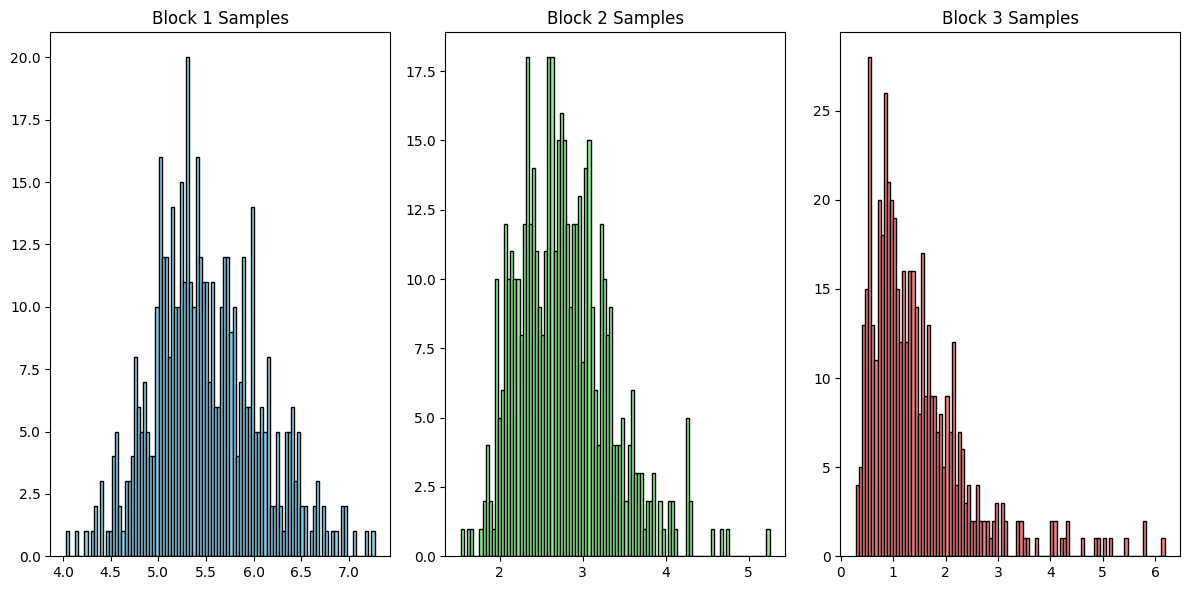


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937523347.9510

--- Iteration 3 ---
Estimated total cost: -709090721.1301

--- Iteration 4 ---
Estimated total cost: 324.7907

--- Iteration 5 ---
Estimated total cost: 331.5940

--- Iteration 6 ---
Estimated total cost: 345.3719

--- Iteration 7 ---
Estimated total cost: 348.8864

--- Iteration 8 ---
Estimated total cost: 349.3444

--- Iteration 9 ---
Estimated total cost: 352.6433

--- Iteration 10 ---
Estimated total cost: 359.0335

--- Iteration 11 ---
Estimated total cost: 365.0533

--- Iteration 12 ---
Estimated total cost: 365.1129

--- Iteration 13 ---
Estimated total cost: 367.1452

--- Iteration 14 ---
Estimated total cost: 367.3168

--- Iteration 15 ---
Estimated total cost: 367.4768

--- Iteration 16 ---
Estimated total cost: 367.7838

--- Iteration 17 ---
Estimated total cost: 367.8153

--- Iteration 18 ---
Estimated total cost: 367.9398

--- Iteration 19 ---
Estimated to

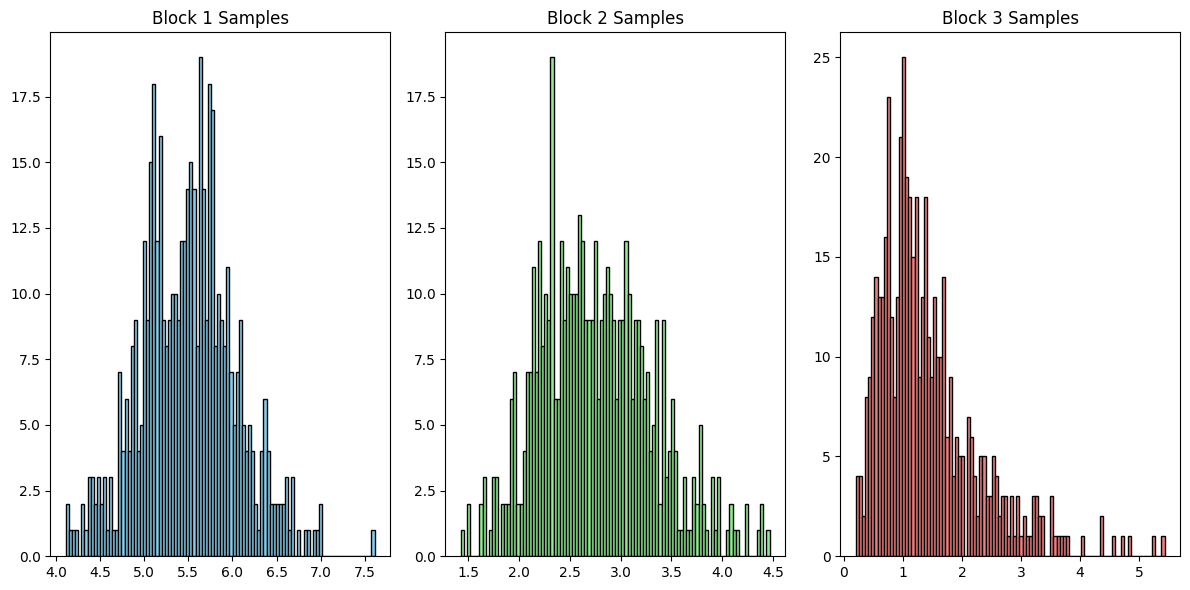


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937499919.4325

--- Iteration 3 ---
Estimated total cost: -709090721.5884

--- Iteration 4 ---
Estimated total cost: 324.0713

--- Iteration 5 ---
Estimated total cost: 330.6602

--- Iteration 6 ---
Estimated total cost: 344.6098

--- Iteration 7 ---
Estimated total cost: 347.7493

--- Iteration 8 ---
Estimated total cost: 347.7515

--- Iteration 9 ---
Estimated total cost: 350.8195

--- Iteration 10 ---
Estimated total cost: 357.2496

--- Iteration 11 ---
Estimated total cost: 361.8215

--- Iteration 12 ---
Estimated total cost: 362.6883

--- Iteration 13 ---
Estimated total cost: 363.9538

--- Iteration 14 ---
Estimated total cost: 364.2470

--- Iteration 15 ---
Estimated total cost: 364.5581

--- Iteration 16 ---
Estimated total cost: 365.1402

--- Iteration 17 ---
Estimated total cost: 365.1612

--- Iteration 18 ---
Estimated total cost: 365.1893

--- Iteration 19 ---
Estimated to

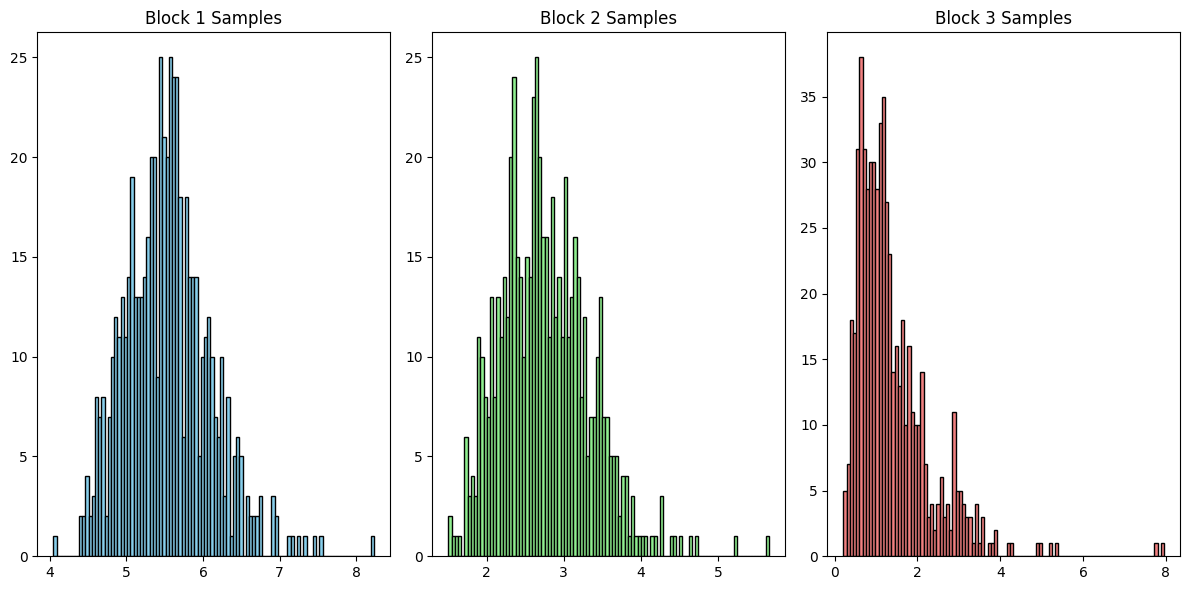


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937558458.0487

--- Iteration 3 ---
Estimated total cost: -709090720.9915

--- Iteration 4 ---
Estimated total cost: 325.0090

--- Iteration 5 ---
Estimated total cost: 331.6048

--- Iteration 6 ---
Estimated total cost: 346.3383

--- Iteration 7 ---
Estimated total cost: 349.1645

--- Iteration 8 ---
Estimated total cost: 349.3090

--- Iteration 9 ---
Estimated total cost: 351.7003

--- Iteration 10 ---
Estimated total cost: 358.7091

--- Iteration 11 ---
Estimated total cost: 364.7370

--- Iteration 12 ---
Estimated total cost: 365.2297

--- Iteration 13 ---
Estimated total cost: 365.6555

--- Iteration 14 ---
Estimated total cost: 366.0119

--- Iteration 15 ---
Estimated total cost: 367.0465

--- Iteration 16 ---
Estimated total cost: 367.4627

--- Iteration 17 ---
Estimated total cost: 367.4830

--- Iteration 18 ---
Estimated total cost: 367.5989

--- Iteration 19 ---
Estimated to

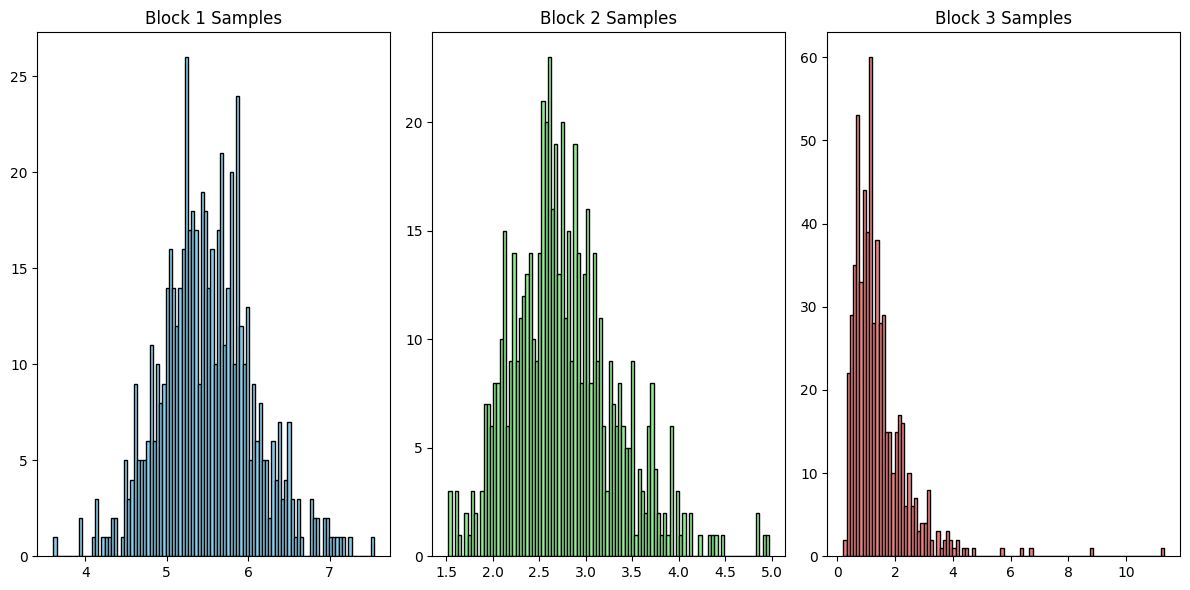


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937538957.3768

--- Iteration 3 ---
Estimated total cost: -709090721.2372

--- Iteration 4 ---
Estimated total cost: 324.6279

--- Iteration 5 ---
Estimated total cost: 331.2275

--- Iteration 6 ---
Estimated total cost: 345.7315

--- Iteration 7 ---
Estimated total cost: 348.6026

--- Iteration 8 ---
Estimated total cost: 348.7351

--- Iteration 9 ---
Estimated total cost: 351.0293

--- Iteration 10 ---
Estimated total cost: 357.1996

--- Iteration 11 ---
Estimated total cost: 363.3407

--- Iteration 12 ---
Estimated total cost: 364.0085

--- Iteration 13 ---
Estimated total cost: 364.4094

--- Iteration 14 ---
Estimated total cost: 365.1378

--- Iteration 15 ---
Estimated total cost: 365.6863

--- Iteration 16 ---
Estimated total cost: 366.4522

--- Iteration 17 ---
Estimated total cost: 366.5302

--- Iteration 18 ---
Estimated total cost: 366.6871

--- Iteration 19 ---
Estimated to

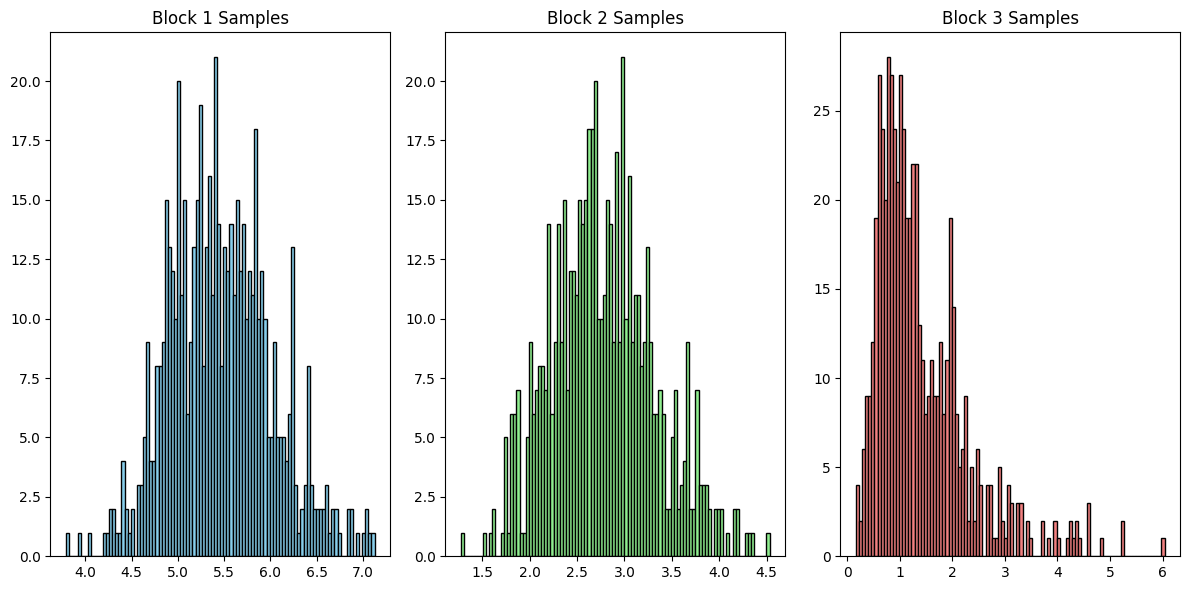


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937499919.6240

--- Iteration 3 ---
Estimated total cost: -709090722.0341

--- Iteration 4 ---
Estimated total cost: 323.3724

--- Iteration 5 ---
Estimated total cost: 329.9061

--- Iteration 6 ---
Estimated total cost: 344.7719

--- Iteration 7 ---
Estimated total cost: 347.3457

--- Iteration 8 ---
Estimated total cost: 347.4414

--- Iteration 9 ---
Estimated total cost: 349.5026

--- Iteration 10 ---
Estimated total cost: 356.3487

--- Iteration 11 ---
Estimated total cost: 362.8731

--- Iteration 12 ---
Estimated total cost: 363.1044

--- Iteration 13 ---
Estimated total cost: 363.2952

--- Iteration 14 ---
Estimated total cost: 363.4778

--- Iteration 15 ---
Estimated total cost: 364.6193

--- Iteration 16 ---
Estimated total cost: 365.2676

--- Iteration 17 ---
Estimated total cost: 365.2720

--- Iteration 18 ---
Estimated total cost: 365.3777

--- Iteration 19 ---
Estimated to

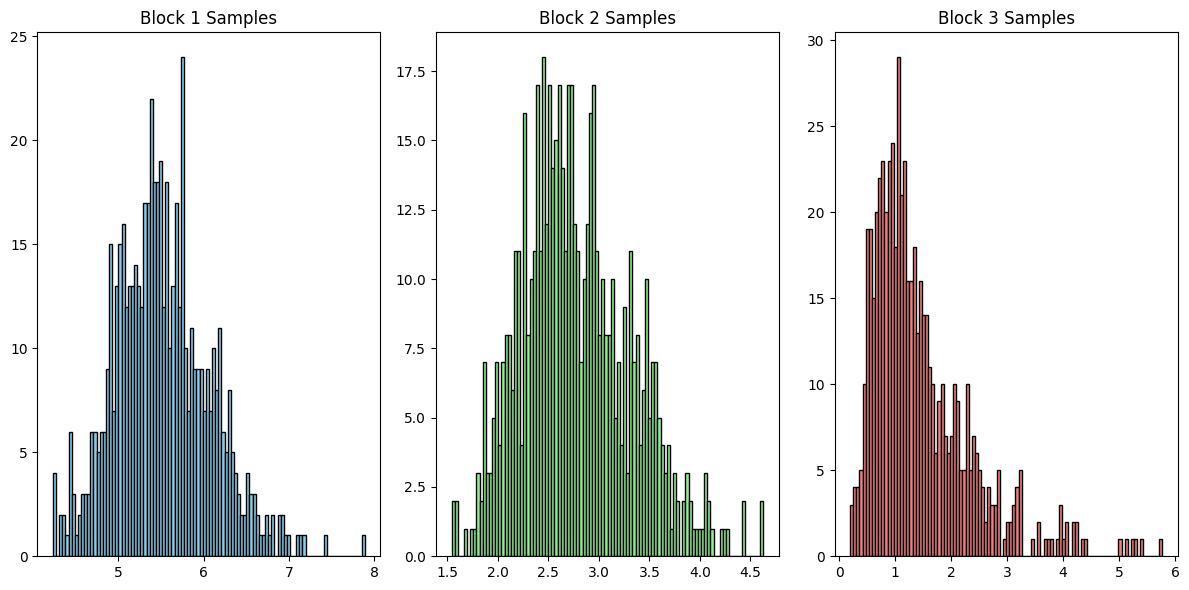


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937519444.1734

--- Iteration 3 ---
Estimated total cost: -709090720.6364

--- Iteration 4 ---
Estimated total cost: 325.5646

--- Iteration 5 ---
Estimated total cost: 332.1912

--- Iteration 6 ---
Estimated total cost: 346.3154

--- Iteration 7 ---
Estimated total cost: 349.5680

--- Iteration 8 ---
Estimated total cost: 349.5833

--- Iteration 9 ---
Estimated total cost: 352.9272

--- Iteration 10 ---
Estimated total cost: 359.3942

--- Iteration 11 ---
Estimated total cost: 364.1251

--- Iteration 12 ---
Estimated total cost: 364.9099

--- Iteration 13 ---
Estimated total cost: 366.8237

--- Iteration 14 ---
Estimated total cost: 367.0191

--- Iteration 15 ---
Estimated total cost: 367.1722

--- Iteration 16 ---
Estimated total cost: 367.4745

--- Iteration 17 ---
Estimated total cost: 367.4780

--- Iteration 18 ---
Estimated total cost: 367.5796

--- Iteration 19 ---
Estimated to

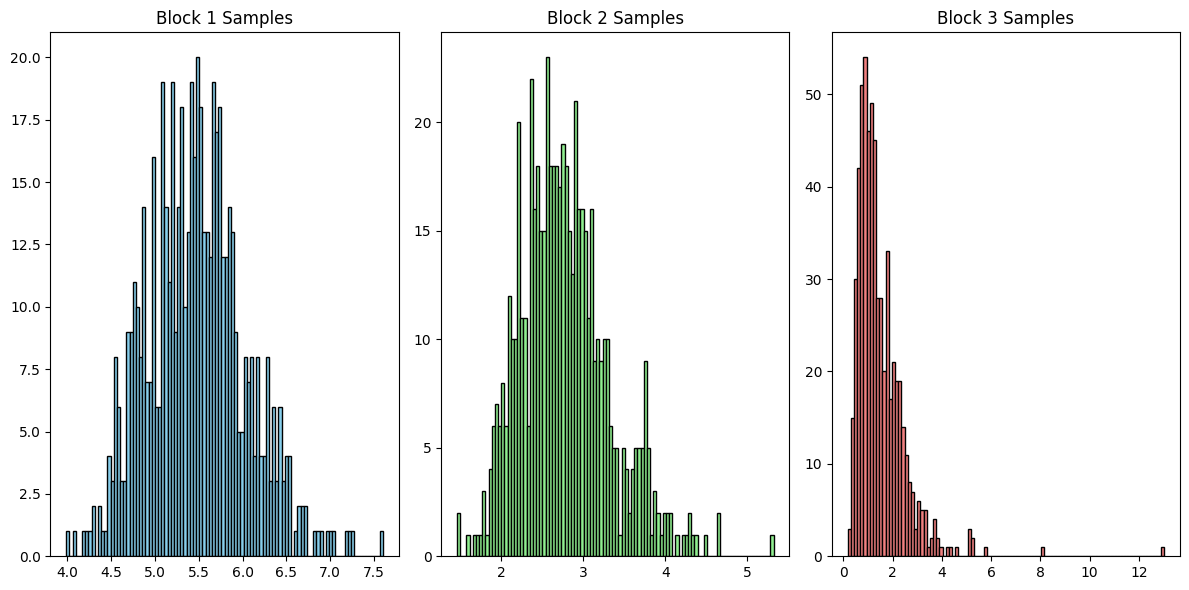


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937538957.5034

--- Iteration 3 ---
Estimated total cost: -709090721.5348

--- Iteration 4 ---
Estimated total cost: 324.1618

--- Iteration 5 ---
Estimated total cost: 330.6442

--- Iteration 6 ---
Estimated total cost: 345.7363

--- Iteration 7 ---
Estimated total cost: 348.1082

--- Iteration 8 ---
Estimated total cost: 348.2847

--- Iteration 9 ---
Estimated total cost: 350.2720

--- Iteration 10 ---
Estimated total cost: 358.2069

--- Iteration 11 ---
Estimated total cost: 364.8071

--- Iteration 12 ---
Estimated total cost: 364.8399

--- Iteration 13 ---
Estimated total cost: 365.0852

--- Iteration 14 ---
Estimated total cost: 365.1305

--- Iteration 15 ---
Estimated total cost: 365.2104

--- Iteration 16 ---
Estimated total cost: 365.9756

--- Iteration 17 ---
Estimated total cost: 366.4949

--- Iteration 18 ---
Estimated total cost: 366.5799

--- Iteration 19 ---
Estimated to

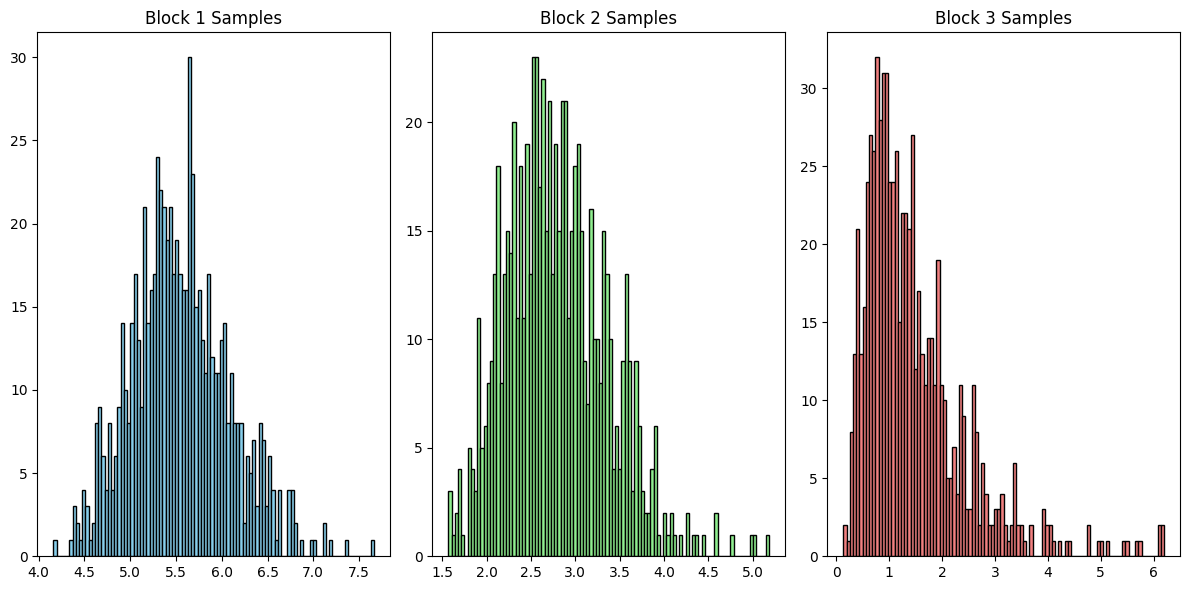


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937499918.5634

--- Iteration 3 ---
Estimated total cost: -709090719.5656

--- Iteration 4 ---
Estimated total cost: 327.2438

--- Iteration 5 ---
Estimated total cost: 333.8237

--- Iteration 6 ---
Estimated total cost: 348.6470

--- Iteration 7 ---
Estimated total cost: 351.3851

--- Iteration 8 ---
Estimated total cost: 351.4230

--- Iteration 9 ---
Estimated total cost: 354.1588

--- Iteration 10 ---
Estimated total cost: 361.0840

--- Iteration 11 ---
Estimated total cost: 366.7709

--- Iteration 12 ---
Estimated total cost: 367.1841

--- Iteration 13 ---
Estimated total cost: 368.8213

--- Iteration 14 ---
Estimated total cost: 368.8389

--- Iteration 15 ---
Estimated total cost: 369.3728

--- Iteration 16 ---
Estimated total cost: 369.4547

--- Iteration 17 ---
Estimated total cost: 369.8059

--- Iteration 18 ---
Estimated total cost: 369.8786

--- Iteration 19 ---
Estimated to

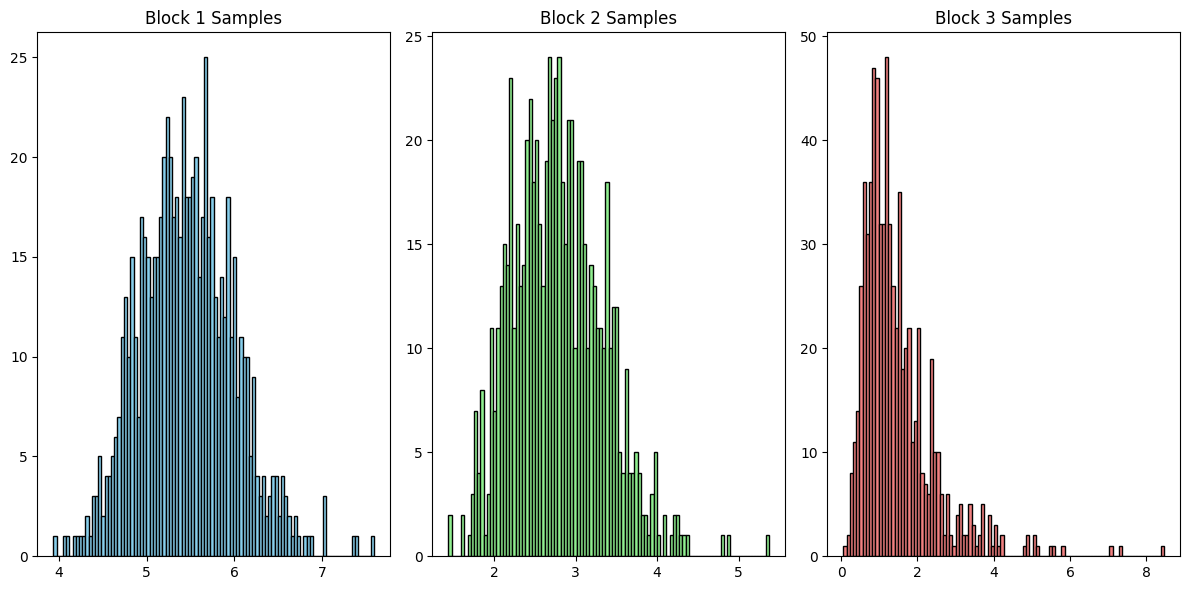


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937564955.9148

--- Iteration 3 ---
Estimated total cost: -709090721.7313

--- Iteration 4 ---
Estimated total cost: 323.8504

--- Iteration 5 ---
Estimated total cost: 330.5265

--- Iteration 6 ---
Estimated total cost: 344.9078

--- Iteration 7 ---
Estimated total cost: 348.1124

--- Iteration 8 ---
Estimated total cost: 348.1547

--- Iteration 9 ---
Estimated total cost: 351.2699

--- Iteration 10 ---
Estimated total cost: 358.3464

--- Iteration 11 ---
Estimated total cost: 364.1132

--- Iteration 12 ---
Estimated total cost: 364.4365

--- Iteration 13 ---
Estimated total cost: 365.5170

--- Iteration 14 ---
Estimated total cost: 365.7608

--- Iteration 15 ---
Estimated total cost: 366.4589

--- Iteration 16 ---
Estimated total cost: 366.4742

--- Iteration 17 ---
Estimated total cost: 366.5639

--- Iteration 18 ---
Estimated total cost: 366.7383

--- Iteration 19 ---
Estimated to

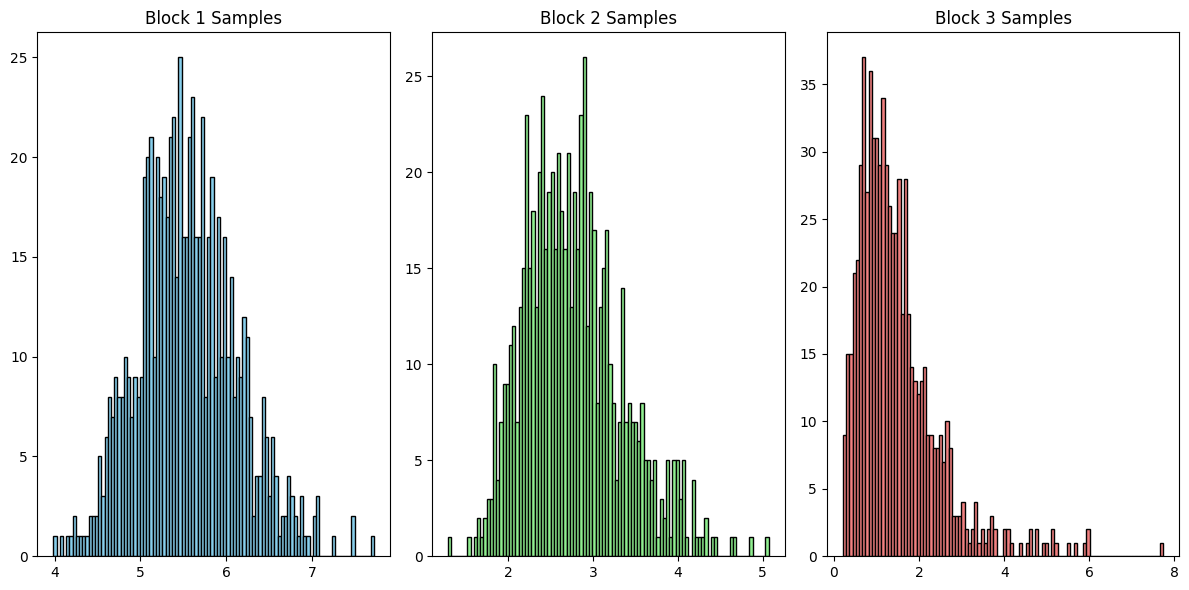


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937532453.8545

--- Iteration 3 ---
Estimated total cost: -709090719.9206

--- Iteration 4 ---
Estimated total cost: 326.6885

--- Iteration 5 ---
Estimated total cost: 333.5732

--- Iteration 6 ---
Estimated total cost: 347.5055

--- Iteration 7 ---
Estimated total cost: 350.9957

--- Iteration 8 ---
Estimated total cost: 351.5414

--- Iteration 9 ---
Estimated total cost: 354.9131

--- Iteration 10 ---
Estimated total cost: 361.2187

--- Iteration 11 ---
Estimated total cost: 367.0458

--- Iteration 12 ---
Estimated total cost: 367.3499

--- Iteration 13 ---
Estimated total cost: 369.4879

--- Iteration 14 ---
Estimated total cost: 369.5251

--- Iteration 15 ---
Estimated total cost: 369.7406

--- Iteration 16 ---
Estimated total cost: 370.0409

--- Iteration 17 ---
Estimated total cost: 370.0423

--- Iteration 18 ---
Estimated total cost: 370.0733

--- Iteration 19 ---
Estimated to

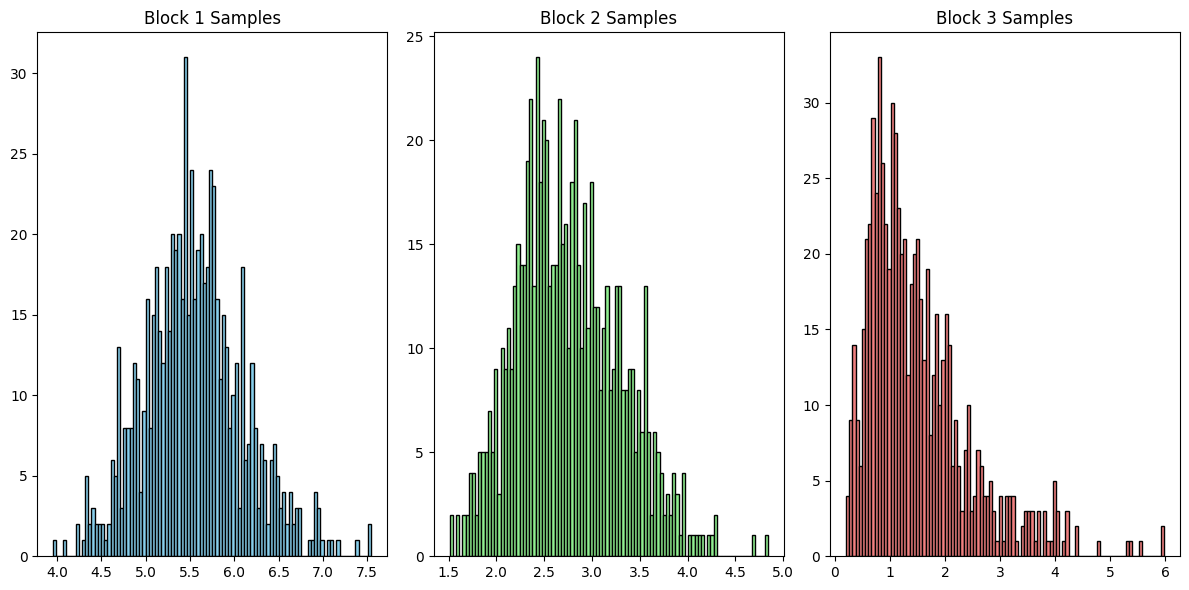


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937516190.5780

--- Iteration 3 ---
Estimated total cost: -709090720.0524

--- Iteration 4 ---
Estimated total cost: 326.4805

--- Iteration 5 ---
Estimated total cost: 333.1779

--- Iteration 6 ---
Estimated total cost: 347.5427

--- Iteration 7 ---
Estimated total cost: 350.5172

--- Iteration 8 ---
Estimated total cost: 350.8985

--- Iteration 9 ---
Estimated total cost: 353.7567

--- Iteration 10 ---
Estimated total cost: 360.4564

--- Iteration 11 ---
Estimated total cost: 366.3091

--- Iteration 12 ---
Estimated total cost: 366.4527

--- Iteration 13 ---
Estimated total cost: 368.1570

--- Iteration 14 ---
Estimated total cost: 368.2562

--- Iteration 15 ---
Estimated total cost: 368.7770

--- Iteration 16 ---
Estimated total cost: 368.7963

--- Iteration 17 ---
Estimated total cost: 369.1274

--- Iteration 18 ---
Estimated total cost: 369.2419

--- Iteration 19 ---
Estimated to

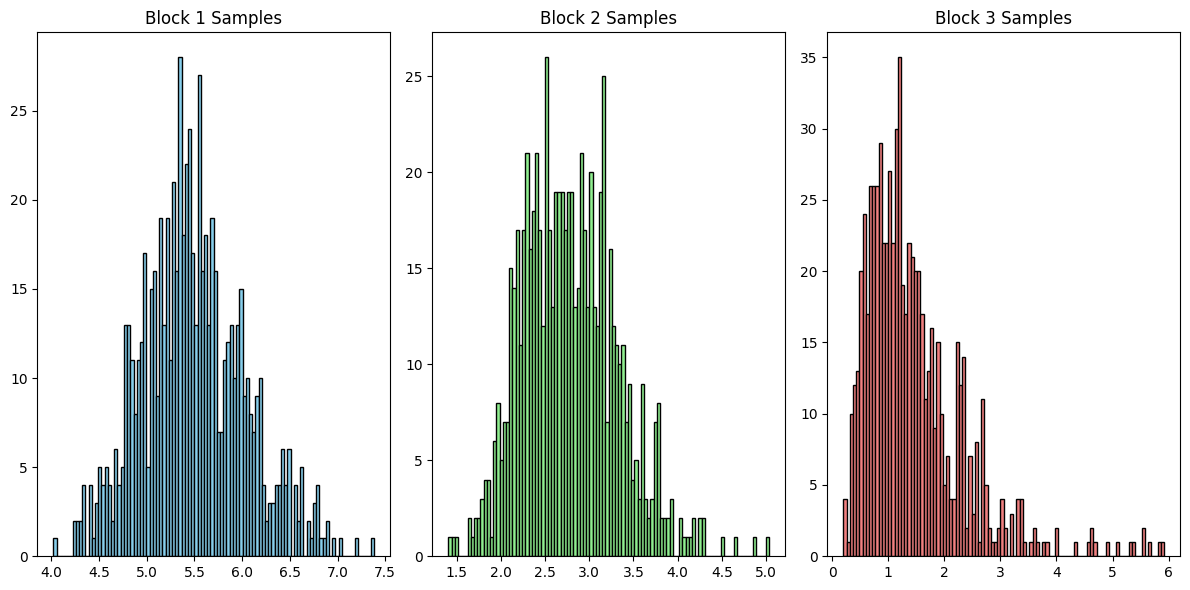


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937499919.3246

--- Iteration 3 ---
Estimated total cost: -709090721.3371

--- Iteration 4 ---
Estimated total cost: 324.4654

--- Iteration 5 ---
Estimated total cost: 331.1829

--- Iteration 6 ---
Estimated total cost: 345.1496

--- Iteration 7 ---
Estimated total cost: 348.3711

--- Iteration 8 ---
Estimated total cost: 348.7183

--- Iteration 9 ---
Estimated total cost: 351.8494

--- Iteration 10 ---
Estimated total cost: 358.3290

--- Iteration 11 ---
Estimated total cost: 364.1637

--- Iteration 12 ---
Estimated total cost: 364.2094

--- Iteration 13 ---
Estimated total cost: 365.6671

--- Iteration 14 ---
Estimated total cost: 365.9364

--- Iteration 15 ---
Estimated total cost: 366.3154

--- Iteration 16 ---
Estimated total cost: 366.4292

--- Iteration 17 ---
Estimated total cost: 366.8484

--- Iteration 18 ---
Estimated total cost: 366.9105

--- Iteration 19 ---
Estimated to

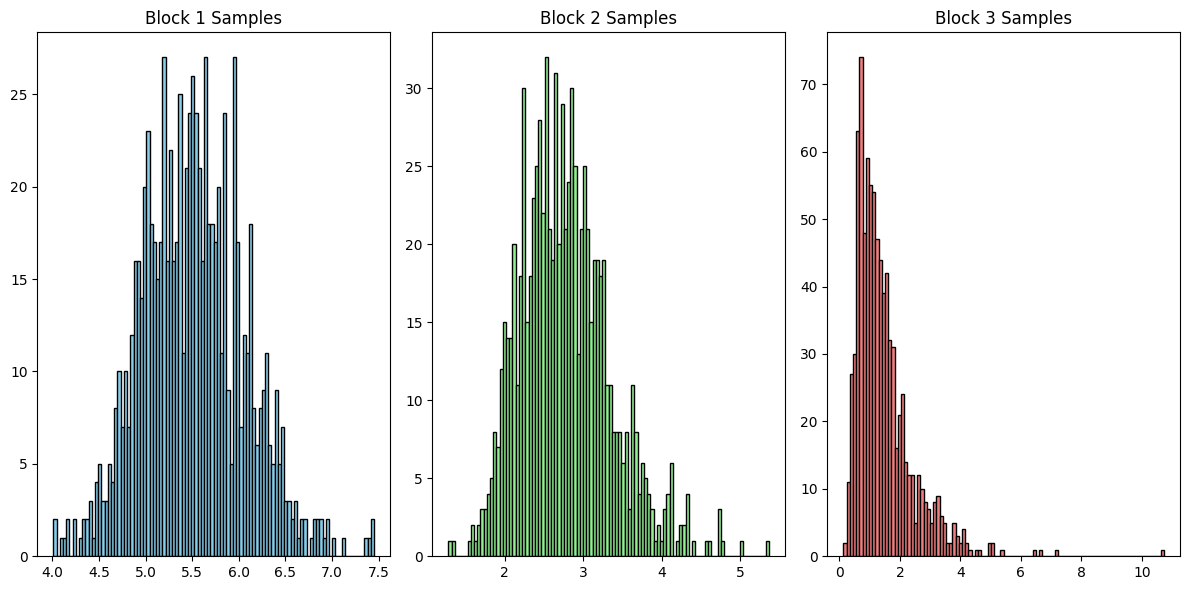


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937540582.7459

--- Iteration 3 ---
Estimated total cost: -709090720.8569

--- Iteration 4 ---
Estimated total cost: 325.2226

--- Iteration 5 ---
Estimated total cost: 332.1357

--- Iteration 6 ---
Estimated total cost: 346.1386

--- Iteration 7 ---
Estimated total cost: 349.6466

--- Iteration 8 ---
Estimated total cost: 350.0759

--- Iteration 9 ---
Estimated total cost: 353.3598

--- Iteration 10 ---
Estimated total cost: 359.9034

--- Iteration 11 ---
Estimated total cost: 365.6324

--- Iteration 12 ---
Estimated total cost: 365.8923

--- Iteration 13 ---
Estimated total cost: 367.5393

--- Iteration 14 ---
Estimated total cost: 367.6800

--- Iteration 15 ---
Estimated total cost: 368.1919

--- Iteration 16 ---
Estimated total cost: 368.1940

--- Iteration 17 ---
Estimated total cost: 368.4164

--- Iteration 18 ---
Estimated total cost: 368.5248

--- Iteration 19 ---
Estimated to

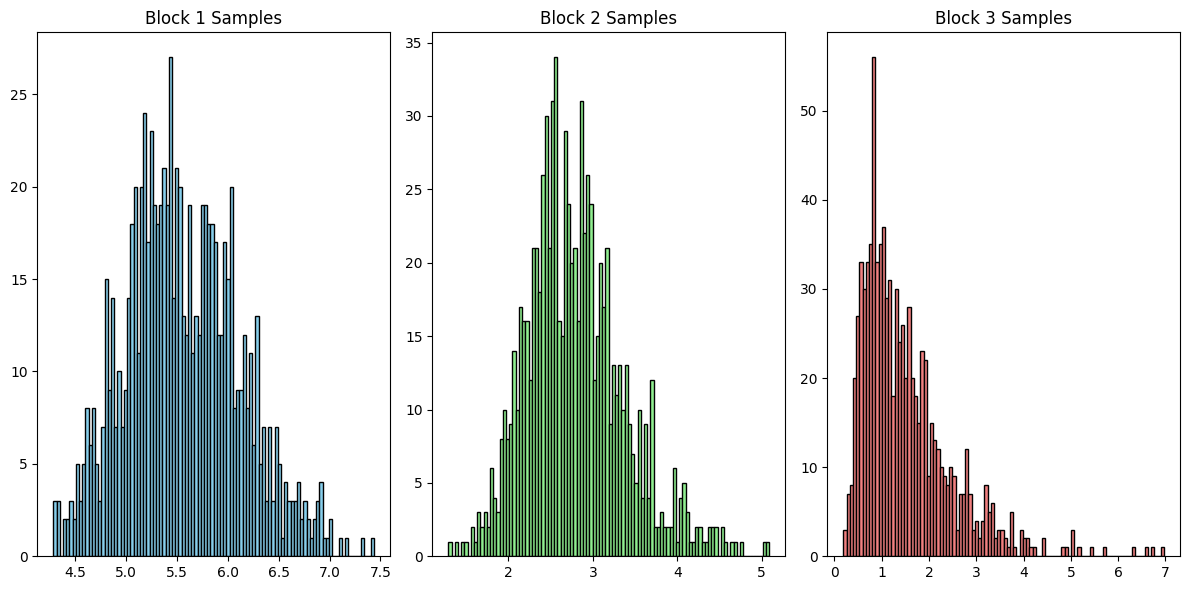


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937554124.7825

--- Iteration 3 ---
Estimated total cost: -709090719.0965

--- Iteration 4 ---
Estimated total cost: 327.9814

--- Iteration 5 ---
Estimated total cost: 334.9142

--- Iteration 6 ---
Estimated total cost: 348.8945

--- Iteration 7 ---
Estimated total cost: 352.5061

--- Iteration 8 ---
Estimated total cost: 352.8716

--- Iteration 9 ---
Estimated total cost: 356.1795

--- Iteration 10 ---
Estimated total cost: 362.9421

--- Iteration 11 ---
Estimated total cost: 368.4768

--- Iteration 12 ---
Estimated total cost: 368.8854

--- Iteration 13 ---
Estimated total cost: 370.4000

--- Iteration 14 ---
Estimated total cost: 370.4658

--- Iteration 15 ---
Estimated total cost: 370.9390

--- Iteration 16 ---
Estimated total cost: 371.0362

--- Iteration 17 ---
Estimated total cost: 371.3087

--- Iteration 18 ---
Estimated total cost: 371.4234

--- Iteration 19 ---
Estimated to

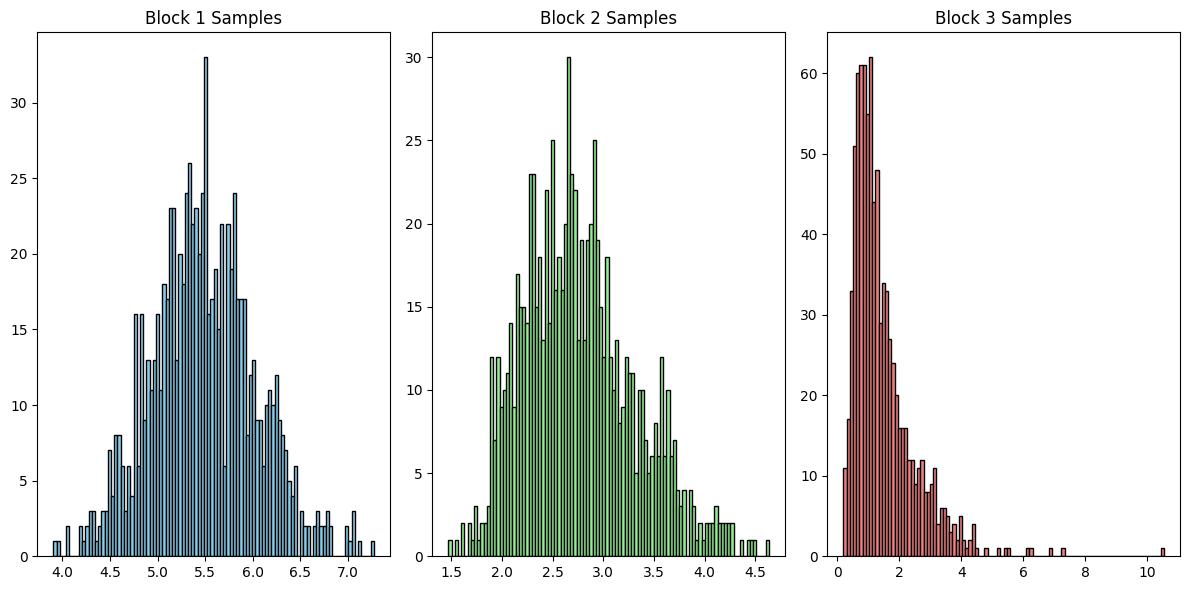


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937554125.8761

--- Iteration 3 ---
Estimated total cost: -709090721.6539

--- Iteration 4 ---
Estimated total cost: 323.9731

--- Iteration 5 ---
Estimated total cost: 330.8147

--- Iteration 6 ---
Estimated total cost: 344.8418

--- Iteration 7 ---
Estimated total cost: 348.5354

--- Iteration 8 ---
Estimated total cost: 348.7310

--- Iteration 9 ---
Estimated total cost: 352.2851

--- Iteration 10 ---
Estimated total cost: 358.9483

--- Iteration 11 ---
Estimated total cost: 364.8975

--- Iteration 12 ---
Estimated total cost: 365.0531

--- Iteration 13 ---
Estimated total cost: 366.7037

--- Iteration 14 ---
Estimated total cost: 366.8812

--- Iteration 15 ---
Estimated total cost: 367.1739

--- Iteration 16 ---
Estimated total cost: 367.2638

--- Iteration 17 ---
Estimated total cost: 367.3871

--- Iteration 18 ---
Estimated total cost: 367.6716

--- Iteration 19 ---
Estimated to

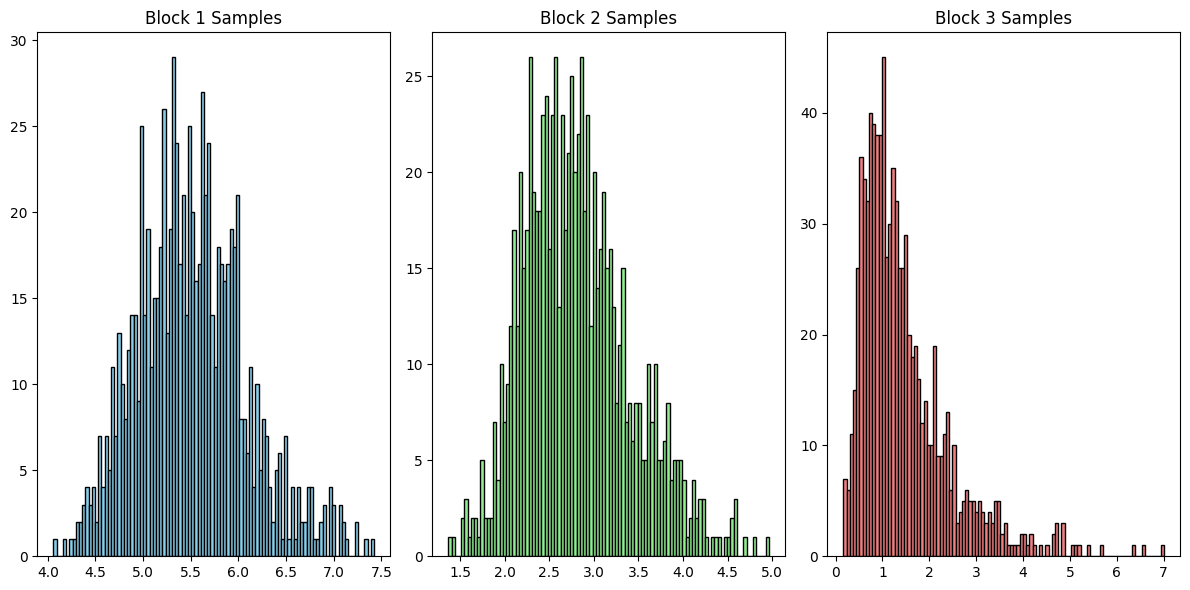


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937540582.4046

--- Iteration 3 ---
Estimated total cost: -709090720.0513

--- Iteration 4 ---
Estimated total cost: 326.4832

--- Iteration 5 ---
Estimated total cost: 333.3754

--- Iteration 6 ---
Estimated total cost: 347.9087

--- Iteration 7 ---
Estimated total cost: 351.0684

--- Iteration 8 ---
Estimated total cost: 351.5528

--- Iteration 9 ---
Estimated total cost: 354.4821

--- Iteration 10 ---
Estimated total cost: 361.1302

--- Iteration 11 ---
Estimated total cost: 367.6857

--- Iteration 12 ---
Estimated total cost: 367.7335

--- Iteration 13 ---
Estimated total cost: 369.3953

--- Iteration 14 ---
Estimated total cost: 369.7348

--- Iteration 15 ---
Estimated total cost: 369.9976

--- Iteration 16 ---
Estimated total cost: 370.1793

--- Iteration 17 ---
Estimated total cost: 370.6320

--- Iteration 18 ---
Estimated total cost: 370.6491

--- Iteration 19 ---
Estimated to

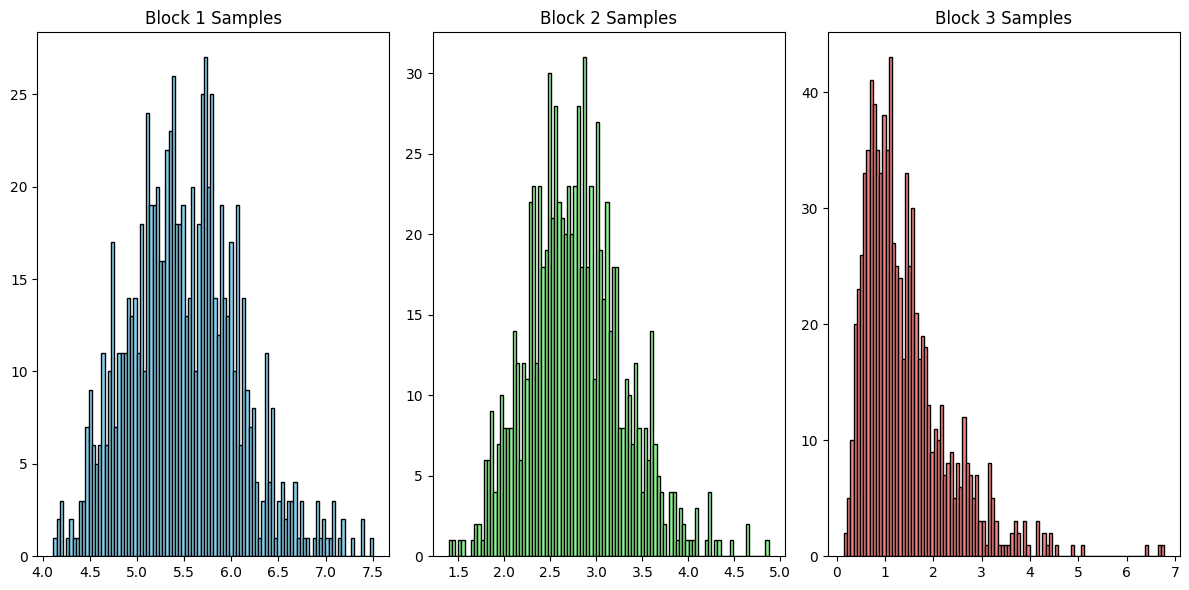


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937527034.2873

--- Iteration 3 ---
Estimated total cost: -709090721.3242

--- Iteration 4 ---
Estimated total cost: 324.4867

--- Iteration 5 ---
Estimated total cost: 331.3009

--- Iteration 6 ---
Estimated total cost: 345.1014

--- Iteration 7 ---
Estimated total cost: 348.3485

--- Iteration 8 ---
Estimated total cost: 348.8085

--- Iteration 9 ---
Estimated total cost: 352.0166

--- Iteration 10 ---
Estimated total cost: 357.8939

--- Iteration 11 ---
Estimated total cost: 363.1776

--- Iteration 12 ---
Estimated total cost: 363.4382

--- Iteration 13 ---
Estimated total cost: 365.9577

--- Iteration 14 ---
Estimated total cost: 365.9607

--- Iteration 15 ---
Estimated total cost: 366.0228

--- Iteration 16 ---
Estimated total cost: 366.0235
Converged.

--- Final Solution ---
Generator 0: 3.85 MW
Generator 1: 1.86 MW
Generator 2: 5.49 MW
Generator 3: 3.80 MW
Expected second-stage

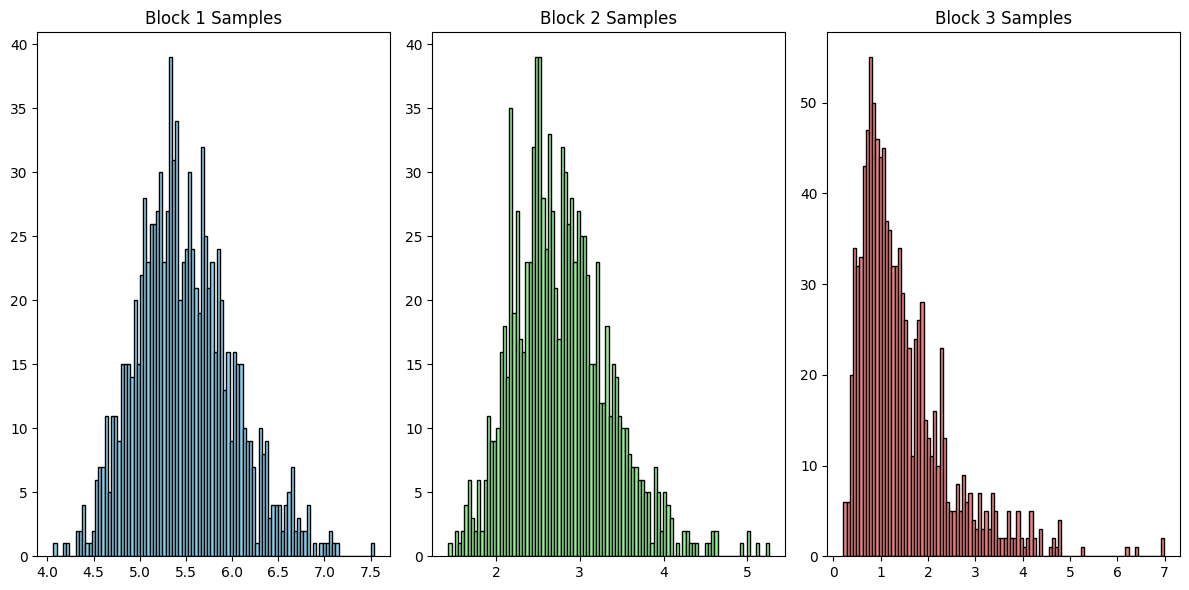


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937511228.7466

--- Iteration 3 ---
Estimated total cost: -709090721.1819

--- Iteration 4 ---
Estimated total cost: 324.7089

--- Iteration 5 ---
Estimated total cost: 331.3296

--- Iteration 6 ---
Estimated total cost: 345.9721

--- Iteration 7 ---
Estimated total cost: 348.7245

--- Iteration 8 ---
Estimated total cost: 349.0686

--- Iteration 9 ---
Estimated total cost: 351.7475

--- Iteration 10 ---
Estimated total cost: 358.3371

--- Iteration 11 ---
Estimated total cost: 364.6857

--- Iteration 12 ---
Estimated total cost: 364.7294

--- Iteration 13 ---
Estimated total cost: 366.5958

--- Iteration 14 ---
Estimated total cost: 366.8686

--- Iteration 15 ---
Estimated total cost: 367.0812

--- Iteration 16 ---
Estimated total cost: 367.4635

--- Iteration 17 ---
Estimated total cost: 367.5076

--- Iteration 18 ---
Estimated total cost: 367.6396

--- Iteration 19 ---
Estimated to

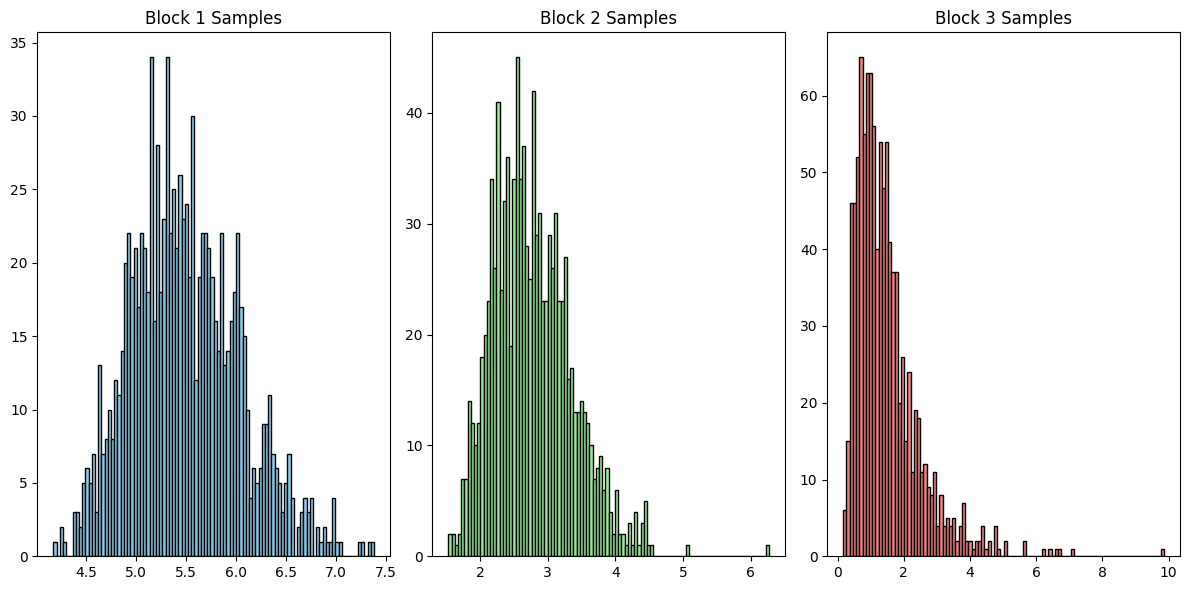


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937533835.3711

--- Iteration 3 ---
Estimated total cost: -709090721.0050

--- Iteration 4 ---
Estimated total cost: 324.9882

--- Iteration 5 ---
Estimated total cost: 331.7350

--- Iteration 6 ---
Estimated total cost: 346.0678

--- Iteration 7 ---
Estimated total cost: 349.0573

--- Iteration 8 ---
Estimated total cost: 349.5602

--- Iteration 9 ---
Estimated total cost: 352.5072

--- Iteration 10 ---
Estimated total cost: 358.8121

--- Iteration 11 ---
Estimated total cost: 364.9236

--- Iteration 12 ---
Estimated total cost: 365.2218

--- Iteration 13 ---
Estimated total cost: 367.5990

--- Iteration 14 ---
Estimated total cost: 367.6621

--- Iteration 15 ---
Estimated total cost: 367.7906

--- Iteration 16 ---
Estimated total cost: 367.9476

--- Iteration 17 ---
Estimated total cost: 367.9922

--- Iteration 18 ---
Estimated total cost: 368.2448

--- Iteration 19 ---
Estimated to

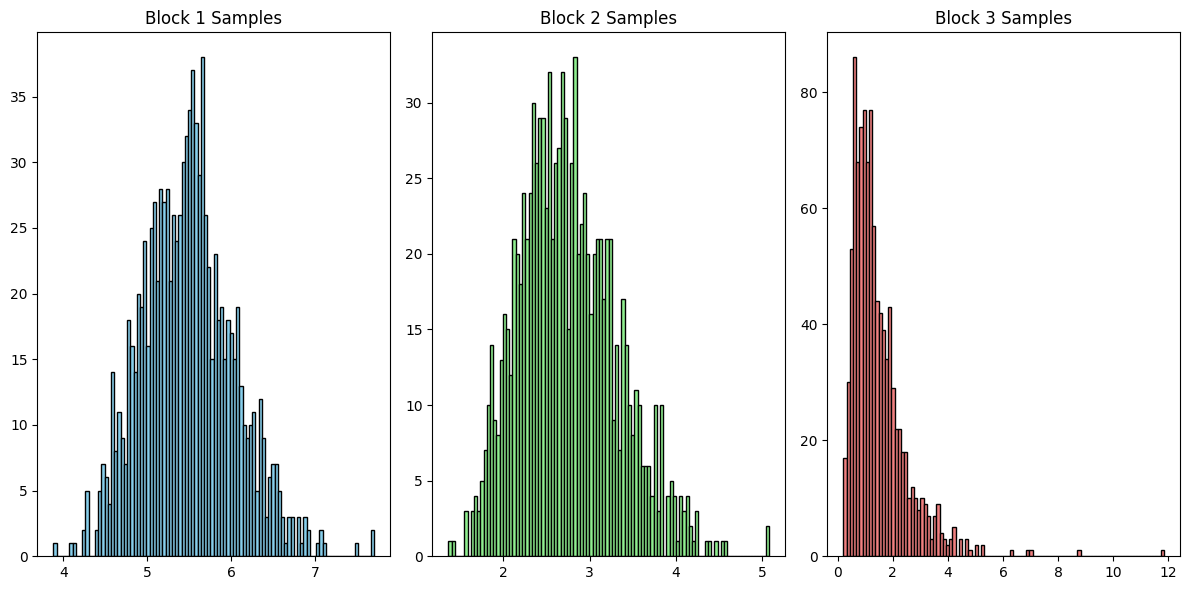


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937533835.6567

--- Iteration 3 ---
Estimated total cost: -709090721.6801

--- Iteration 4 ---
Estimated total cost: 323.9320

--- Iteration 5 ---
Estimated total cost: 330.8275

--- Iteration 6 ---
Estimated total cost: 344.3367

--- Iteration 7 ---
Estimated total cost: 348.0362

--- Iteration 8 ---
Estimated total cost: 348.5726

--- Iteration 9 ---
Estimated total cost: 352.2593

--- Iteration 10 ---
Estimated total cost: 358.4498

--- Iteration 11 ---
Estimated total cost: 364.0593

--- Iteration 12 ---
Estimated total cost: 364.2098

--- Iteration 13 ---
Estimated total cost: 366.1407

--- Iteration 14 ---
Estimated total cost: 366.2120

--- Iteration 15 ---
Estimated total cost: 366.4709

--- Iteration 16 ---
Estimated total cost: 366.6977

--- Iteration 17 ---
Estimated total cost: 366.8748

--- Iteration 18 ---
Estimated total cost: 366.8851

--- Iteration 19 ---
Estimated to

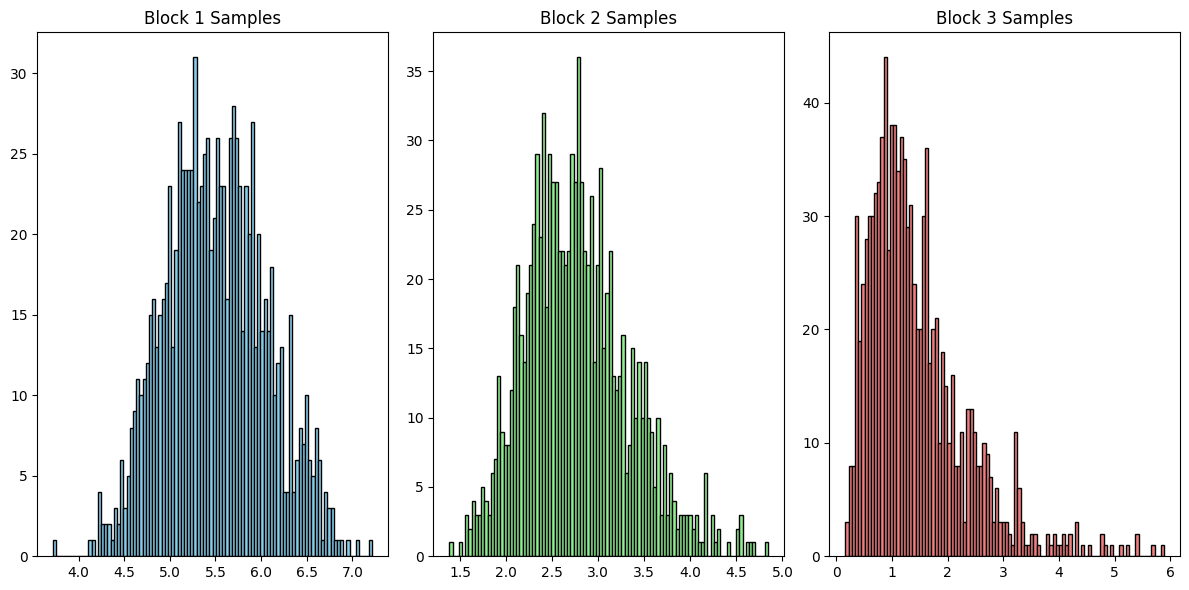


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937511228.7663

--- Iteration 3 ---
Estimated total cost: -709090721.2276

--- Iteration 4 ---
Estimated total cost: 324.6372

--- Iteration 5 ---
Estimated total cost: 331.3650

--- Iteration 6 ---
Estimated total cost: 345.5527

--- Iteration 7 ---
Estimated total cost: 348.5804

--- Iteration 8 ---
Estimated total cost: 348.9027

--- Iteration 9 ---
Estimated total cost: 351.7915

--- Iteration 10 ---
Estimated total cost: 358.2377

--- Iteration 11 ---
Estimated total cost: 363.2240

--- Iteration 12 ---
Estimated total cost: 364.0144

--- Iteration 13 ---
Estimated total cost: 365.6898

--- Iteration 14 ---
Estimated total cost: 366.0625

--- Iteration 15 ---
Estimated total cost: 366.1878

--- Iteration 16 ---
Estimated total cost: 366.3658

--- Iteration 17 ---
Estimated total cost: 366.6000

--- Iteration 18 ---
Estimated total cost: 366.6212

--- Iteration 19 ---
Estimated to

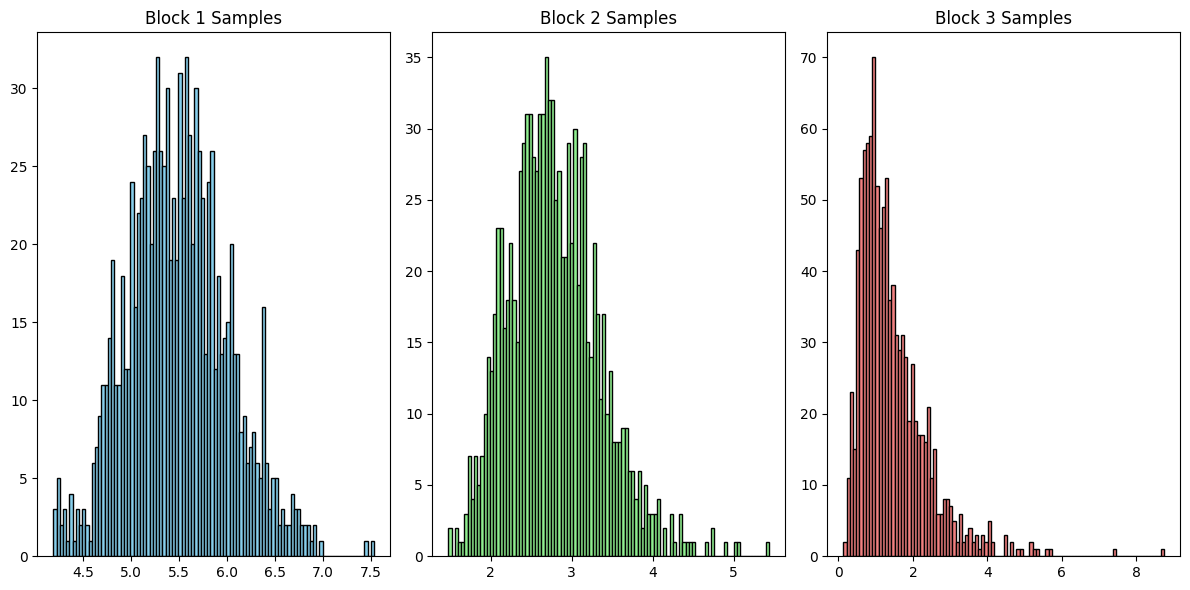


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937522534.1353

--- Iteration 3 ---
Estimated total cost: -709090721.1700

--- Iteration 4 ---
Estimated total cost: 324.7293

--- Iteration 5 ---
Estimated total cost: 331.3569

--- Iteration 6 ---
Estimated total cost: 345.6964

--- Iteration 7 ---
Estimated total cost: 348.7724

--- Iteration 8 ---
Estimated total cost: 348.8271

--- Iteration 9 ---
Estimated total cost: 351.2607

--- Iteration 10 ---
Estimated total cost: 358.3001

--- Iteration 11 ---
Estimated total cost: 364.1556

--- Iteration 12 ---
Estimated total cost: 364.6021

--- Iteration 13 ---
Estimated total cost: 364.7251

--- Iteration 14 ---
Estimated total cost: 365.2432

--- Iteration 15 ---
Estimated total cost: 366.3183

--- Iteration 16 ---
Estimated total cost: 366.5022

--- Iteration 17 ---
Estimated total cost: 366.5529

--- Iteration 18 ---
Estimated total cost: 366.8232

--- Iteration 19 ---
Estimated to

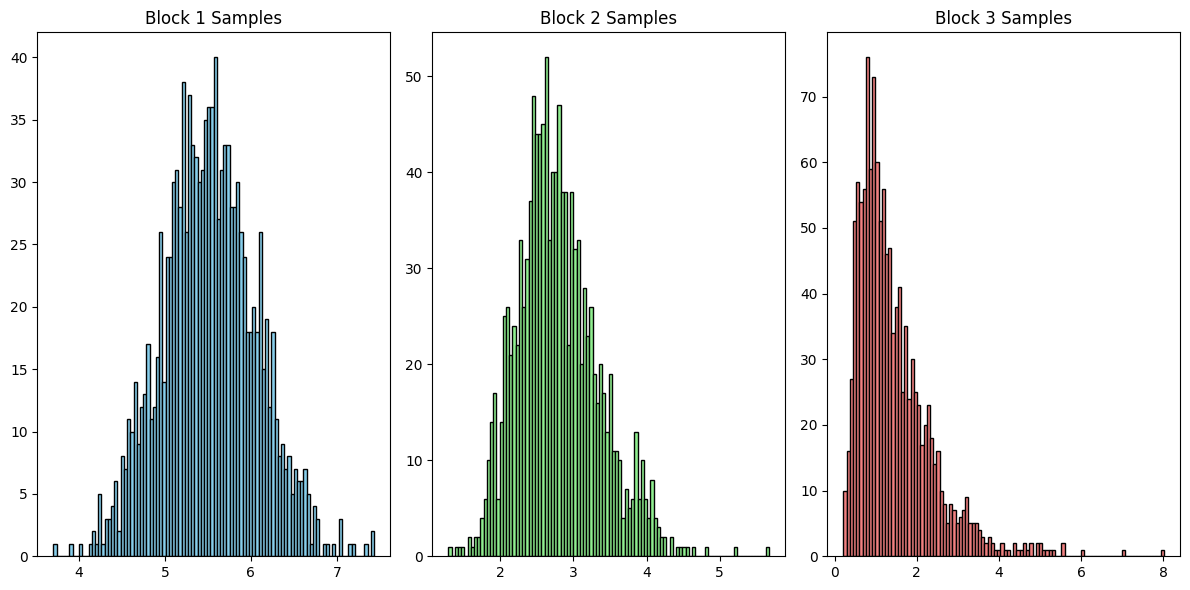


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937509337.8193

--- Iteration 3 ---
Estimated total cost: -709090720.6335

--- Iteration 4 ---
Estimated total cost: 325.5697

--- Iteration 5 ---
Estimated total cost: 332.3483

--- Iteration 6 ---
Estimated total cost: 346.5569

--- Iteration 7 ---
Estimated total cost: 349.5603

--- Iteration 8 ---
Estimated total cost: 350.0029

--- Iteration 9 ---
Estimated total cost: 352.9492

--- Iteration 10 ---
Estimated total cost: 359.1918

--- Iteration 11 ---
Estimated total cost: 364.4277

--- Iteration 12 ---
Estimated total cost: 365.0021

--- Iteration 13 ---
Estimated total cost: 367.2071

--- Iteration 14 ---
Estimated total cost: 367.3822

--- Iteration 15 ---
Estimated total cost: 367.4290

--- Iteration 16 ---
Estimated total cost: 367.5029

--- Iteration 17 ---
Estimated total cost: 367.5894

--- Iteration 18 ---
Estimated total cost: 367.8041

--- Iteration 19 ---
Estimated to

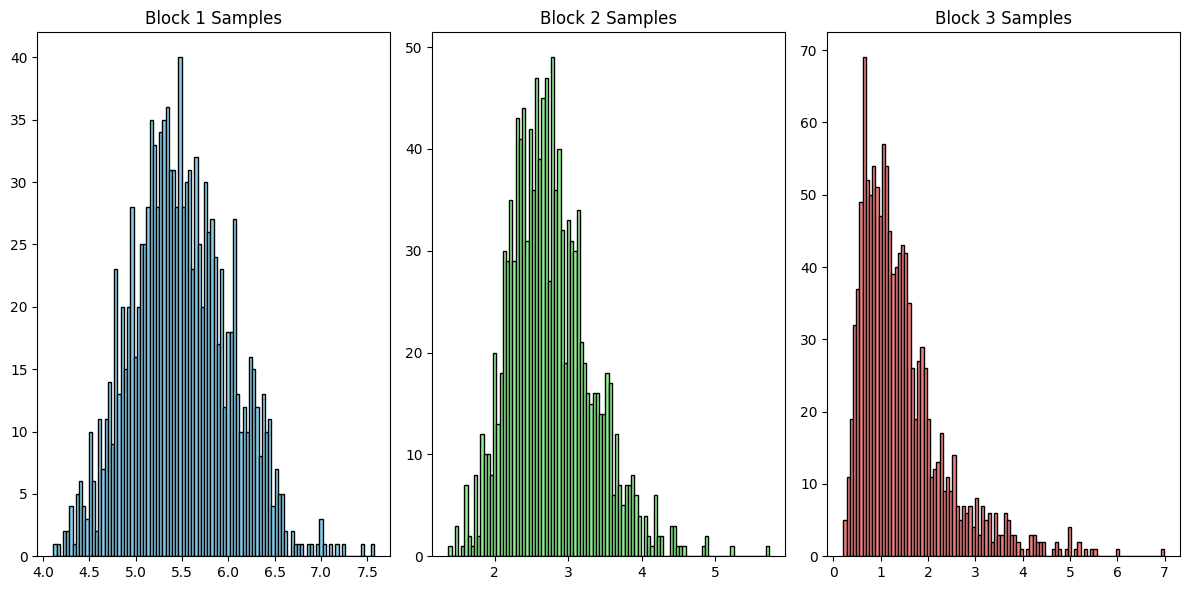


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937499919.4228

--- Iteration 3 ---
Estimated total cost: -709090721.5659

--- Iteration 4 ---
Estimated total cost: 324.1067

--- Iteration 5 ---
Estimated total cost: 330.8220

--- Iteration 6 ---
Estimated total cost: 344.7873

--- Iteration 7 ---
Estimated total cost: 348.0998

--- Iteration 8 ---
Estimated total cost: 348.3722

--- Iteration 9 ---
Estimated total cost: 351.6113

--- Iteration 10 ---
Estimated total cost: 358.1291

--- Iteration 11 ---
Estimated total cost: 363.4835

--- Iteration 12 ---
Estimated total cost: 363.9059

--- Iteration 13 ---
Estimated total cost: 365.6729

--- Iteration 14 ---
Estimated total cost: 365.6864

--- Iteration 15 ---
Estimated total cost: 366.0699

--- Iteration 16 ---
Estimated total cost: 366.1721

--- Iteration 17 ---
Estimated total cost: 366.5380

--- Iteration 18 ---
Estimated total cost: 366.6025

--- Iteration 19 ---
Estimated to

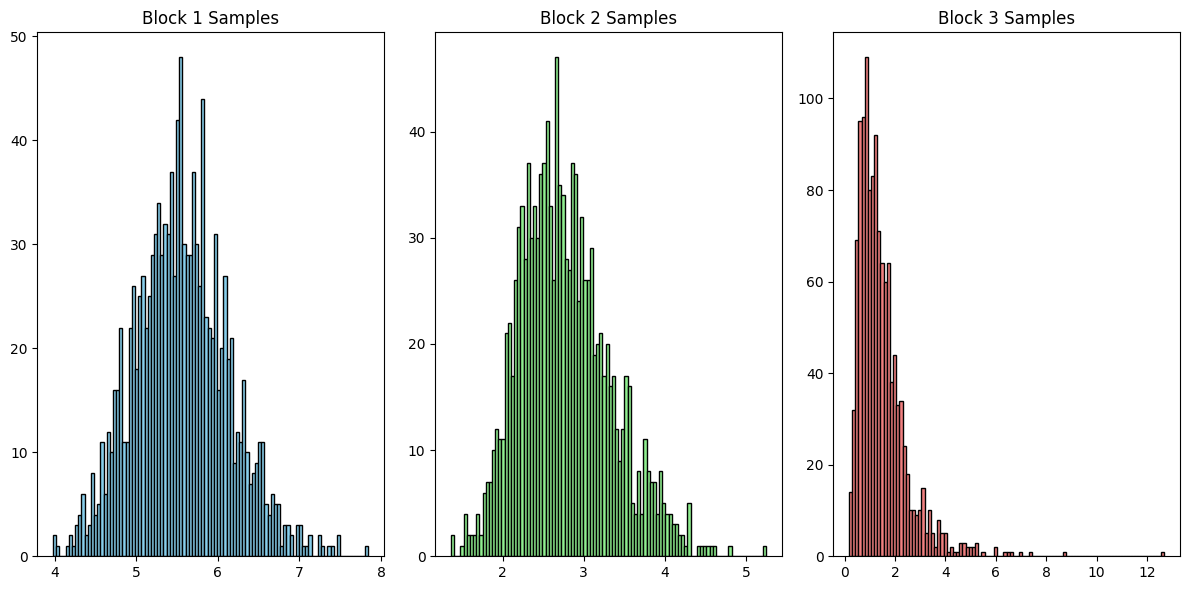


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937528166.5909

--- Iteration 3 ---
Estimated total cost: -709090719.9182

--- Iteration 4 ---
Estimated total cost: 326.6938

--- Iteration 5 ---
Estimated total cost: 333.4834

--- Iteration 6 ---
Estimated total cost: 347.4286

--- Iteration 7 ---
Estimated total cost: 350.9171

--- Iteration 8 ---
Estimated total cost: 351.0504

--- Iteration 9 ---
Estimated total cost: 354.5026

--- Iteration 10 ---
Estimated total cost: 360.8443

--- Iteration 11 ---
Estimated total cost: 366.2754

--- Iteration 12 ---
Estimated total cost: 366.5192

--- Iteration 13 ---
Estimated total cost: 368.1760

--- Iteration 14 ---
Estimated total cost: 368.3878

--- Iteration 15 ---
Estimated total cost: 368.7259

--- Iteration 16 ---
Estimated total cost: 368.7908

--- Iteration 17 ---
Estimated total cost: 369.0210

--- Iteration 18 ---
Estimated total cost: 369.1284

--- Iteration 19 ---
Estimated to

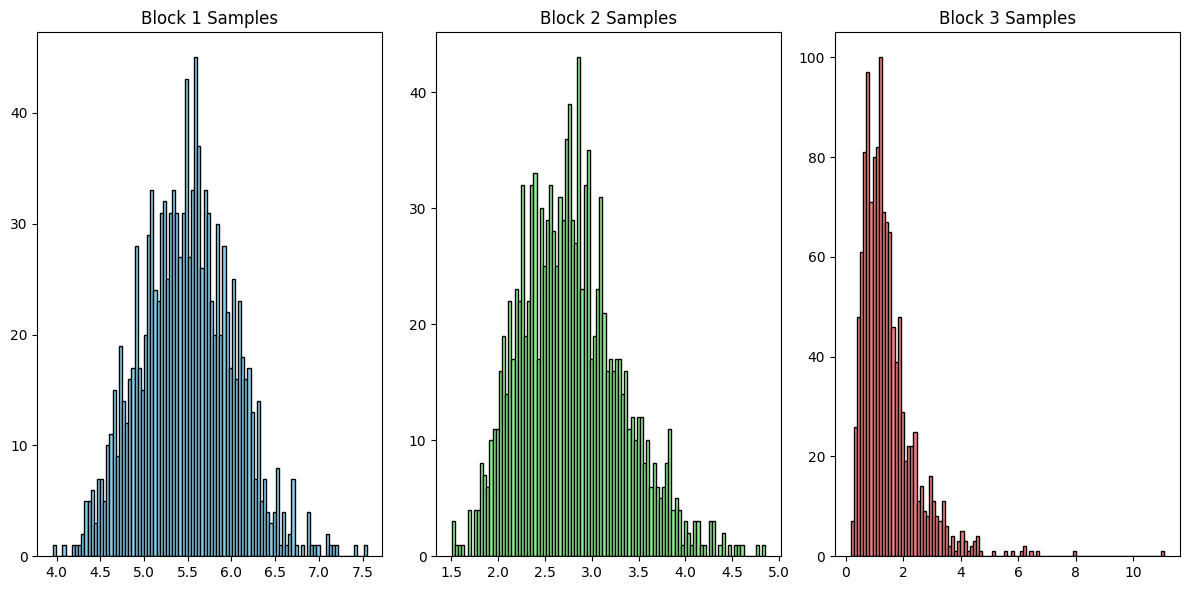


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937537577.4429

--- Iteration 3 ---
Estimated total cost: -709090721.2325

--- Iteration 4 ---
Estimated total cost: 324.6322

--- Iteration 5 ---
Estimated total cost: 331.3126

--- Iteration 6 ---
Estimated total cost: 345.3784

--- Iteration 7 ---
Estimated total cost: 348.6682

--- Iteration 8 ---
Estimated total cost: 348.7496

--- Iteration 9 ---
Estimated total cost: 351.4410

--- Iteration 10 ---
Estimated total cost: 357.9118

--- Iteration 11 ---
Estimated total cost: 363.7607

--- Iteration 12 ---
Estimated total cost: 364.2683

--- Iteration 13 ---
Estimated total cost: 364.7029

--- Iteration 14 ---
Estimated total cost: 365.1935

--- Iteration 15 ---
Estimated total cost: 365.8919

--- Iteration 16 ---
Estimated total cost: 366.6551

--- Iteration 17 ---
Estimated total cost: 366.7518

--- Iteration 18 ---
Estimated total cost: 366.8286

--- Iteration 19 ---
Estimated to

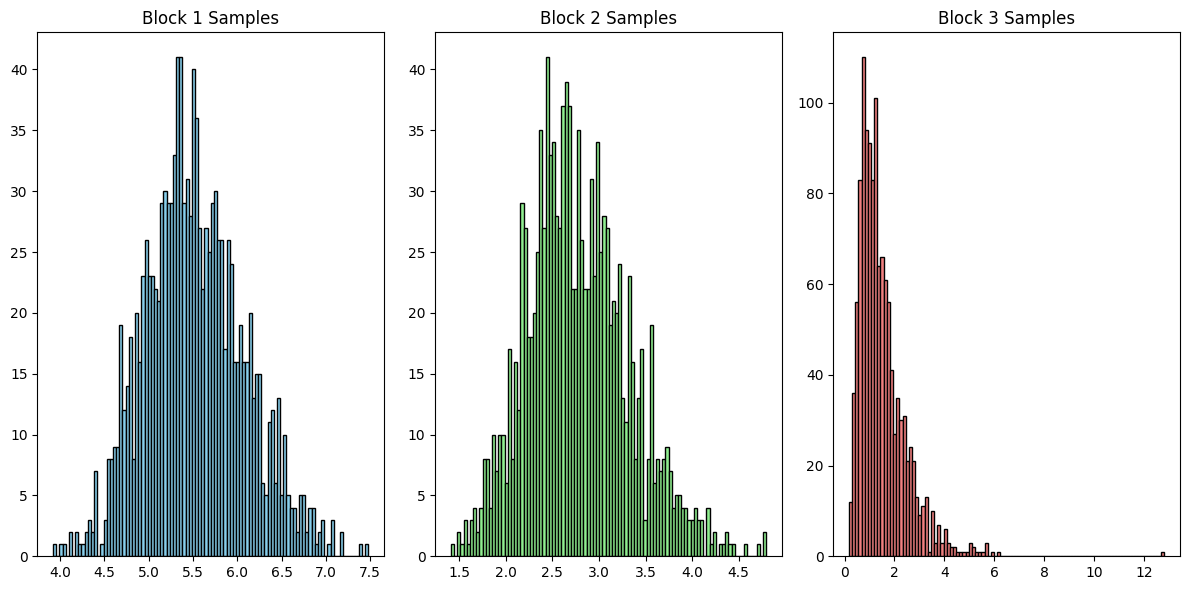


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937528166.7676

--- Iteration 3 ---
Estimated total cost: -709090720.3296

--- Iteration 4 ---
Estimated total cost: 326.0486

--- Iteration 5 ---
Estimated total cost: 332.7933

--- Iteration 6 ---
Estimated total cost: 347.3841

--- Iteration 7 ---
Estimated total cost: 350.2170

--- Iteration 8 ---
Estimated total cost: 350.6001

--- Iteration 9 ---
Estimated total cost: 353.4464

--- Iteration 10 ---
Estimated total cost: 359.9058

--- Iteration 11 ---
Estimated total cost: 365.4851

--- Iteration 12 ---
Estimated total cost: 365.8750

--- Iteration 13 ---
Estimated total cost: 367.9796

--- Iteration 14 ---
Estimated total cost: 368.2652

--- Iteration 15 ---
Estimated total cost: 368.3326

--- Iteration 16 ---
Estimated total cost: 368.3996

--- Iteration 17 ---
Estimated total cost: 368.6169

--- Iteration 18 ---
Estimated total cost: 368.7288

--- Iteration 19 ---
Estimated to

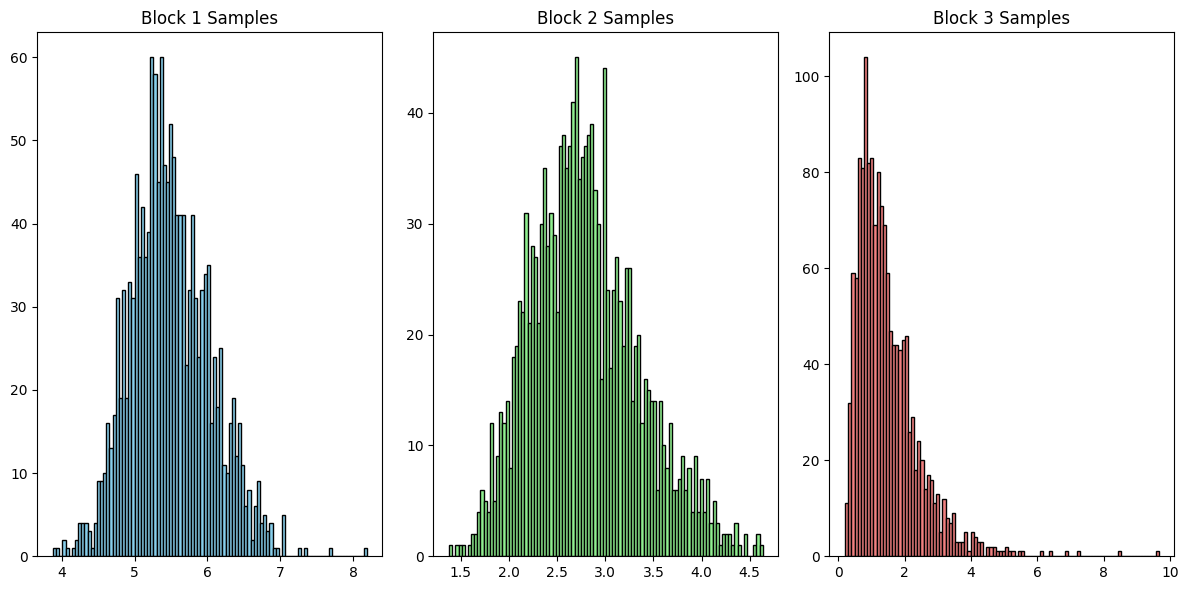


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937539166.3573

--- Iteration 3 ---
Estimated total cost: -709090720.7406

--- Iteration 4 ---
Estimated total cost: 325.4033

--- Iteration 5 ---
Estimated total cost: 332.1880

--- Iteration 6 ---
Estimated total cost: 346.5129

--- Iteration 7 ---
Estimated total cost: 349.6967

--- Iteration 8 ---
Estimated total cost: 349.9648

--- Iteration 9 ---
Estimated total cost: 353.0670

--- Iteration 10 ---
Estimated total cost: 359.7569

--- Iteration 11 ---
Estimated total cost: 365.0642

--- Iteration 12 ---
Estimated total cost: 365.5977

--- Iteration 13 ---
Estimated total cost: 367.2995

--- Iteration 14 ---
Estimated total cost: 367.4030

--- Iteration 15 ---
Estimated total cost: 367.7453

--- Iteration 16 ---
Estimated total cost: 368.2173

--- Iteration 17 ---
Estimated total cost: 368.2385

--- Iteration 18 ---
Estimated total cost: 368.3348

--- Iteration 19 ---
Estimated to

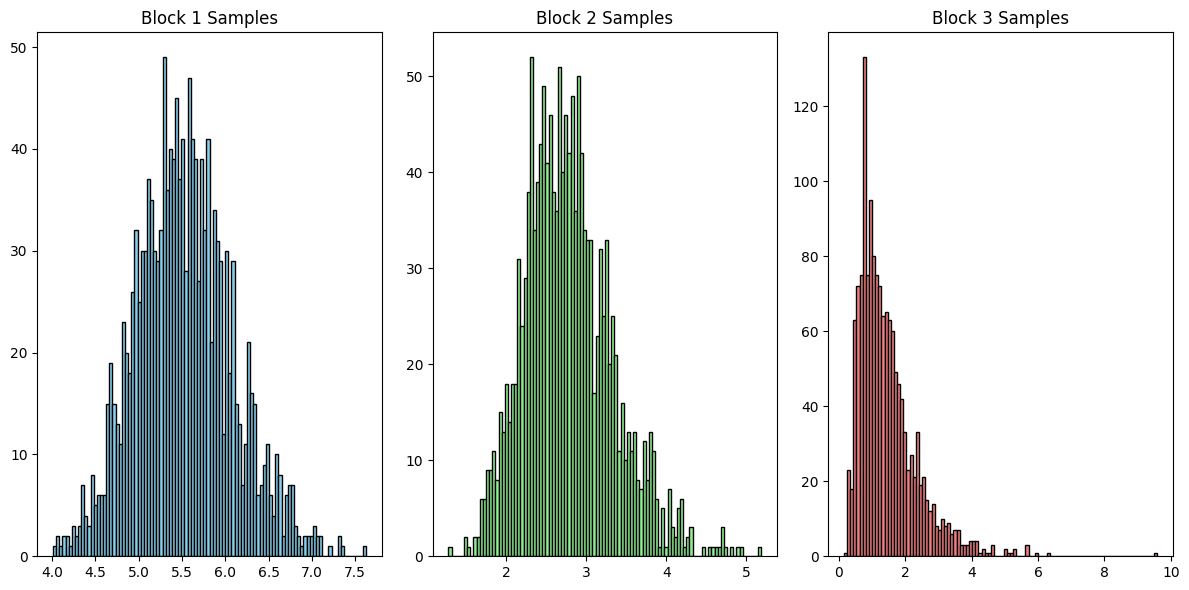


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937507772.3785

--- Iteration 3 ---
Estimated total cost: -709090720.5267

--- Iteration 4 ---
Estimated total cost: 325.7374

--- Iteration 5 ---
Estimated total cost: 332.4304

--- Iteration 6 ---
Estimated total cost: 346.7170

--- Iteration 7 ---
Estimated total cost: 349.7707

--- Iteration 8 ---
Estimated total cost: 349.9389

--- Iteration 9 ---
Estimated total cost: 352.9004

--- Iteration 10 ---
Estimated total cost: 359.1655

--- Iteration 11 ---
Estimated total cost: 364.3321

--- Iteration 12 ---
Estimated total cost: 365.0252

--- Iteration 13 ---
Estimated total cost: 366.9685

--- Iteration 14 ---
Estimated total cost: 367.1495

--- Iteration 15 ---
Estimated total cost: 367.3026

--- Iteration 16 ---
Estimated total cost: 367.5088

--- Iteration 17 ---
Estimated total cost: 367.5907

--- Iteration 18 ---
Estimated total cost: 367.7540

--- Iteration 19 ---
Estimated to

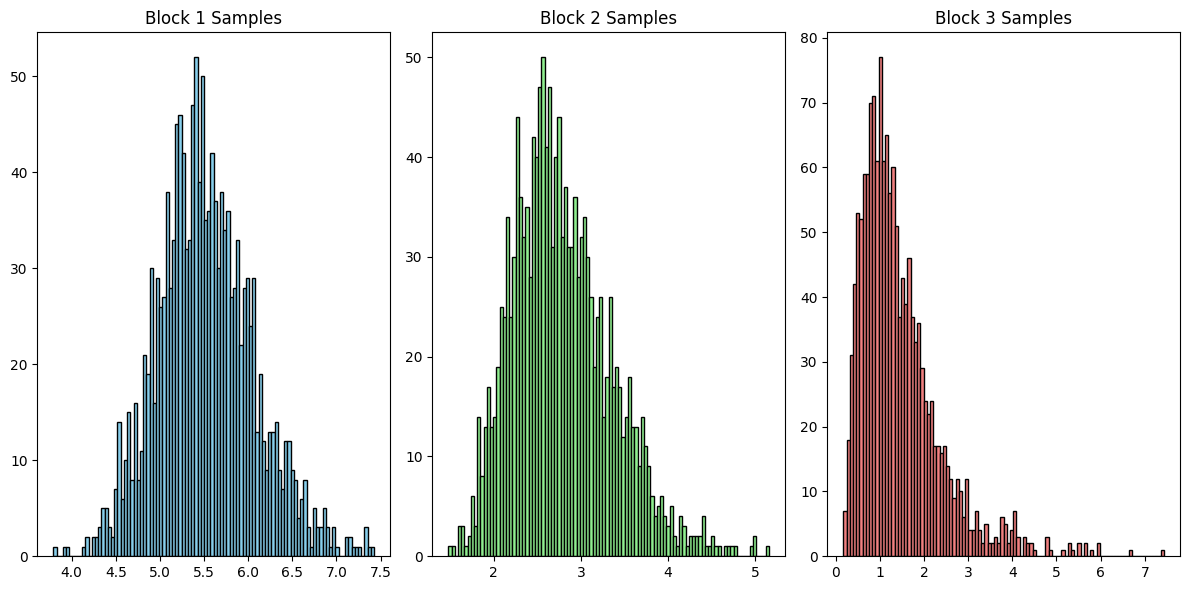


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937507772.3562

--- Iteration 3 ---
Estimated total cost: -709090720.4710

--- Iteration 4 ---
Estimated total cost: 325.8239

--- Iteration 5 ---
Estimated total cost: 332.4459

--- Iteration 6 ---
Estimated total cost: 346.7591

--- Iteration 7 ---
Estimated total cost: 349.6525

--- Iteration 8 ---
Estimated total cost: 349.8864

--- Iteration 9 ---
Estimated total cost: 352.7966

--- Iteration 10 ---
Estimated total cost: 359.1889

--- Iteration 11 ---
Estimated total cost: 364.4676

--- Iteration 12 ---
Estimated total cost: 365.0617

--- Iteration 13 ---
Estimated total cost: 367.0086

--- Iteration 14 ---
Estimated total cost: 367.2568

--- Iteration 15 ---
Estimated total cost: 367.3739

--- Iteration 16 ---
Estimated total cost: 367.5234

--- Iteration 17 ---
Estimated total cost: 367.6885

--- Iteration 18 ---
Estimated total cost: 367.7921

--- Iteration 19 ---
Estimated to

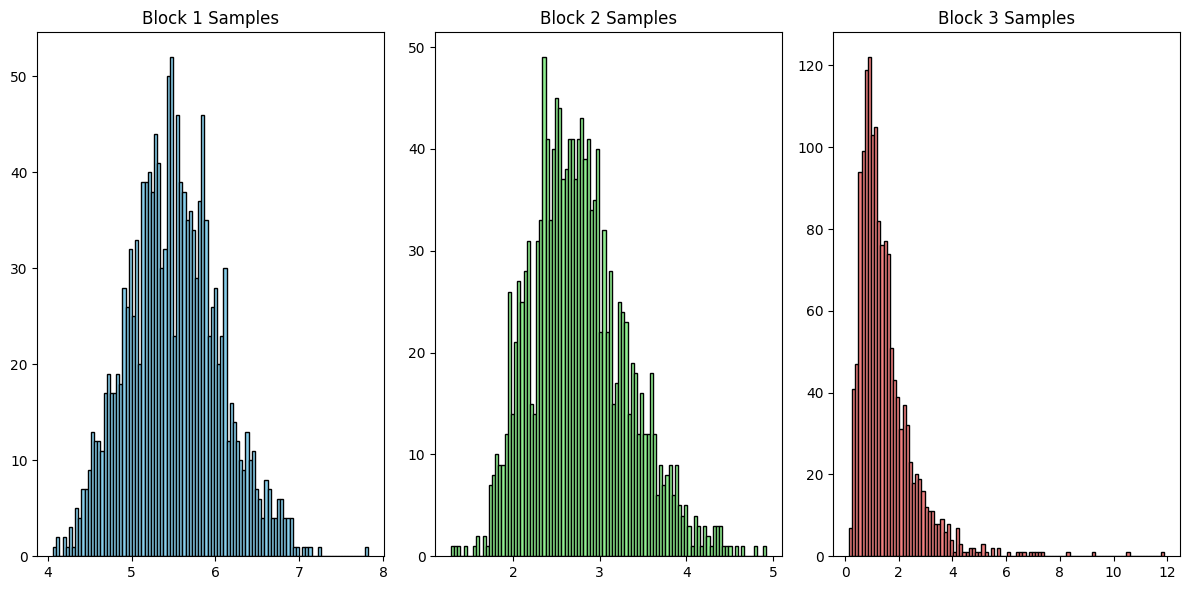


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937562691.1214

--- Iteration 3 ---
Estimated total cost: -709090720.8474

--- Iteration 4 ---
Estimated total cost: 325.2399

--- Iteration 5 ---
Estimated total cost: 331.9603

--- Iteration 6 ---
Estimated total cost: 346.3809

--- Iteration 7 ---
Estimated total cost: 349.7409

--- Iteration 8 ---
Estimated total cost: 349.9106

--- Iteration 9 ---
Estimated total cost: 352.6486

--- Iteration 10 ---
Estimated total cost: 359.3201

--- Iteration 11 ---
Estimated total cost: 365.4528

--- Iteration 12 ---
Estimated total cost: 366.3324

--- Iteration 13 ---
Estimated total cost: 366.7326

--- Iteration 14 ---
Estimated total cost: 367.6717

--- Iteration 15 ---
Estimated total cost: 368.0510

--- Iteration 16 ---
Estimated total cost: 368.7989

--- Iteration 17 ---
Estimated total cost: 368.9038

--- Iteration 18 ---
Estimated total cost: 368.9568

--- Iteration 19 ---
Estimated to

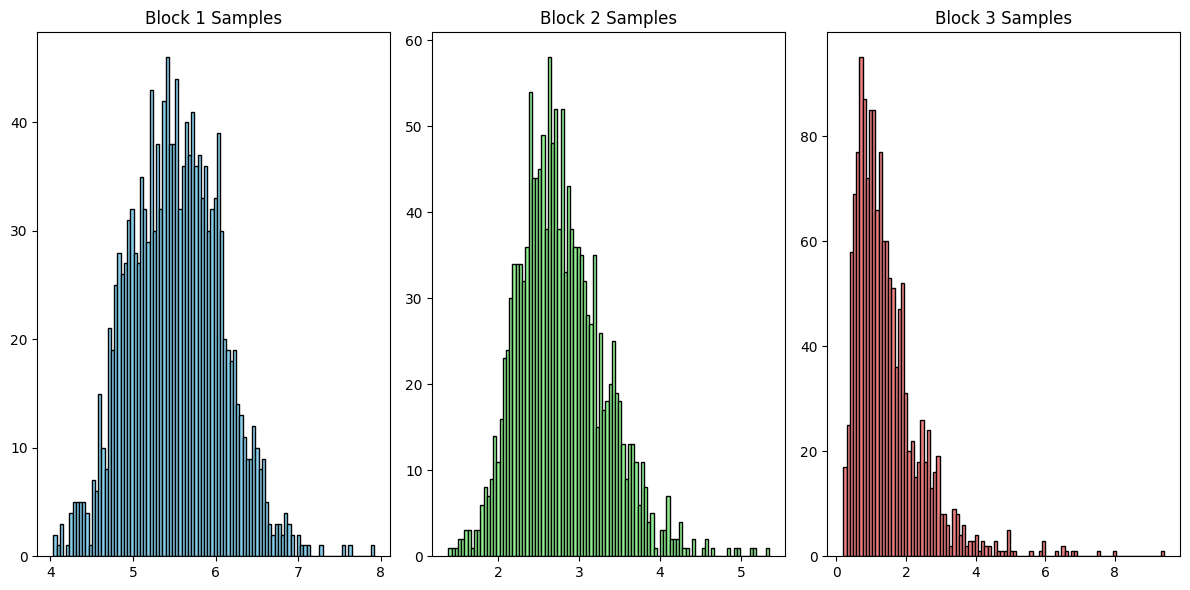


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937531320.7195

--- Iteration 3 ---
Estimated total cost: -709090720.4512

--- Iteration 4 ---
Estimated total cost: 325.8565

--- Iteration 5 ---
Estimated total cost: 332.6473

--- Iteration 6 ---
Estimated total cost: 347.0100

--- Iteration 7 ---
Estimated total cost: 350.2265

--- Iteration 8 ---
Estimated total cost: 350.5119

--- Iteration 9 ---
Estimated total cost: 353.5704

--- Iteration 10 ---
Estimated total cost: 360.1822

--- Iteration 11 ---
Estimated total cost: 366.1304

--- Iteration 12 ---
Estimated total cost: 366.3527

--- Iteration 13 ---
Estimated total cost: 367.9434

--- Iteration 14 ---
Estimated total cost: 368.1310

--- Iteration 15 ---
Estimated total cost: 368.5990

--- Iteration 16 ---
Estimated total cost: 368.6422

--- Iteration 17 ---
Estimated total cost: 369.1321

--- Iteration 18 ---
Estimated total cost: 369.1351

--- Iteration 19 ---
Estimated to

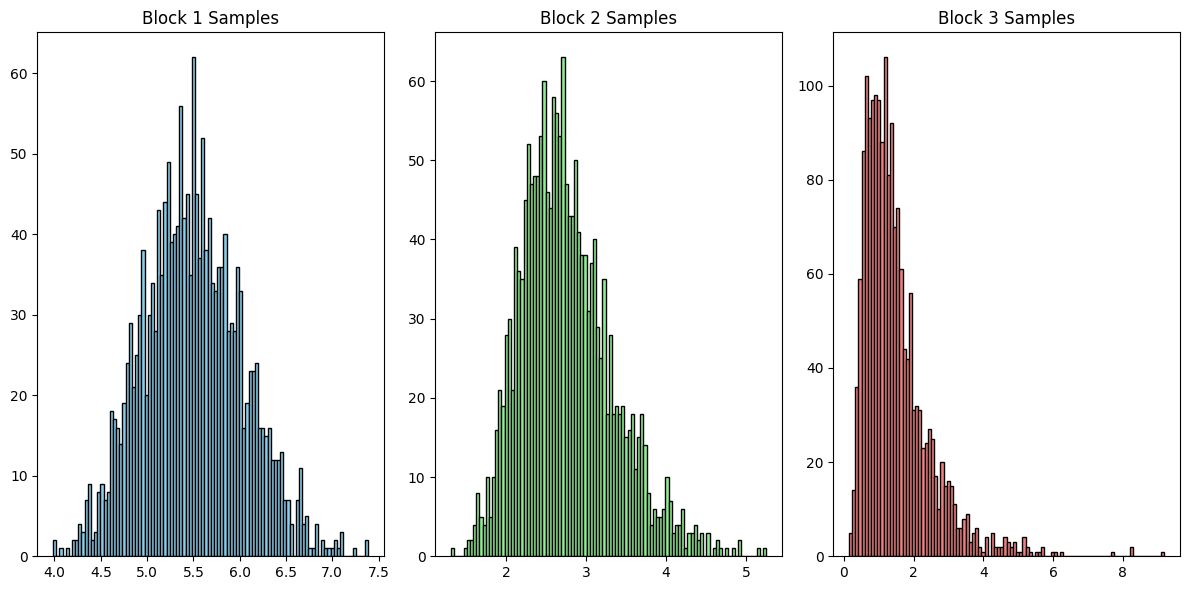


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937539153.4851

--- Iteration 3 ---
Estimated total cost: -709090721.3639

--- Iteration 4 ---
Estimated total cost: 324.4258

--- Iteration 5 ---
Estimated total cost: 331.2885

--- Iteration 6 ---
Estimated total cost: 345.2339

--- Iteration 7 ---
Estimated total cost: 348.6204

--- Iteration 8 ---
Estimated total cost: 349.1744

--- Iteration 9 ---
Estimated total cost: 352.4235

--- Iteration 10 ---
Estimated total cost: 358.8668

--- Iteration 11 ---
Estimated total cost: 364.6772

--- Iteration 12 ---
Estimated total cost: 365.0105

--- Iteration 13 ---
Estimated total cost: 366.9642

--- Iteration 14 ---
Estimated total cost: 366.9926

--- Iteration 15 ---
Estimated total cost: 367.3847

--- Iteration 16 ---
Estimated total cost: 367.4022

--- Iteration 17 ---
Estimated total cost: 367.7604

--- Iteration 18 ---
Estimated total cost: 367.7613
Converged.

--- Final Solution ---

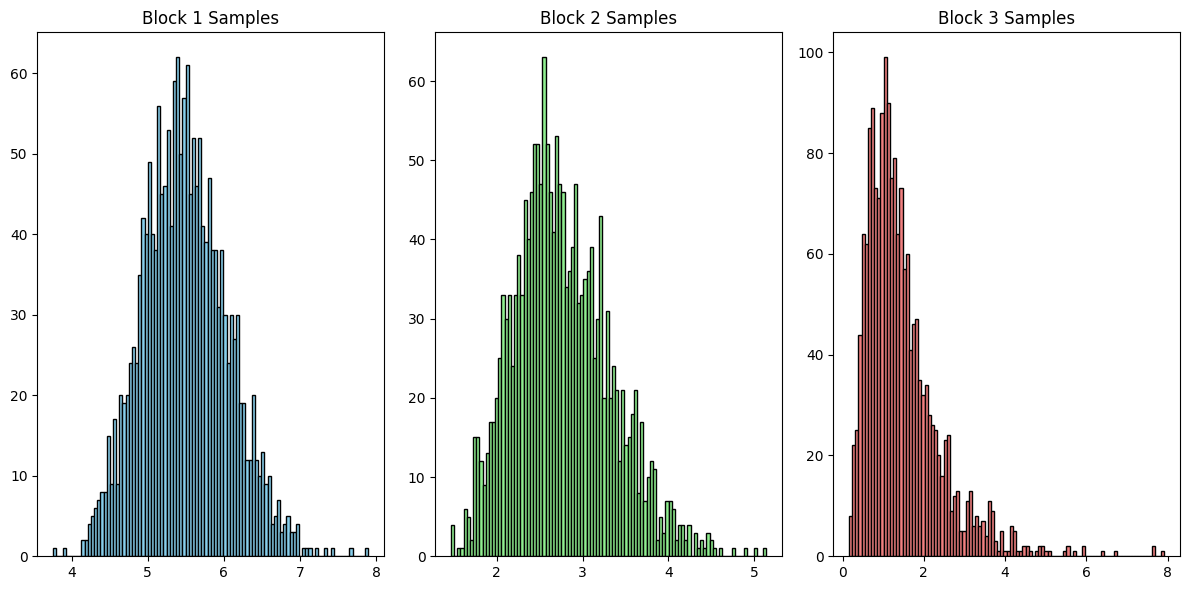


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937545687.7681

--- Iteration 3 ---
Estimated total cost: -709090721.4685

--- Iteration 4 ---
Estimated total cost: 324.2610

--- Iteration 5 ---
Estimated total cost: 331.0555

--- Iteration 6 ---
Estimated total cost: 345.0523

--- Iteration 7 ---
Estimated total cost: 348.3125

--- Iteration 8 ---
Estimated total cost: 348.6789

--- Iteration 9 ---
Estimated total cost: 351.9263

--- Iteration 10 ---
Estimated total cost: 357.9023

--- Iteration 11 ---
Estimated total cost: 363.5509

--- Iteration 12 ---
Estimated total cost: 363.7752

--- Iteration 13 ---
Estimated total cost: 366.1738

--- Iteration 14 ---
Estimated total cost: 366.2224

--- Iteration 15 ---
Estimated total cost: 366.2559

--- Iteration 16 ---
Estimated total cost: 366.2839

--- Iteration 17 ---
Estimated total cost: 366.6006

--- Iteration 18 ---
Estimated total cost: 366.6016

--- Iteration 19 ---
Estimated to

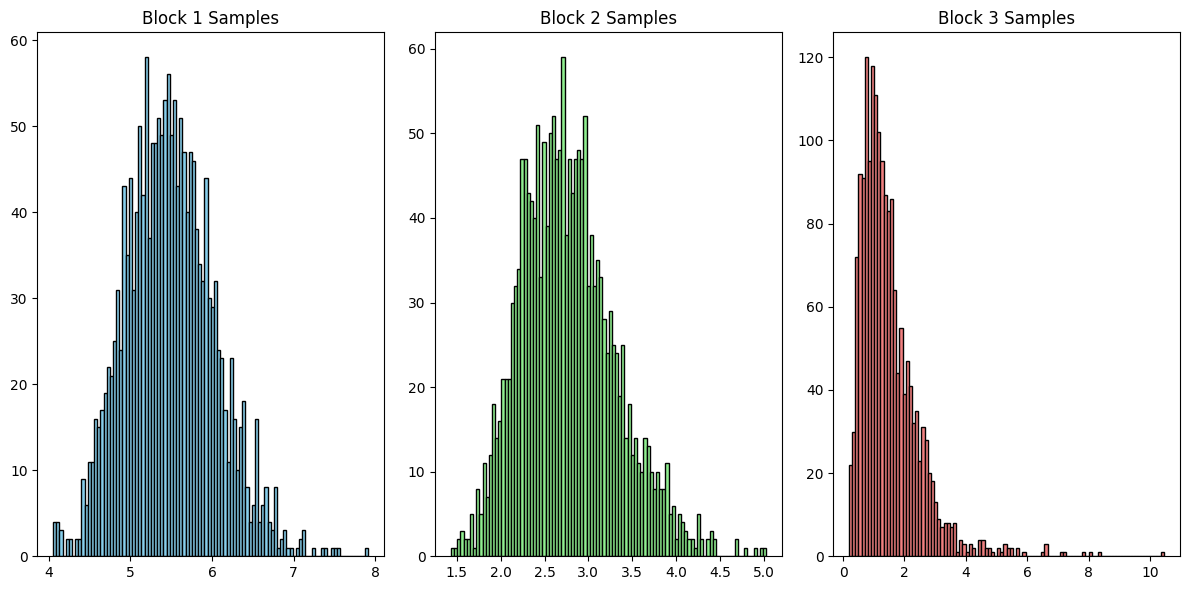


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937539153.4490

--- Iteration 3 ---
Estimated total cost: -709090721.2847

--- Iteration 4 ---
Estimated total cost: 324.5513

--- Iteration 5 ---
Estimated total cost: 331.2332

--- Iteration 6 ---
Estimated total cost: 345.3954

--- Iteration 7 ---
Estimated total cost: 348.6761

--- Iteration 8 ---
Estimated total cost: 348.7859

--- Iteration 9 ---
Estimated total cost: 351.9687

--- Iteration 10 ---
Estimated total cost: 358.6570

--- Iteration 11 ---
Estimated total cost: 364.4284

--- Iteration 12 ---
Estimated total cost: 364.5788

--- Iteration 13 ---
Estimated total cost: 366.0806

--- Iteration 14 ---
Estimated total cost: 366.3503

--- Iteration 15 ---
Estimated total cost: 366.7561

--- Iteration 16 ---
Estimated total cost: 366.8348

--- Iteration 17 ---
Estimated total cost: 367.0431

--- Iteration 18 ---
Estimated total cost: 367.1700

--- Iteration 19 ---
Estimated to

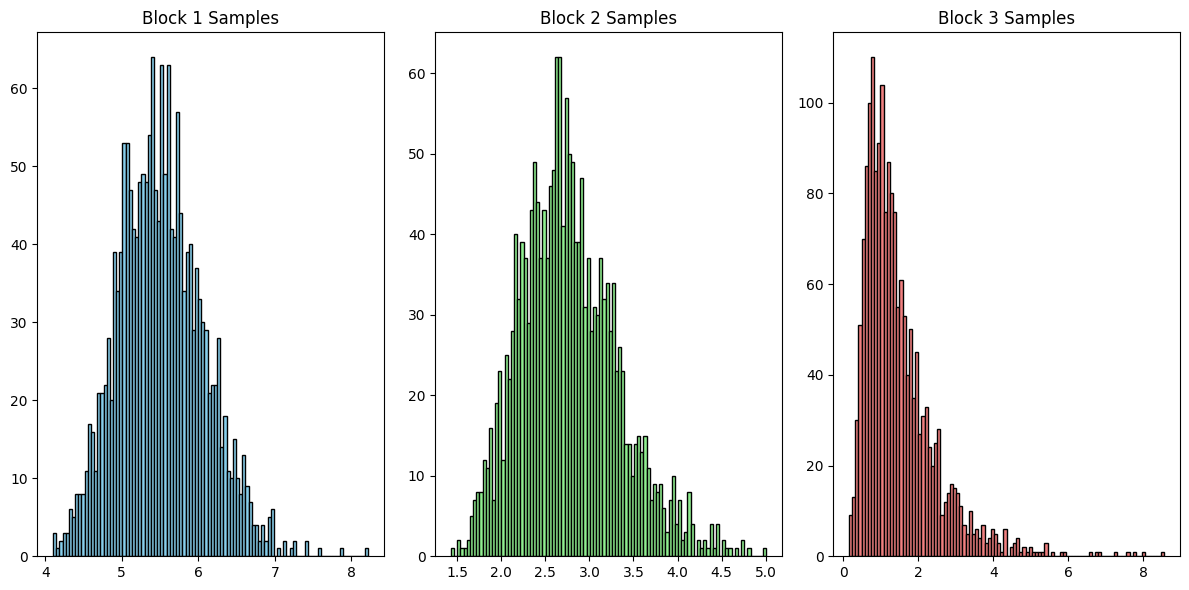


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937532617.5691

--- Iteration 3 ---
Estimated total cost: -709090720.6374

--- Iteration 4 ---
Estimated total cost: 325.5650

--- Iteration 5 ---
Estimated total cost: 332.4500

--- Iteration 6 ---
Estimated total cost: 346.4283

--- Iteration 7 ---
Estimated total cost: 349.8151

--- Iteration 8 ---
Estimated total cost: 350.3699

--- Iteration 9 ---
Estimated total cost: 353.7815

--- Iteration 10 ---
Estimated total cost: 359.6752

--- Iteration 11 ---
Estimated total cost: 365.7752

--- Iteration 12 ---
Estimated total cost: 365.8193

--- Iteration 13 ---
Estimated total cost: 368.3416

--- Iteration 14 ---
Estimated total cost: 368.4204

--- Iteration 15 ---
Estimated total cost: 368.4314

--- Iteration 16 ---
Estimated total cost: 368.4476

--- Iteration 17 ---
Estimated total cost: 368.4933

--- Iteration 18 ---
Estimated total cost: 368.7091

--- Iteration 19 ---
Estimated to

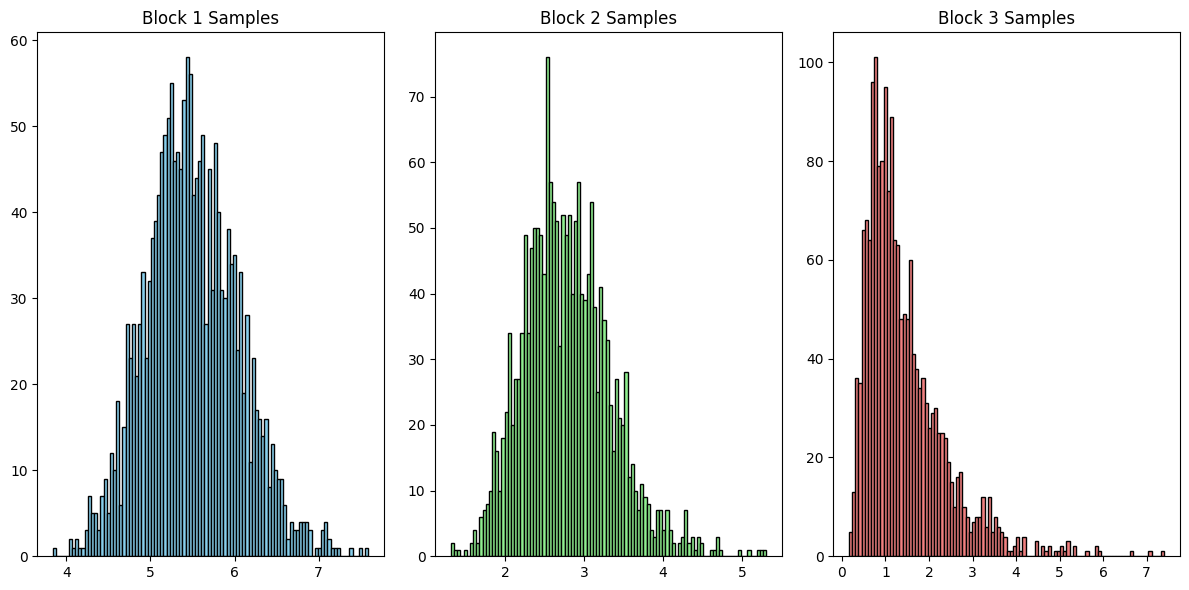


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937513002.8068

--- Iteration 3 ---
Estimated total cost: -709090721.2348

--- Iteration 4 ---
Estimated total cost: 324.6259

--- Iteration 5 ---
Estimated total cost: 331.3221

--- Iteration 6 ---
Estimated total cost: 345.4103

--- Iteration 7 ---
Estimated total cost: 348.6188

--- Iteration 8 ---
Estimated total cost: 348.8740

--- Iteration 9 ---
Estimated total cost: 351.9615

--- Iteration 10 ---
Estimated total cost: 358.4529

--- Iteration 11 ---
Estimated total cost: 363.8730

--- Iteration 12 ---
Estimated total cost: 364.3462

--- Iteration 13 ---
Estimated total cost: 366.2173

--- Iteration 14 ---
Estimated total cost: 366.2273

--- Iteration 15 ---
Estimated total cost: 366.5309

--- Iteration 16 ---
Estimated total cost: 366.8523

--- Iteration 17 ---
Estimated total cost: 366.9193

--- Iteration 18 ---
Estimated total cost: 367.0483

--- Iteration 19 ---
Estimated to

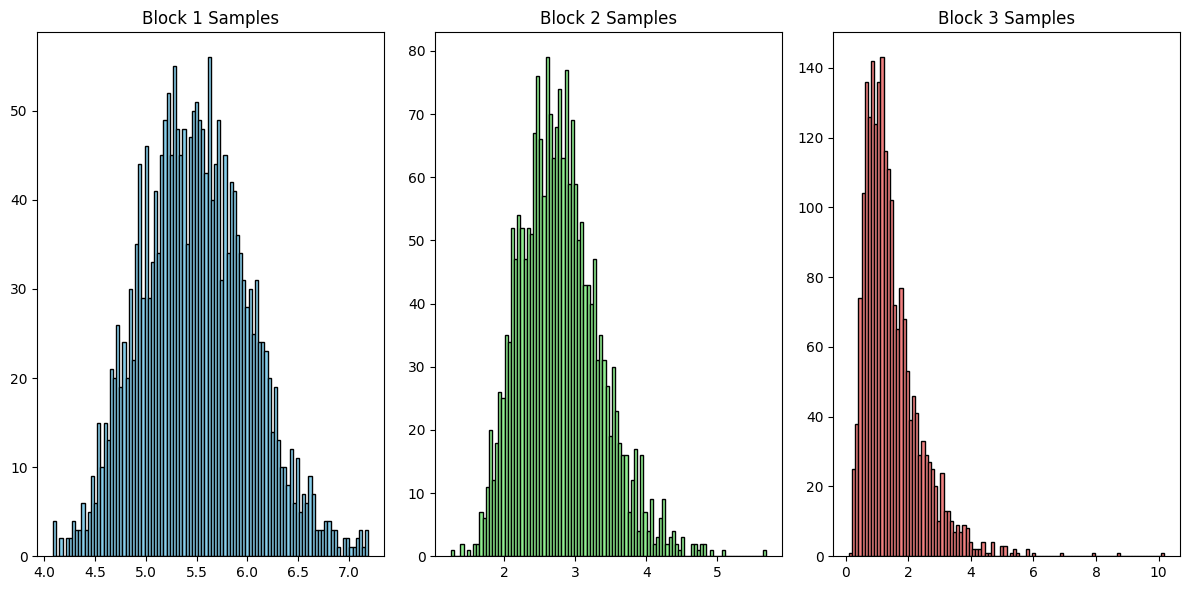


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937527172.8836

--- Iteration 3 ---
Estimated total cost: -709090721.0121

--- Iteration 4 ---
Estimated total cost: 324.9770

--- Iteration 5 ---
Estimated total cost: 331.6373

--- Iteration 6 ---
Estimated total cost: 346.2368

--- Iteration 7 ---
Estimated total cost: 349.0708

--- Iteration 8 ---
Estimated total cost: 349.2545

--- Iteration 9 ---
Estimated total cost: 351.9230

--- Iteration 10 ---
Estimated total cost: 358.8105

--- Iteration 11 ---
Estimated total cost: 364.4364

--- Iteration 12 ---
Estimated total cost: 364.7995

--- Iteration 13 ---
Estimated total cost: 366.3960

--- Iteration 14 ---
Estimated total cost: 366.4330

--- Iteration 15 ---
Estimated total cost: 366.9883

--- Iteration 16 ---
Estimated total cost: 367.0407

--- Iteration 17 ---
Estimated total cost: 367.3864

--- Iteration 18 ---
Estimated total cost: 367.4521

--- Iteration 19 ---
Estimated to

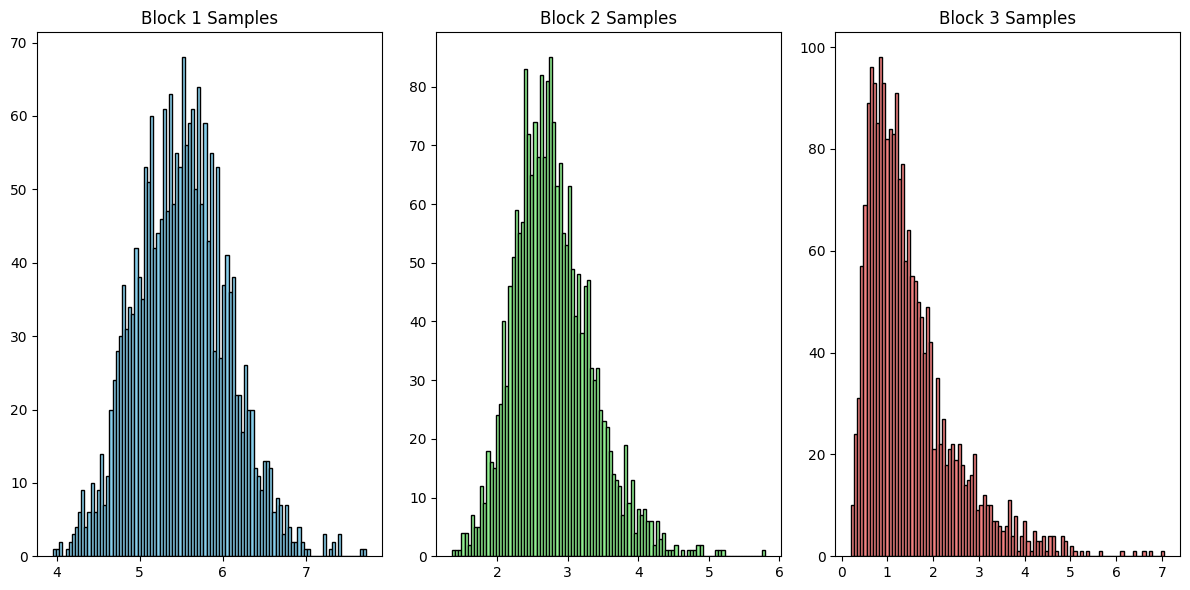


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937516273.9990

--- Iteration 3 ---
Estimated total cost: -709090720.4090

--- Iteration 4 ---
Estimated total cost: 325.9214

--- Iteration 5 ---
Estimated total cost: 332.5921

--- Iteration 6 ---
Estimated total cost: 347.0726

--- Iteration 7 ---
Estimated total cost: 350.1201

--- Iteration 8 ---
Estimated total cost: 350.1527

--- Iteration 9 ---
Estimated total cost: 353.1495

--- Iteration 10 ---
Estimated total cost: 359.7636

--- Iteration 11 ---
Estimated total cost: 364.9105

--- Iteration 12 ---
Estimated total cost: 365.5933

--- Iteration 13 ---
Estimated total cost: 367.3729

--- Iteration 14 ---
Estimated total cost: 367.4695

--- Iteration 15 ---
Estimated total cost: 367.7587

--- Iteration 16 ---
Estimated total cost: 368.1057

--- Iteration 17 ---
Estimated total cost: 368.1971

--- Iteration 18 ---
Estimated total cost: 368.2544

--- Iteration 19 ---
Estimated to

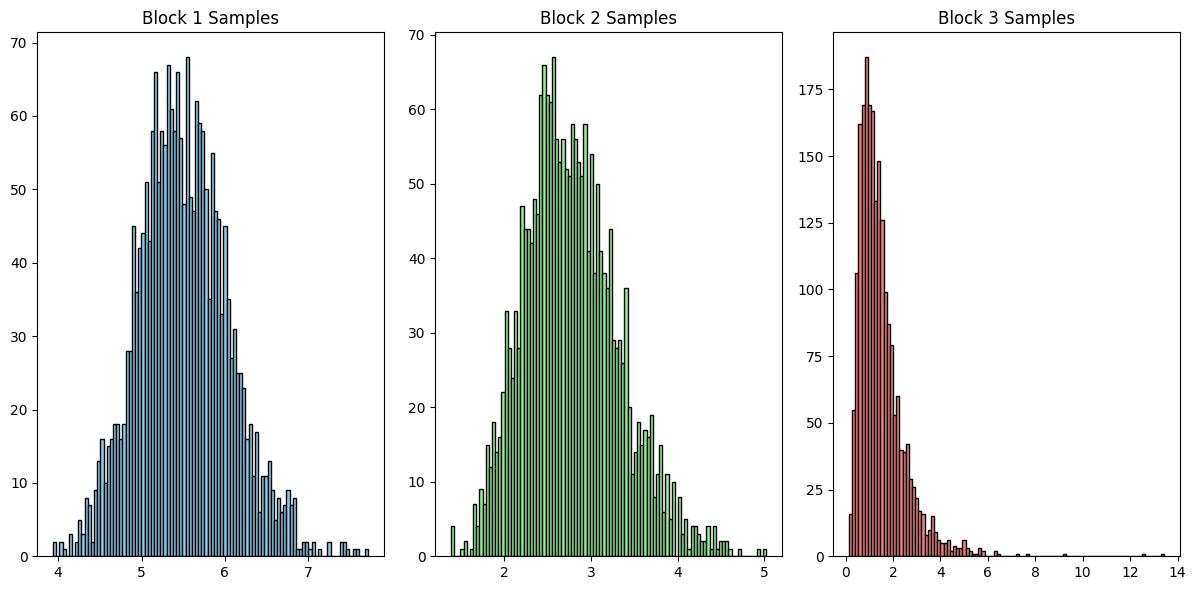


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937554402.6771

--- Iteration 3 ---
Estimated total cost: -709090720.6699

--- Iteration 4 ---
Estimated total cost: 325.5156

--- Iteration 5 ---
Estimated total cost: 332.2110

--- Iteration 6 ---
Estimated total cost: 346.6574

--- Iteration 7 ---
Estimated total cost: 349.7353

--- Iteration 8 ---
Estimated total cost: 349.9084

--- Iteration 9 ---
Estimated total cost: 352.9315

--- Iteration 10 ---
Estimated total cost: 359.4593

--- Iteration 11 ---
Estimated total cost: 365.4429

--- Iteration 12 ---
Estimated total cost: 365.6199

--- Iteration 13 ---
Estimated total cost: 367.4328

--- Iteration 14 ---
Estimated total cost: 367.5746

--- Iteration 15 ---
Estimated total cost: 367.9514

--- Iteration 16 ---
Estimated total cost: 367.9818

--- Iteration 17 ---
Estimated total cost: 368.5399

--- Iteration 18 ---
Estimated total cost: 368.5415

--- Iteration 19 ---
Estimated to

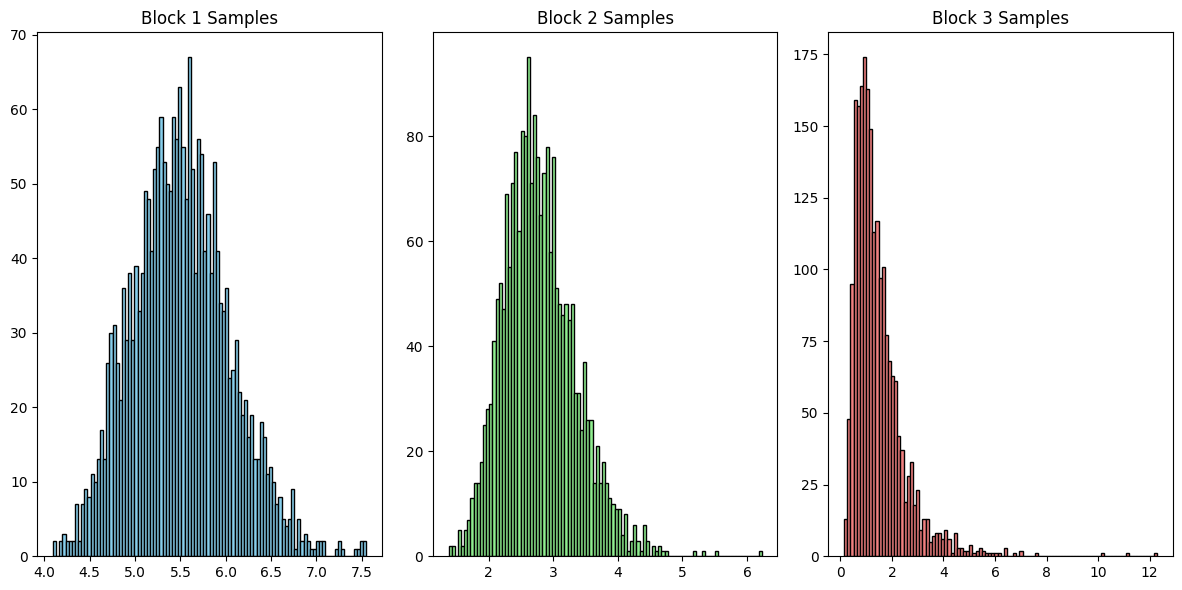


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937565288.0192

--- Iteration 3 ---
Estimated total cost: -709090720.6963

--- Iteration 4 ---
Estimated total cost: 325.4752

--- Iteration 5 ---
Estimated total cost: 332.1945

--- Iteration 6 ---
Estimated total cost: 346.2730

--- Iteration 7 ---
Estimated total cost: 349.6343

--- Iteration 8 ---
Estimated total cost: 349.8360

--- Iteration 9 ---
Estimated total cost: 353.1064

--- Iteration 10 ---
Estimated total cost: 359.9023

--- Iteration 11 ---
Estimated total cost: 365.8238

--- Iteration 12 ---
Estimated total cost: 365.9070

--- Iteration 13 ---
Estimated total cost: 367.5183

--- Iteration 14 ---
Estimated total cost: 367.5862

--- Iteration 15 ---
Estimated total cost: 367.9222

--- Iteration 16 ---
Estimated total cost: 368.0712

--- Iteration 17 ---
Estimated total cost: 368.3291

--- Iteration 18 ---
Estimated total cost: 368.4597

--- Iteration 19 ---
Estimated to

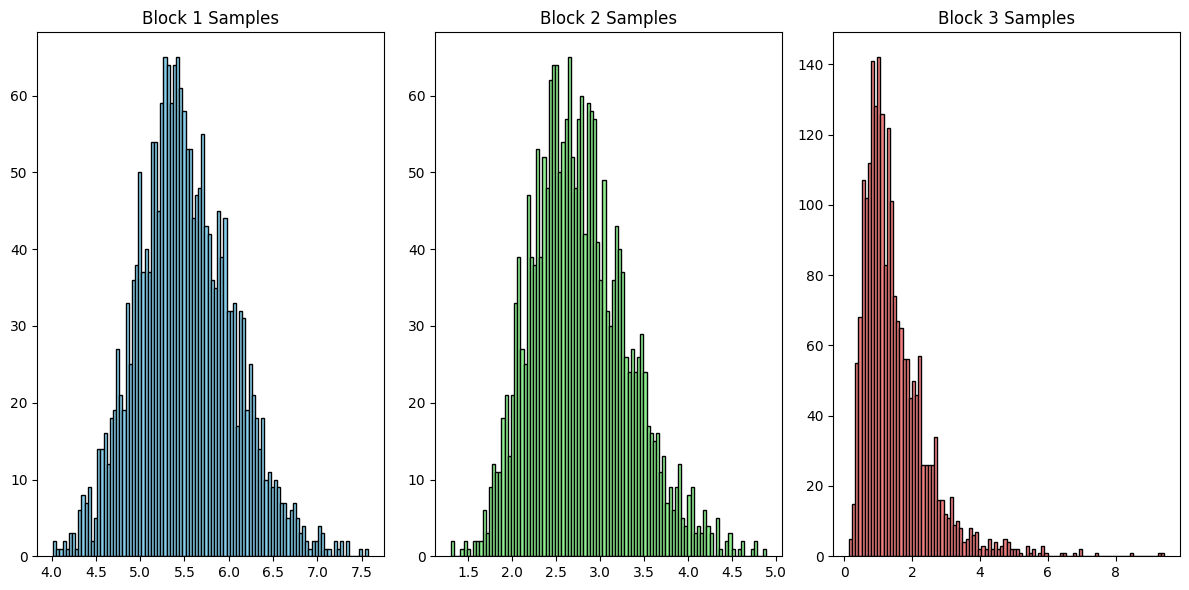


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937554402.6554

--- Iteration 3 ---
Estimated total cost: -709090720.6166

--- Iteration 4 ---
Estimated total cost: 325.5985

--- Iteration 5 ---
Estimated total cost: 332.3975

--- Iteration 6 ---
Estimated total cost: 346.2838

--- Iteration 7 ---
Estimated total cost: 349.7124

--- Iteration 8 ---
Estimated total cost: 350.0789

--- Iteration 9 ---
Estimated total cost: 353.3714

--- Iteration 10 ---
Estimated total cost: 360.0418

--- Iteration 11 ---
Estimated total cost: 365.8374

--- Iteration 12 ---
Estimated total cost: 365.9004

--- Iteration 13 ---
Estimated total cost: 367.5471

--- Iteration 14 ---
Estimated total cost: 367.5794

--- Iteration 15 ---
Estimated total cost: 367.9174

--- Iteration 16 ---
Estimated total cost: 368.0561

--- Iteration 17 ---
Estimated total cost: 368.3205

--- Iteration 18 ---
Estimated total cost: 368.4414

--- Iteration 19 ---
Estimated to

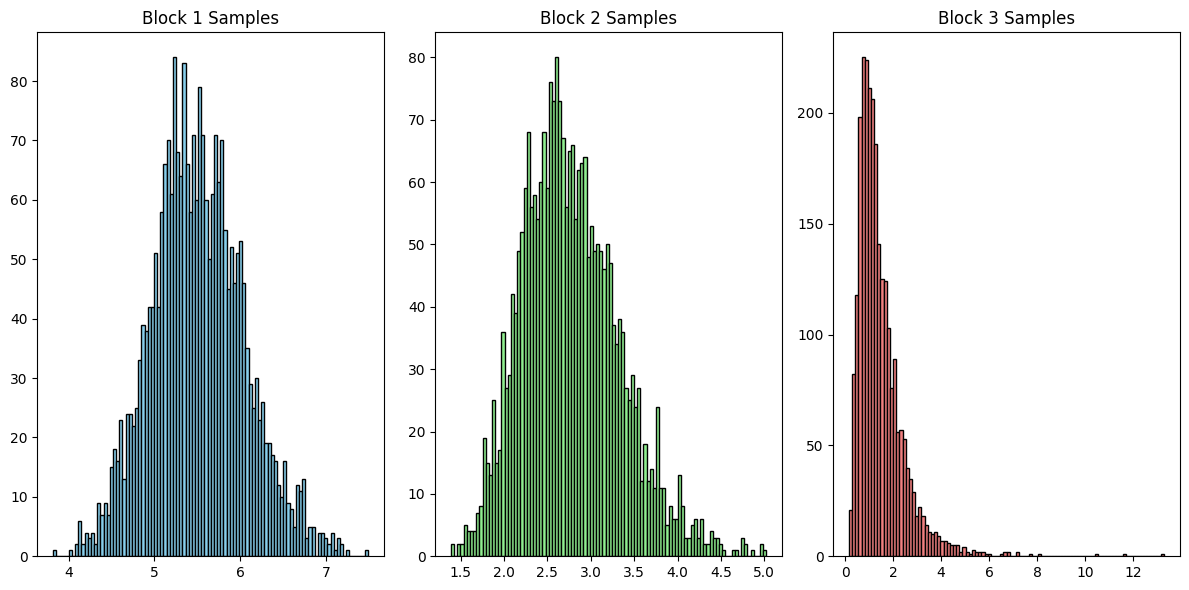


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937536249.2646

--- Iteration 3 ---
Estimated total cost: -709090720.8154

--- Iteration 4 ---
Estimated total cost: 325.2883

--- Iteration 5 ---
Estimated total cost: 331.9344

--- Iteration 6 ---
Estimated total cost: 346.2261

--- Iteration 7 ---
Estimated total cost: 349.4406

--- Iteration 8 ---
Estimated total cost: 349.4805

--- Iteration 9 ---
Estimated total cost: 352.6687

--- Iteration 10 ---
Estimated total cost: 359.1244

--- Iteration 11 ---
Estimated total cost: 364.6352

--- Iteration 12 ---
Estimated total cost: 365.1248

--- Iteration 13 ---
Estimated total cost: 367.1605

--- Iteration 14 ---
Estimated total cost: 367.2646

--- Iteration 15 ---
Estimated total cost: 367.4973

--- Iteration 16 ---
Estimated total cost: 367.5358

--- Iteration 17 ---
Estimated total cost: 367.9055

--- Iteration 18 ---
Estimated total cost: 367.9236

--- Iteration 19 ---
Estimated to

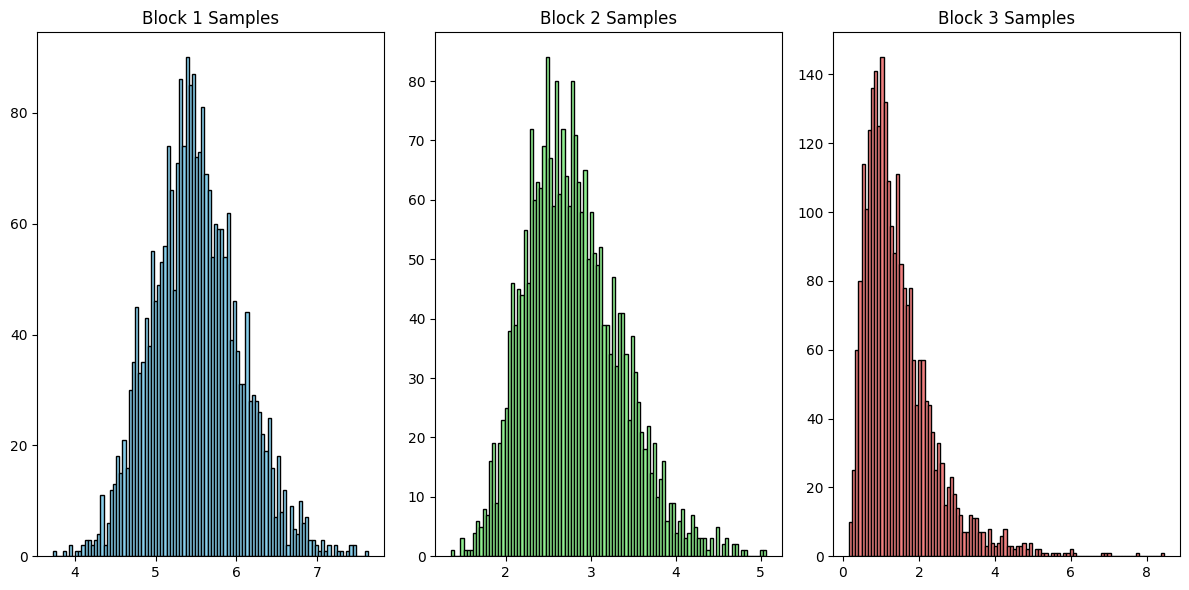


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937527170.6240

--- Iteration 3 ---
Estimated total cost: -709090720.6645

--- Iteration 4 ---
Estimated total cost: 325.5208

--- Iteration 5 ---
Estimated total cost: 332.1748

--- Iteration 6 ---
Estimated total cost: 346.7884

--- Iteration 7 ---
Estimated total cost: 349.8013

--- Iteration 8 ---
Estimated total cost: 349.8939

--- Iteration 9 ---
Estimated total cost: 352.3310

--- Iteration 10 ---
Estimated total cost: 359.1867

--- Iteration 11 ---
Estimated total cost: 365.2727

--- Iteration 12 ---
Estimated total cost: 365.8786

--- Iteration 13 ---
Estimated total cost: 366.1129

--- Iteration 14 ---
Estimated total cost: 366.6724

--- Iteration 15 ---
Estimated total cost: 367.4743

--- Iteration 16 ---
Estimated total cost: 368.2095

--- Iteration 17 ---
Estimated total cost: 368.3361

--- Iteration 18 ---
Estimated total cost: 368.3865

--- Iteration 19 ---
Estimated to

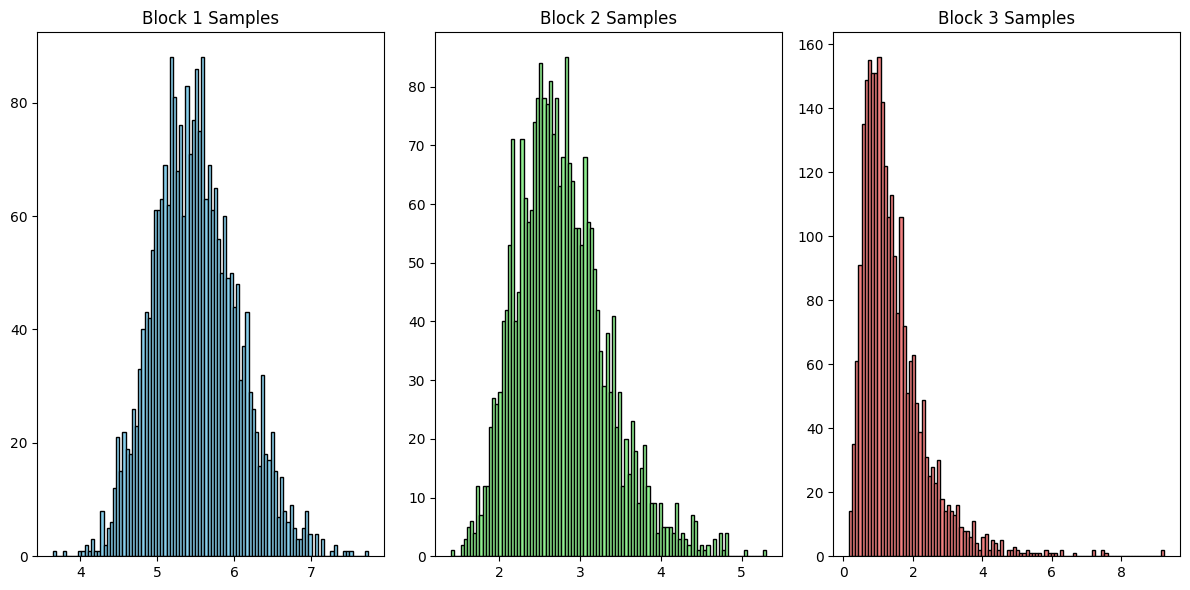


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937549862.2820

--- Iteration 3 ---
Estimated total cost: -709090721.0136

--- Iteration 4 ---
Estimated total cost: 324.9749

--- Iteration 5 ---
Estimated total cost: 331.6327

--- Iteration 6 ---
Estimated total cost: 345.9865

--- Iteration 7 ---
Estimated total cost: 349.0430

--- Iteration 8 ---
Estimated total cost: 349.1745

--- Iteration 9 ---
Estimated total cost: 352.1091

--- Iteration 10 ---
Estimated total cost: 358.8969

--- Iteration 11 ---
Estimated total cost: 364.5976

--- Iteration 12 ---
Estimated total cost: 364.8035

--- Iteration 13 ---
Estimated total cost: 366.2433

--- Iteration 14 ---
Estimated total cost: 366.4876

--- Iteration 15 ---
Estimated total cost: 366.9449

--- Iteration 16 ---
Estimated total cost: 367.0210

--- Iteration 17 ---
Estimated total cost: 367.4307

--- Iteration 18 ---
Estimated total cost: 367.4500

--- Iteration 19 ---
Estimated to

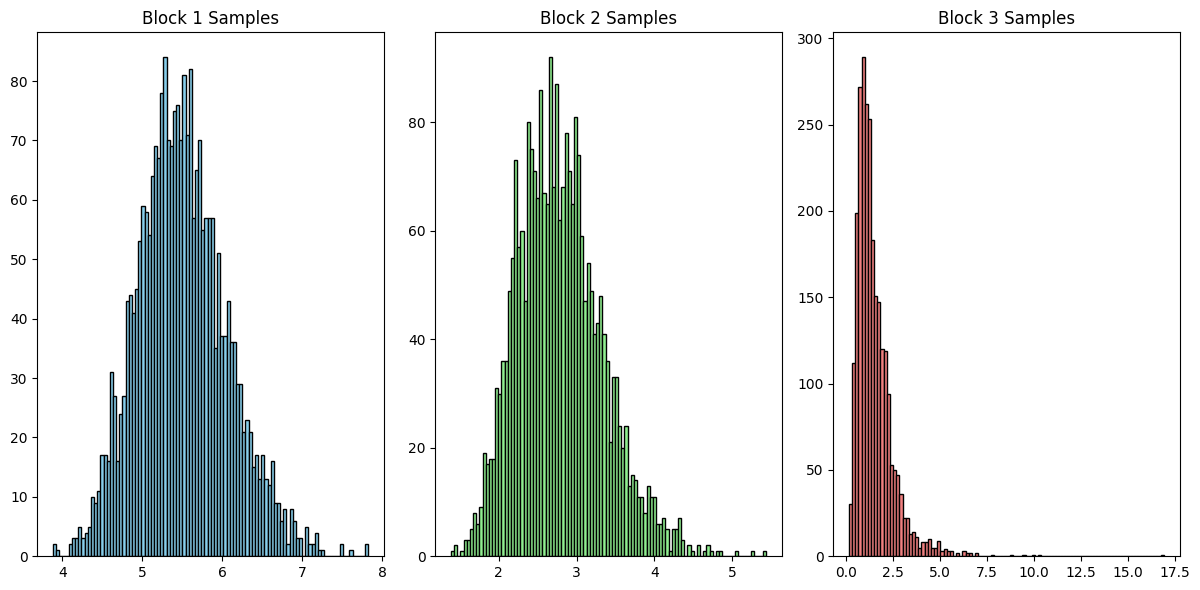


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937540787.4591

--- Iteration 3 ---
Estimated total cost: -709090720.5678

--- Iteration 4 ---
Estimated total cost: 325.6774

--- Iteration 5 ---
Estimated total cost: 332.3611

--- Iteration 6 ---
Estimated total cost: 347.0044

--- Iteration 7 ---
Estimated total cost: 349.9996

--- Iteration 8 ---
Estimated total cost: 350.0794

--- Iteration 9 ---
Estimated total cost: 353.0538

--- Iteration 10 ---
Estimated total cost: 359.7209

--- Iteration 11 ---
Estimated total cost: 365.3846

--- Iteration 12 ---
Estimated total cost: 365.7659

--- Iteration 13 ---
Estimated total cost: 367.6886

--- Iteration 14 ---
Estimated total cost: 367.7698

--- Iteration 15 ---
Estimated total cost: 368.2020

--- Iteration 16 ---
Estimated total cost: 368.2043

--- Iteration 17 ---
Estimated total cost: 368.3576

--- Iteration 18 ---
Estimated total cost: 368.4612

--- Iteration 19 ---
Estimated to

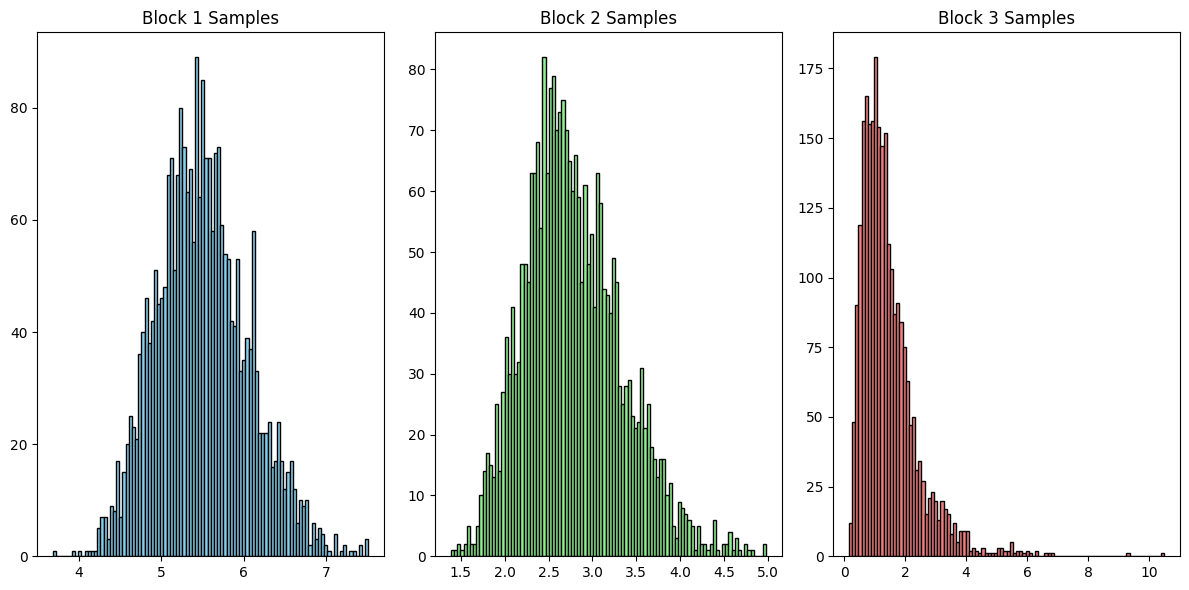


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937527170.7647

--- Iteration 3 ---
Estimated total cost: -709090720.9981

--- Iteration 4 ---
Estimated total cost: 324.9991

--- Iteration 5 ---
Estimated total cost: 331.6543

--- Iteration 6 ---
Estimated total cost: 345.9039

--- Iteration 7 ---
Estimated total cost: 349.0970

--- Iteration 8 ---
Estimated total cost: 349.1206

--- Iteration 9 ---
Estimated total cost: 352.3008

--- Iteration 10 ---
Estimated total cost: 358.9667

--- Iteration 11 ---
Estimated total cost: 364.3598

--- Iteration 12 ---
Estimated total cost: 364.6782

--- Iteration 13 ---
Estimated total cost: 366.2431

--- Iteration 14 ---
Estimated total cost: 366.3608

--- Iteration 15 ---
Estimated total cost: 366.8993

--- Iteration 16 ---
Estimated total cost: 366.9179

--- Iteration 17 ---
Estimated total cost: 367.1751

--- Iteration 18 ---
Estimated total cost: 367.2634

--- Iteration 19 ---
Estimated to

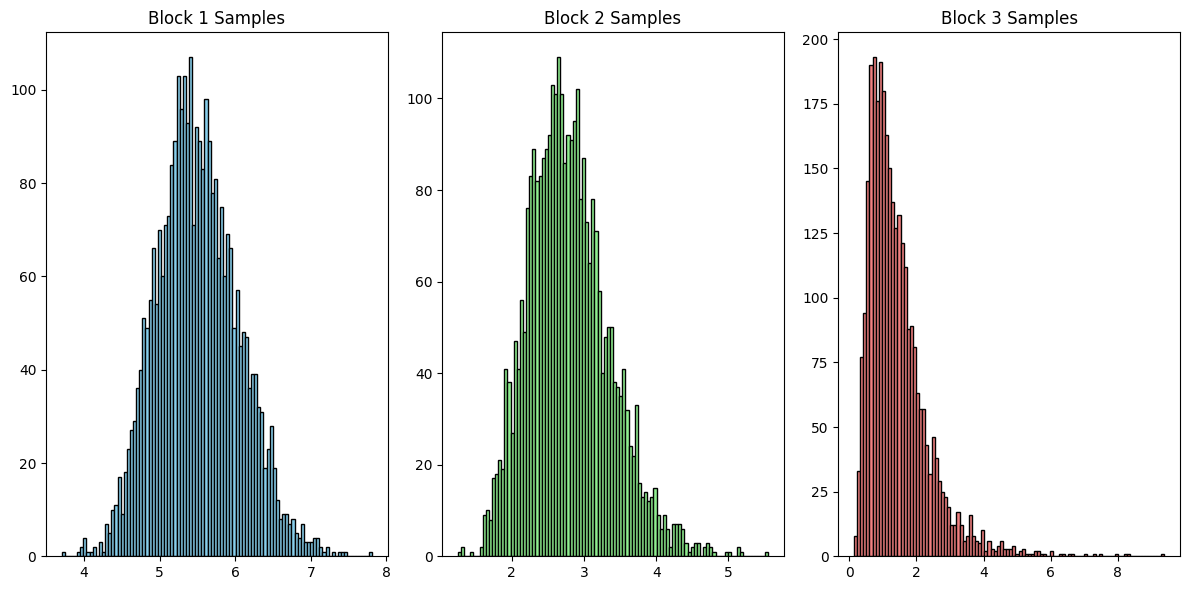


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937537759.6220

--- Iteration 3 ---
Estimated total cost: -709090720.7114

--- Iteration 4 ---
Estimated total cost: 325.4482

--- Iteration 5 ---
Estimated total cost: 332.0949

--- Iteration 6 ---
Estimated total cost: 346.2285

--- Iteration 7 ---
Estimated total cost: 349.4450

--- Iteration 8 ---
Estimated total cost: 349.4850

--- Iteration 9 ---
Estimated total cost: 352.5954

--- Iteration 10 ---
Estimated total cost: 359.2304

--- Iteration 11 ---
Estimated total cost: 364.5887

--- Iteration 12 ---
Estimated total cost: 364.9394

--- Iteration 13 ---
Estimated total cost: 366.5420

--- Iteration 14 ---
Estimated total cost: 366.7246

--- Iteration 15 ---
Estimated total cost: 367.1048

--- Iteration 16 ---
Estimated total cost: 367.1588

--- Iteration 17 ---
Estimated total cost: 367.5274

--- Iteration 18 ---
Estimated total cost: 367.5804

--- Iteration 19 ---
Estimated to

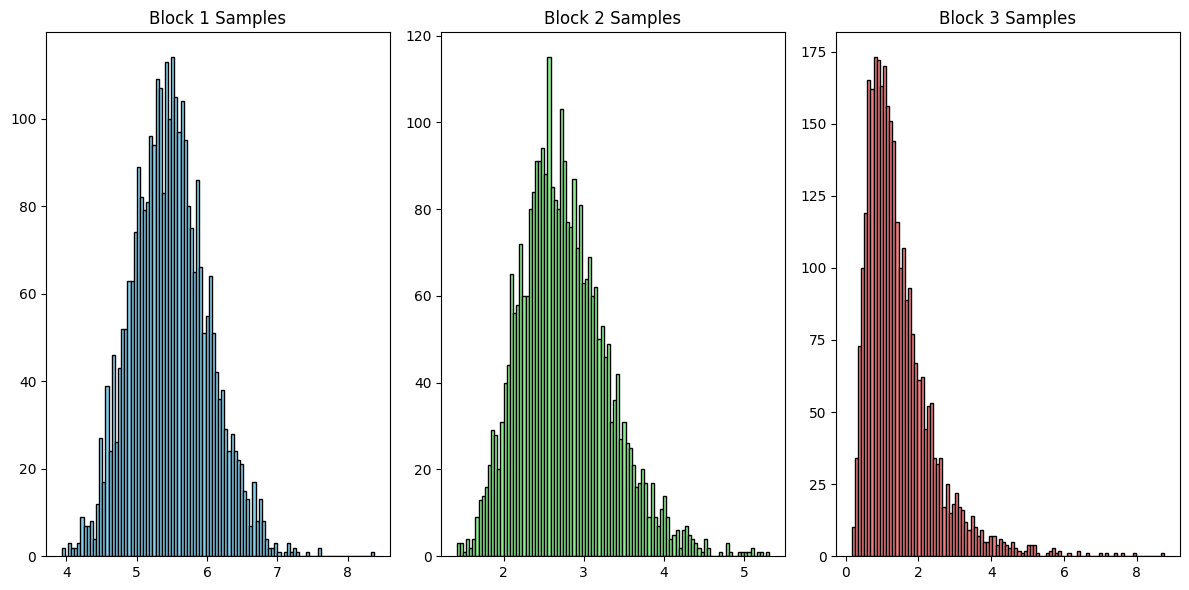


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937533978.0824

--- Iteration 3 ---
Estimated total cost: -709090721.7710

--- Iteration 4 ---
Estimated total cost: 323.7862

--- Iteration 5 ---
Estimated total cost: 330.5169

--- Iteration 6 ---
Estimated total cost: 344.4724

--- Iteration 7 ---
Estimated total cost: 347.7261

--- Iteration 8 ---
Estimated total cost: 348.0737

--- Iteration 9 ---
Estimated total cost: 351.2584

--- Iteration 10 ---
Estimated total cost: 357.5617

--- Iteration 11 ---
Estimated total cost: 363.4875

--- Iteration 12 ---
Estimated total cost: 363.5037

--- Iteration 13 ---
Estimated total cost: 365.4767

--- Iteration 14 ---
Estimated total cost: 365.4873

--- Iteration 15 ---
Estimated total cost: 365.7652

--- Iteration 16 ---
Estimated total cost: 365.8400

--- Iteration 17 ---
Estimated total cost: 366.1407

--- Iteration 18 ---
Estimated total cost: 366.2198

--- Iteration 19 ---
Estimated to

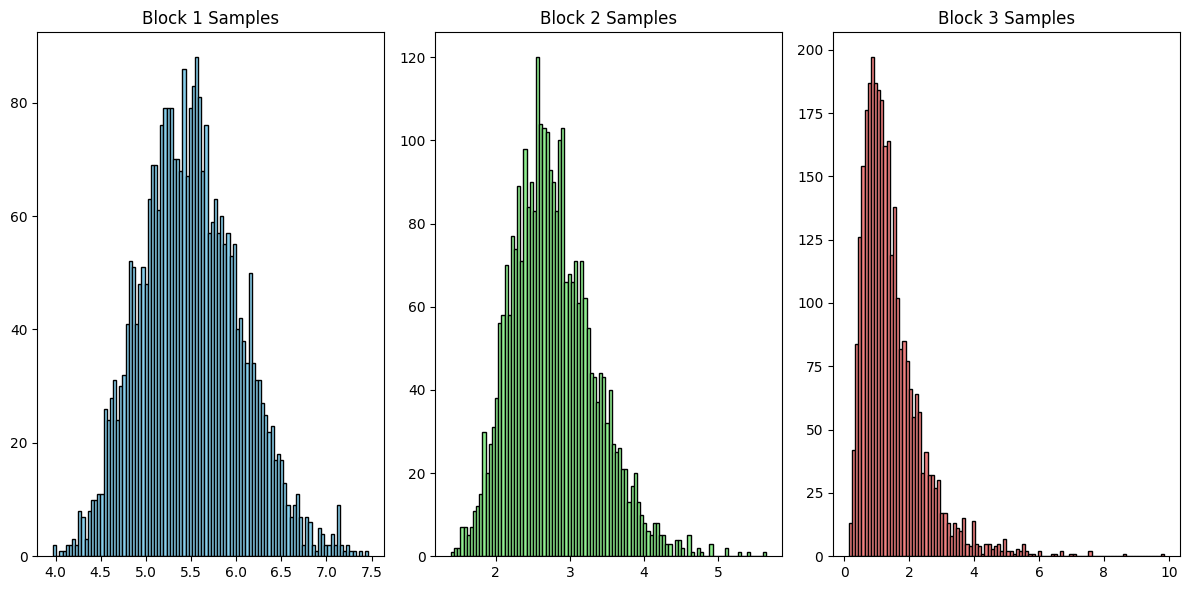


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937537759.7712

--- Iteration 3 ---
Estimated total cost: -709090721.0604

--- Iteration 4 ---
Estimated total cost: 324.9012

--- Iteration 5 ---
Estimated total cost: 331.6223

--- Iteration 6 ---
Estimated total cost: 345.7762

--- Iteration 7 ---
Estimated total cost: 348.9266

--- Iteration 8 ---
Estimated total cost: 349.2784

--- Iteration 9 ---
Estimated total cost: 352.3972

--- Iteration 10 ---
Estimated total cost: 358.7930

--- Iteration 11 ---
Estimated total cost: 364.6065

--- Iteration 12 ---
Estimated total cost: 364.8286

--- Iteration 13 ---
Estimated total cost: 366.9501

--- Iteration 14 ---
Estimated total cost: 367.0337

--- Iteration 15 ---
Estimated total cost: 367.2953

--- Iteration 16 ---
Estimated total cost: 367.3213

--- Iteration 17 ---
Estimated total cost: 367.8341

--- Iteration 18 ---
Estimated total cost: 367.8348
Converged.

--- Final Solution ---

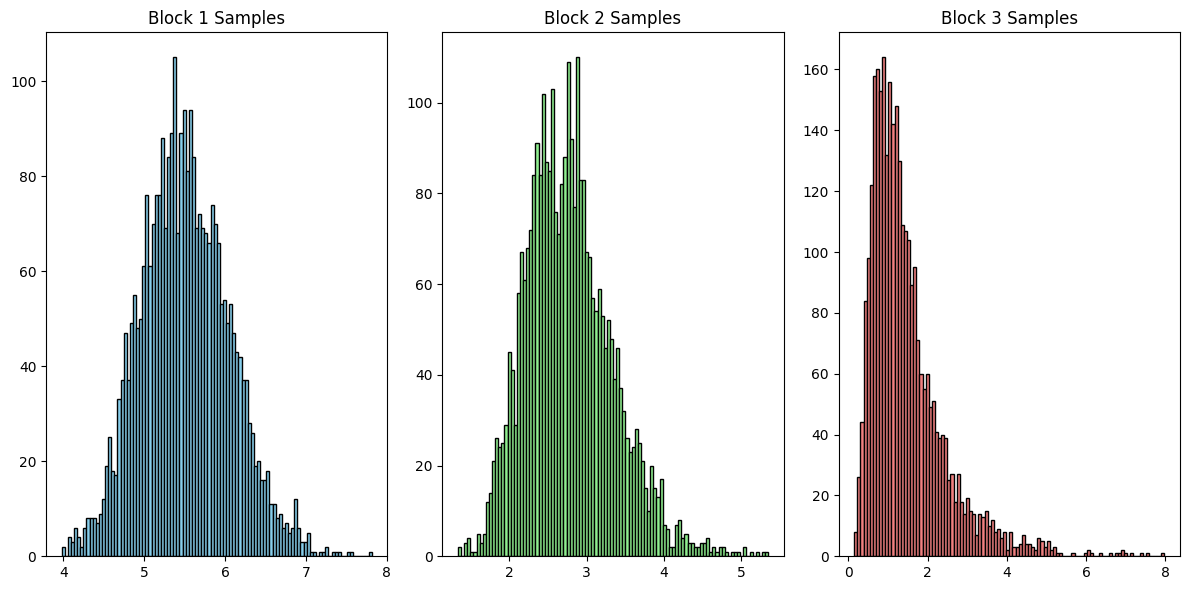


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937533977.6326

--- Iteration 3 ---
Estimated total cost: -709090720.7245

--- Iteration 4 ---
Estimated total cost: 325.4278

--- Iteration 5 ---
Estimated total cost: 332.1650

--- Iteration 6 ---
Estimated total cost: 346.3807

--- Iteration 7 ---
Estimated total cost: 349.5653

--- Iteration 8 ---
Estimated total cost: 349.8171

--- Iteration 9 ---
Estimated total cost: 352.8982

--- Iteration 10 ---
Estimated total cost: 359.3120

--- Iteration 11 ---
Estimated total cost: 365.1105

--- Iteration 12 ---
Estimated total cost: 365.3327

--- Iteration 13 ---
Estimated total cost: 367.1374

--- Iteration 14 ---
Estimated total cost: 367.2769

--- Iteration 15 ---
Estimated total cost: 367.6394

--- Iteration 16 ---
Estimated total cost: 367.6819

--- Iteration 17 ---
Estimated total cost: 368.0686

--- Iteration 18 ---
Estimated total cost: 368.1478

--- Iteration 19 ---
Estimated to

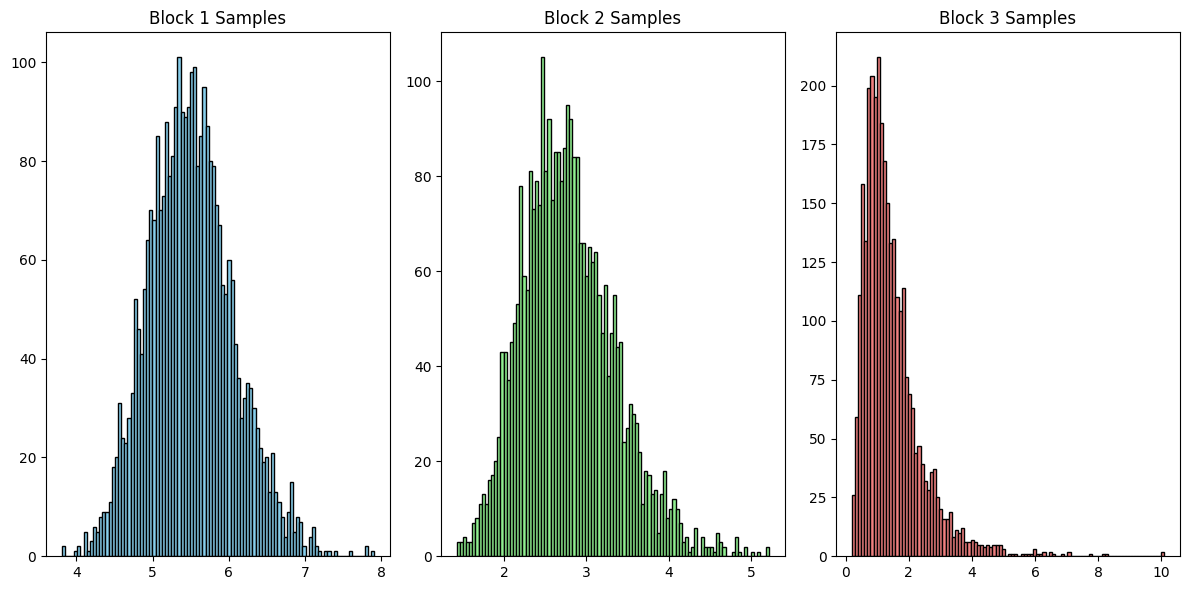


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937522628.9223

--- Iteration 3 ---
Estimated total cost: -709090720.7773

--- Iteration 4 ---
Estimated total cost: 325.3450

--- Iteration 5 ---
Estimated total cost: 332.0472

--- Iteration 6 ---
Estimated total cost: 346.4901

--- Iteration 7 ---
Estimated total cost: 349.5682

--- Iteration 8 ---
Estimated total cost: 349.6741

--- Iteration 9 ---
Estimated total cost: 352.6250

--- Iteration 10 ---
Estimated total cost: 359.1417

--- Iteration 11 ---
Estimated total cost: 364.7987

--- Iteration 12 ---
Estimated total cost: 365.1053

--- Iteration 13 ---
Estimated total cost: 366.8187

--- Iteration 14 ---
Estimated total cost: 366.9734

--- Iteration 15 ---
Estimated total cost: 367.4172

--- Iteration 16 ---
Estimated total cost: 367.4562

--- Iteration 17 ---
Estimated total cost: 367.7910

--- Iteration 18 ---
Estimated total cost: 367.8722

--- Iteration 19 ---
Estimated to

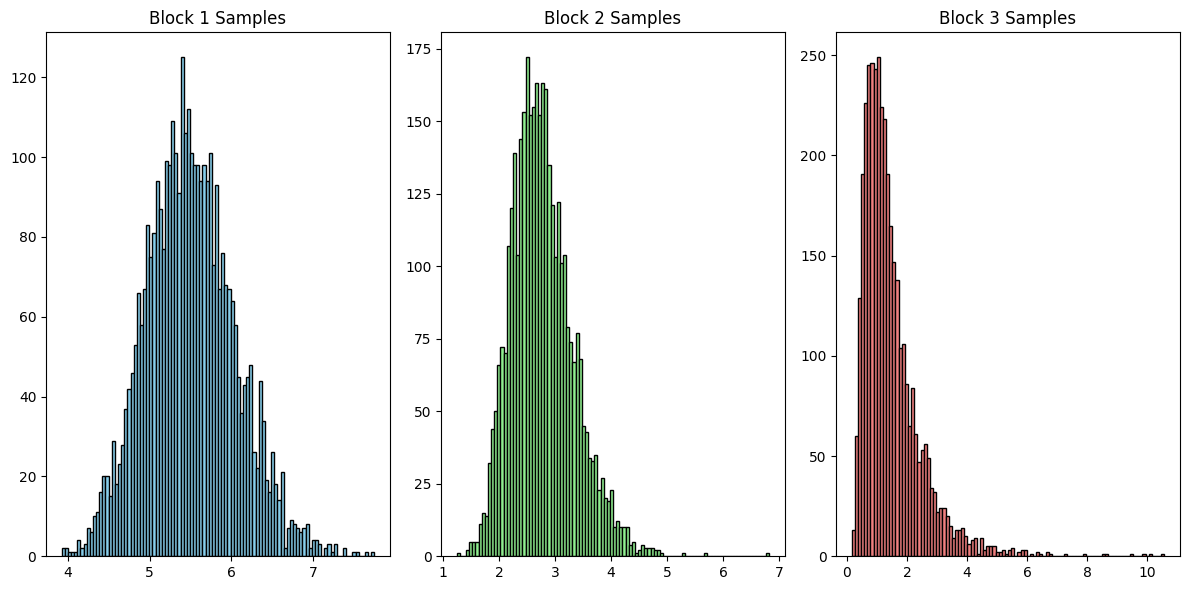


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937537749.5637

--- Iteration 3 ---
Estimated total cost: -709090720.9972

--- Iteration 4 ---
Estimated total cost: 325.0007

--- Iteration 5 ---
Estimated total cost: 331.7025

--- Iteration 6 ---
Estimated total cost: 345.9555

--- Iteration 7 ---
Estimated total cost: 349.2031

--- Iteration 8 ---
Estimated total cost: 349.3095

--- Iteration 9 ---
Estimated total cost: 352.4380

--- Iteration 10 ---
Estimated total cost: 359.1631

--- Iteration 11 ---
Estimated total cost: 364.9354

--- Iteration 12 ---
Estimated total cost: 365.1149

--- Iteration 13 ---
Estimated total cost: 366.5508

--- Iteration 14 ---
Estimated total cost: 366.8332

--- Iteration 15 ---
Estimated total cost: 367.2375

--- Iteration 16 ---
Estimated total cost: 367.3336

--- Iteration 17 ---
Estimated total cost: 367.6872

--- Iteration 18 ---
Estimated total cost: 367.7407

--- Iteration 19 ---
Estimated to

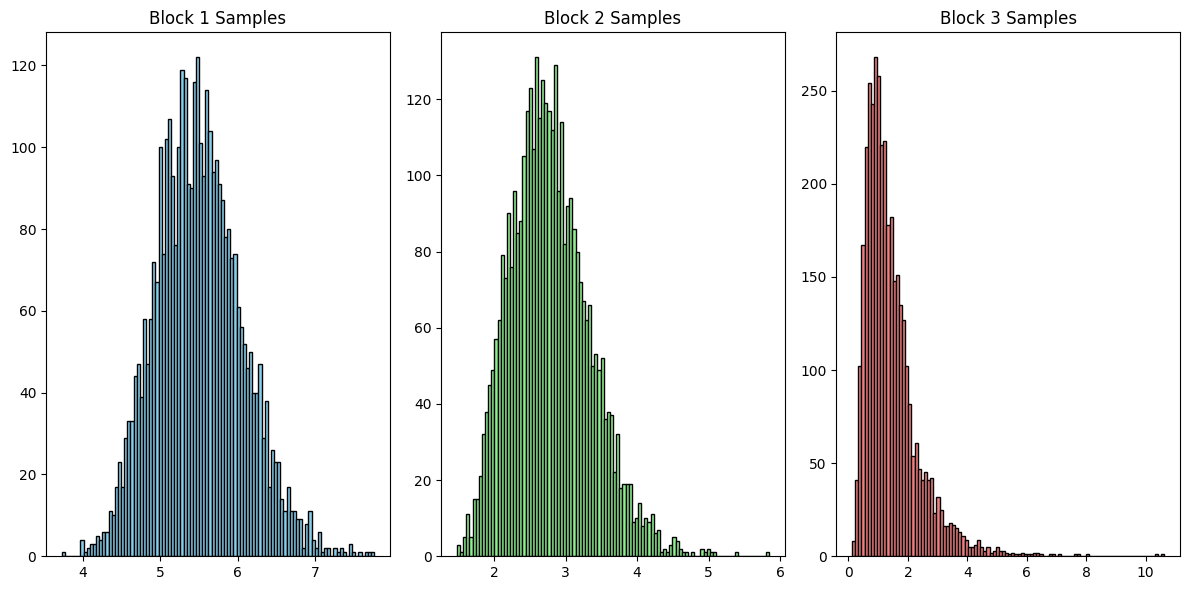


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937528296.2594

--- Iteration 3 ---
Estimated total cost: -709090720.9935

--- Iteration 4 ---
Estimated total cost: 325.0064

--- Iteration 5 ---
Estimated total cost: 331.6633

--- Iteration 6 ---
Estimated total cost: 346.1112

--- Iteration 7 ---
Estimated total cost: 349.1077

--- Iteration 8 ---
Estimated total cost: 349.2480

--- Iteration 9 ---
Estimated total cost: 352.1466

--- Iteration 10 ---
Estimated total cost: 358.7353

--- Iteration 11 ---
Estimated total cost: 364.3094

--- Iteration 12 ---
Estimated total cost: 364.7099

--- Iteration 13 ---
Estimated total cost: 366.5618

--- Iteration 14 ---
Estimated total cost: 366.6197

--- Iteration 15 ---
Estimated total cost: 367.0574

--- Iteration 16 ---
Estimated total cost: 367.0772

--- Iteration 17 ---
Estimated total cost: 367.3926

--- Iteration 18 ---
Estimated total cost: 367.4099

--- Iteration 19 ---
Estimated to

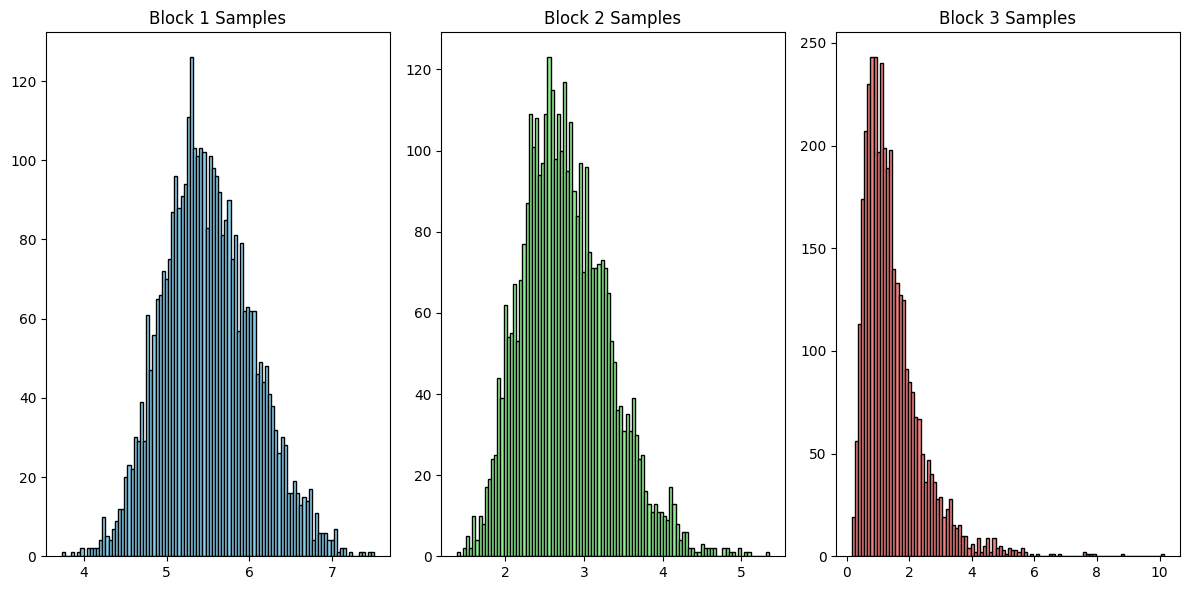


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937528296.2350

--- Iteration 3 ---
Estimated total cost: -709090720.9351

--- Iteration 4 ---
Estimated total cost: 325.0974

--- Iteration 5 ---
Estimated total cost: 331.8040

--- Iteration 6 ---
Estimated total cost: 346.0752

--- Iteration 7 ---
Estimated total cost: 349.1356

--- Iteration 8 ---
Estimated total cost: 349.4317

--- Iteration 9 ---
Estimated total cost: 352.4573

--- Iteration 10 ---
Estimated total cost: 358.9888

--- Iteration 11 ---
Estimated total cost: 364.6454

--- Iteration 12 ---
Estimated total cost: 364.9241

--- Iteration 13 ---
Estimated total cost: 366.7935

--- Iteration 14 ---
Estimated total cost: 366.8675

--- Iteration 15 ---
Estimated total cost: 367.2908

--- Iteration 16 ---
Estimated total cost: 367.2990

--- Iteration 17 ---
Estimated total cost: 367.5874

--- Iteration 18 ---
Estimated total cost: 367.6108

--- Iteration 19 ---
Estimated to

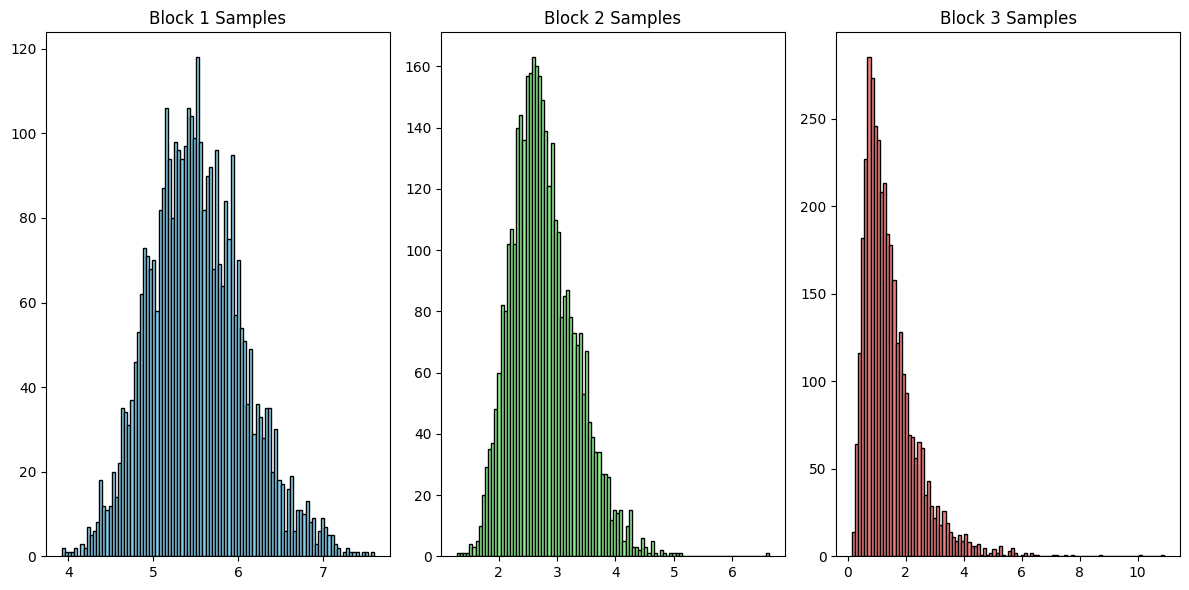


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937531447.6323

--- Iteration 3 ---
Estimated total cost: -709090720.8876

--- Iteration 4 ---
Estimated total cost: 325.1727

--- Iteration 5 ---
Estimated total cost: 331.8434

--- Iteration 6 ---
Estimated total cost: 345.9713

--- Iteration 7 ---
Estimated total cost: 349.1811

--- Iteration 8 ---
Estimated total cost: 349.3274

--- Iteration 9 ---
Estimated total cost: 352.4788

--- Iteration 10 ---
Estimated total cost: 358.9287

--- Iteration 11 ---
Estimated total cost: 364.5234

--- Iteration 12 ---
Estimated total cost: 364.8165

--- Iteration 13 ---
Estimated total cost: 366.6366

--- Iteration 14 ---
Estimated total cost: 366.8225

--- Iteration 15 ---
Estimated total cost: 367.1026

--- Iteration 16 ---
Estimated total cost: 367.1854

--- Iteration 17 ---
Estimated total cost: 367.6439

--- Iteration 18 ---
Estimated total cost: 367.6569

--- Iteration 19 ---
Estimated to

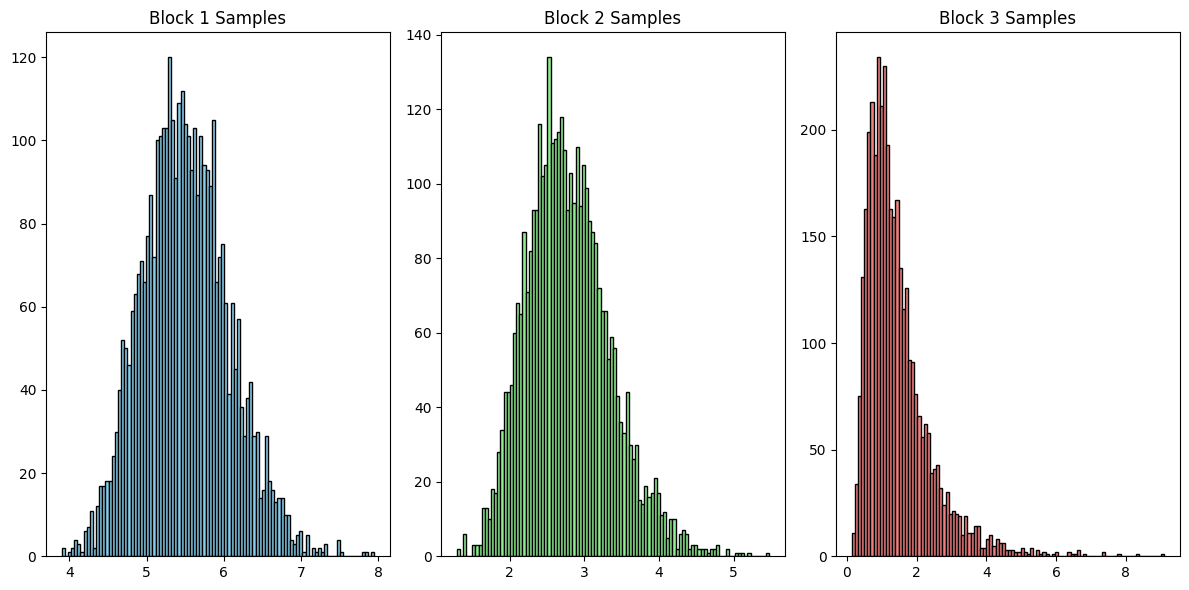


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937537749.4353

--- Iteration 3 ---
Estimated total cost: -709090720.6966

--- Iteration 4 ---
Estimated total cost: 325.4719

--- Iteration 5 ---
Estimated total cost: 332.2034

--- Iteration 6 ---
Estimated total cost: 346.4446

--- Iteration 7 ---
Estimated total cost: 349.7055

--- Iteration 8 ---
Estimated total cost: 349.8336

--- Iteration 9 ---
Estimated total cost: 352.9801

--- Iteration 10 ---
Estimated total cost: 359.6537

--- Iteration 11 ---
Estimated total cost: 365.2174

--- Iteration 12 ---
Estimated total cost: 365.4679

--- Iteration 13 ---
Estimated total cost: 367.1043

--- Iteration 14 ---
Estimated total cost: 367.2633

--- Iteration 15 ---
Estimated total cost: 367.7494

--- Iteration 16 ---
Estimated total cost: 367.7701

--- Iteration 17 ---
Estimated total cost: 368.0198

--- Iteration 18 ---
Estimated total cost: 368.1248

--- Iteration 19 ---
Estimated to

In [35]:
# This code aims at finding the number of scenarios for which the resulting variance for 5 tests will be <= 0.001

S = 500 #start at 500 scenarios
gamma = 1.2
seuil_var = 0.001

while True :
    X = []
    for k in range(5) :
        x, theta, obj = Benders_algorithm(int(S))
        X.append(x)

    var = np.var(X, axis=0)

    if np.max(var) < seuil_var :
        break
    else :
        S*= gamma
    

print(f"Optimal number of scenarios :{S}")


The optimal number of scenarios is then around 4000

Shape of demand scenarios: (4000, 3)


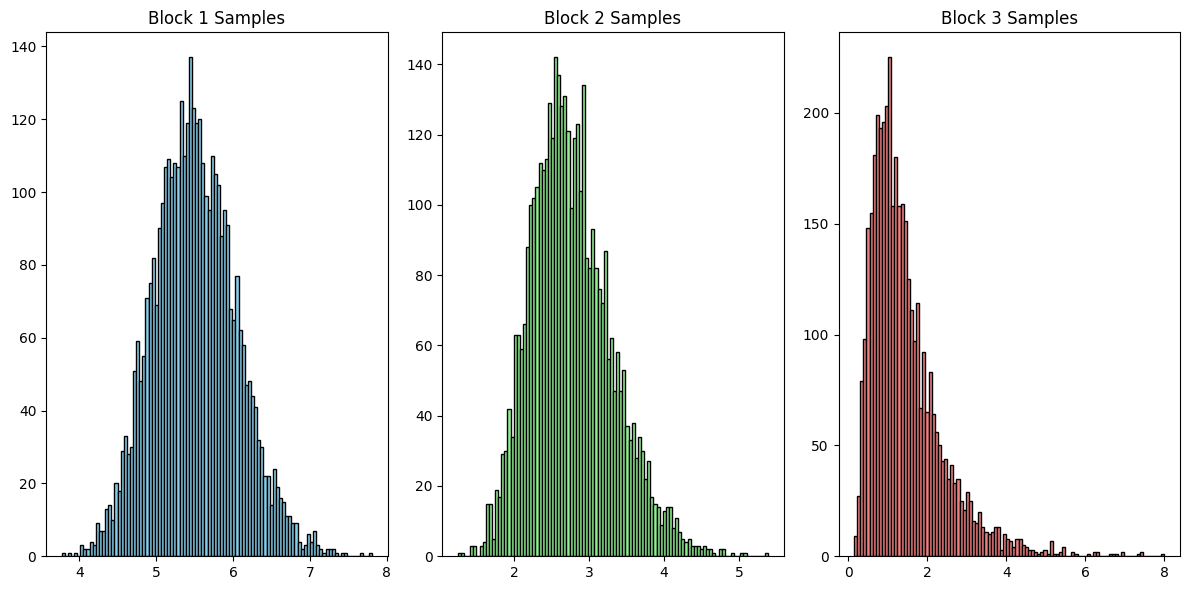


--- Iteration 1 ---
Estimated total cost: -999999970.0000

--- Iteration 2 ---
Estimated total cost: -937526275.2498

--- Iteration 3 ---
Estimated total cost: -709090721.0008

--- Iteration 4 ---
Estimated total cost: 324.9936

--- Iteration 5 ---
Estimated total cost: 331.6962

--- Iteration 6 ---
Estimated total cost: 345.7864

--- Iteration 7 ---
Estimated total cost: 349.0073

--- Iteration 8 ---
Estimated total cost: 349.2381

--- Iteration 9 ---
Estimated total cost: 352.4196

--- Iteration 10 ---
Estimated total cost: 358.7499

--- Iteration 11 ---
Estimated total cost: 364.1640

--- Iteration 12 ---
Estimated total cost: 364.5481

--- Iteration 13 ---
Estimated total cost: 366.5713

--- Iteration 14 ---
Estimated total cost: 366.5769

--- Iteration 15 ---
Estimated total cost: 366.8059

--- Iteration 16 ---
Estimated total cost: 367.0982

--- Iteration 17 ---
Estimated total cost: 367.1069

--- Iteration 18 ---
Estimated total cost: 367.2321

--- Iteration 19 ---
Estimated to

([3.5803737606279684,
  1.6283023341003302,
  5.747728375863685,
  4.043595529408018],
 110.19028812248312,
 367.6322790494862)

In [36]:
Benders_algorithm(4000)


The obtained results are coherent with the classic 2stage SP, which validates our algorithm. Now, let's study the optimal number N for solving the problem.

## Task 3 (5pt)
- Similar to task 1, please construct a CVaR model using small number of samples (100) and solve it directly using solver.
- choose confidence level $\alpha = 0.90, 0.95, 0.99$.
- report the results.

Shape of demand scenarios: (100, 3)


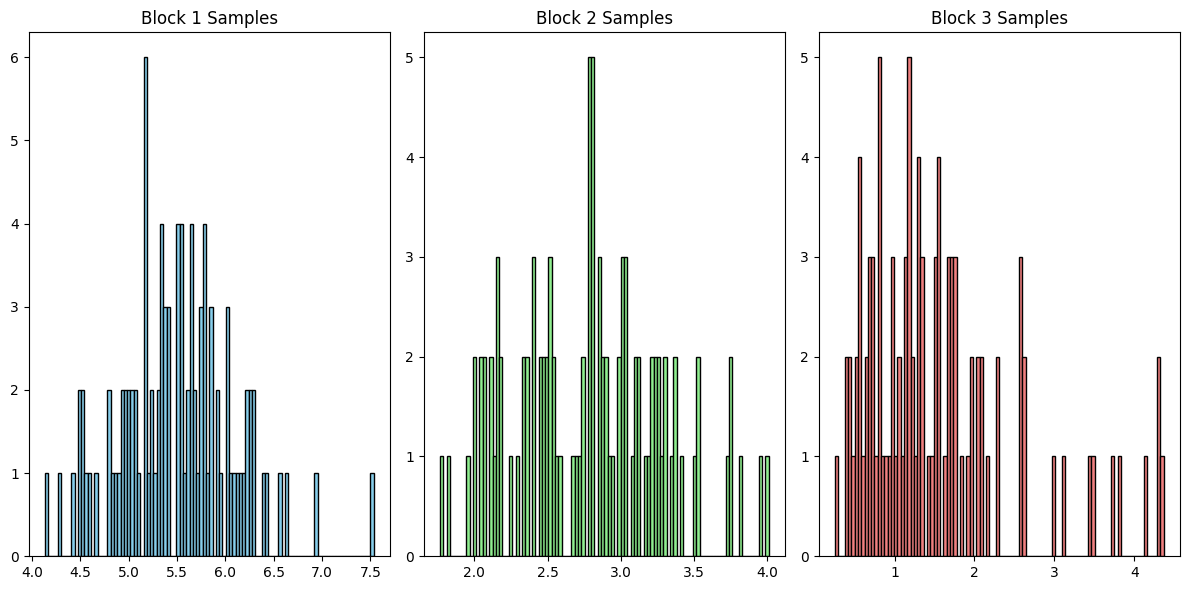

In [7]:
# Number of generator types and load blocks
J = 4  # Generator types: coal, gas, nuclear, oil
I = 3  # Load blocks: base, medium, peak

# Costs (in €/MWh)
c_inv = np.array([16, 5, 32, 2])  # Investment costs
c_prod = np.array([25, 80, 6.5, 160])  # Production costs
c_penl = np.array([180, 200, 220])  # Load shedding costs

# Load curve weights (normalized)
beta = np.array([1, 0.8, 0.25])

# Minimum capacity to be installed
P = 15


# Parameters for the distributions
mu_1, sigma_1 = 1.7, 0.1
mu_2, sigma_2 = 1.0, 0.2
mu_3, sigma_3 = 0.2, 0.6

# Construct the distribution objects
dist_block_1 = rb.Distributions.Lognormal_Distribution(mu_1, sigma_1)
dist_block_2 = rb.Distributions.Lognormal_Distribution(mu_2, sigma_2)
dist_block_3 = rb.Distributions.Lognormal_Distribution(mu_3, sigma_3)


# Number of scenarios to generate
num_scenarios = 100

# Generate samples from each distribution
samp_block_1 = dist_block_1.random_samples(num_scenarios)
samp_block_2 = dist_block_2.random_samples(num_scenarios)
samp_block_3 = dist_block_3.random_samples(num_scenarios)

# Combine scenarios into a matrix
demand_scenarios = np.vstack((samp_block_1, samp_block_2, samp_block_3)).T

# Print the shape of the demand scenarios matrix
print("Shape of demand scenarios:", demand_scenarios.shape)


# Visualize the samples
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.hist(samp_block_1, bins=100, color='skyblue', edgecolor='black')
plt.title('Block 1 Samples')

plt.subplot(1, 3, 2)
plt.hist(samp_block_2, bins=100, color='lightgreen', edgecolor='black')
plt.title('Block 2 Samples')

plt.subplot(1, 3, 3)
plt.hist(samp_block_3, bins=100, color='lightcoral', edgecolor='black')
plt.title('Block 3 Samples')

plt.tight_layout()
plt.show()


In [9]:
def two_stage_SP_CVaR(J, I, P, c_inv, c_prod, c_penl, beta, demand_scenarios, alpha=0.9):
    S = len(demand_scenarios)

    model = gp.Model("StochasticPowerGeneration_CVaR")

    # === Variables ===
    x = model.addVars(J, name="x", lb=0)
    y = model.addVars(I, J, S, name="y", lb=0)
    p = model.addVars(I, S, name="p", lb=0)
    eta = model.addVar(name="eta", lb=-GRB.INFINITY)
    xi = model.addVars(S, name="xi", lb=0)

    # === Constraints ===

    # Capacity constraint
    model.addConstr(gp.quicksum(x[j] for j in range(J)) >= P, name="capacity")

    # Generator limits (for each generator and scenario)
    for j in range(J):
        for s in range(S):
            model.addConstr(gp.quicksum(y[i, j, s] for i in range(I)) <= x[j], name=f"gen_cap_{j}_{s}")

    # Demand satisfaction (per block and scenario)
    for i in range(I):
        for s in range(S):
            model.addConstr(gp.quicksum(y[i, j, s] for j in range(J)) + p[i, s] >= demand_scenarios[s, i], name=f"demand_{i}_{s}")

    # CVaR excess cost constraints
    for s in range(S):
        scenario_cost = gp.quicksum(beta[i] * (gp.quicksum(c_prod[j] * y[i, j, s] for j in range(J)) + c_penl[i] * p[i, s]) for i in range(I))
        model.addConstr(xi[s] >= scenario_cost - eta, name=f"cvar_excess_{s}")

    # === Objective: Investment + CVaR ===
    investment_cost = gp.quicksum(c_inv[j] * x[j] for j in range(J))
    cvar_term = eta + (1 / ((1 - alpha) * S)) * gp.quicksum(xi[s] for s in range(S))
    model.setObjective(investment_cost + cvar_term, GRB.MINIMIZE)

    # === Solve ===
    model.optimize()

    # === Output ===
    if model.status == GRB.OPTIMAL:
        print("\n--- CVaR 2-Stage SP Solution ---")
        for j in range(J):
            print(f"Generator {j+1}: {x[j].x:.2f} MW")
        print(f"VaR (eta): {eta.x:.2f}")
        print(f"CVaR cost: {model.ObjVal:.2f}")
        return [x[j].x for j in range(J)], eta.x, model.ObjVal
    else:
        print("No optimal solution found.")
        return None, None, None


In [10]:
x_star, eta_star, cvar_total = two_stage_SP_CVaR(
    J=4,
    I=3,
    P=15,
    c_inv=[16, 5, 32, 2],
    c_prod=[25, 80, 6.5, 160],
    c_penl=[180, 200, 220],
    beta=[1, 0.8, 0.25],
    demand_scenarios=demand_scenarios,
    alpha=0.9
)


Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Manjaro Linux")

CPU model: Intel(R) Core(TM) i5-1035G4 CPU @ 1.10GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 801 rows, 1605 columns and 4804 nonzeros
Model fingerprint: 0xff0cd7eb
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e-01, 3e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e-01, 2e+01]
Presolve time: 0.02s
Presolved: 801 rows, 1605 columns, 4804 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
     685    4.3428200e+02   0.000000e+00   0.000000e+00      0s

Solved in 685 iterations and 0.03 seconds (0.01 work units)
Optimal objective  4.342819965e+02

--- CVaR 2-Stage SP Solution ---
Generator 1: 5.07 MW
Generator 2: 2.23 MW
Generator 3: 6.28 MW
Generator 4: 1.42 MW
VaR (eta): 116.63
CVaR

In [14]:
obj = []
x = []
alphas = [0.90, 0.95, 0.99]
for alpha in alphas:
    # change model parameter alpha to the value of interest
    # solve the model
    # report the objective and decision variable

    x_star, eta_star, cvar_total = two_stage_SP_CVaR(
    J=4,
    I=3,
    P=15,
    c_inv=[16, 5, 32, 2],
    c_prod=[25, 80, 6.5, 160],
    c_penl=[180, 200, 220],
    beta=[1, 0.8, 0.25],
    demand_scenarios=demand_scenarios,
    alpha=alpha)

    obj.append(cvar_total)
    x.append(x_star)



for k in range(3) :
    print(f'alpha = {alphas[k]}')
    print(f'Objective = {obj[k]}')
    print(f'x = {x[k]}')

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Manjaro Linux")

CPU model: Intel(R) Core(TM) i5-1035G4 CPU @ 1.10GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 801 rows, 1605 columns and 4804 nonzeros
Model fingerprint: 0xff0cd7eb
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  Objective range  [1e-01, 3e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e-01, 2e+01]
Presolve time: 0.00s
Presolved: 801 rows, 1605 columns, 4804 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0      handle free variables                          0s
     685    4.3428200e+02   0.000000e+00   0.000000e+00      0s

Solved in 685 iterations and 0.02 seconds (0.01 work units)
Optimal objective  4.342819965e+02

--- CVaR 2-Stage SP Solution ---
Generator 1: 5.07 MW
Generator 2: 2.23 MW
Generator 3: 6.28 MW
Generator 4: 1.42 MW
VaR (eta): 116.63
CVaR

## Task 4 (5pt)
- You have determined the number of samples $N$ in task 2.
- Use the same number $N$ and construct a large scale CVaR problem.
- Think about it:
  - How the same algorithm can be used for CVaR problem?
  - For a standard Stochastic Program, is it equivalent to a CVaR problem with a specific $\alpha$ value?
- Solve it by the algorithm you designed in task 2.
- report the results for different $\alpha$ values as in task 3.

In [19]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import matplotlib.pyplot as plt
import reliability as rb

def Benders_algorithm_cvar(num_scenarios, alpha=0.9):
    # === Problem Data ===
    J, I = 4, 3
    P = 15

    c_inv = np.array([16, 5, 32, 2])
    c_prod = np.array([25, 80, 6.5, 160])
    c_penl = np.array([180, 200, 220])
    beta = np.array([1, 0.8, 0.25])

    # === Demand Distributions ===
    mu_1, sigma_1 = 1.7, 0.1
    mu_2, sigma_2 = 1.0, 0.2
    mu_3, sigma_3 = 0.2, 0.6

    dist_block_1 = rb.Distributions.Lognormal_Distribution(mu_1, sigma_1)
    dist_block_2 = rb.Distributions.Lognormal_Distribution(mu_2, sigma_2)
    dist_block_3 = rb.Distributions.Lognormal_Distribution(mu_3, sigma_3)

    samp_block_1 = dist_block_1.random_samples(num_scenarios)
    samp_block_2 = dist_block_2.random_samples(num_scenarios)
    samp_block_3 = dist_block_3.random_samples(num_scenarios)

    demand_scenarios = np.vstack((samp_block_1, samp_block_2, samp_block_3)).T
    print("Shape of demand scenarios:", demand_scenarios.shape)

    # === Subproblem ===
    def solve_subproblem(x_val, demand):
        sub = gp.Model("Sub")
        sub.setParam("OutputFlag", 0)

        y = sub.addVars(I, J, lb=0, name="y")
        p = sub.addVars(I, lb=0, name="p")

        demand_constrs = []
        for i in range(I):
            con = sub.addConstr(gp.quicksum(y[i, j] for j in range(J)) + p[i] >= demand[i])
            demand_constrs.append(con)

        gen_constrs = []
        for j in range(J):
            con = sub.addConstr(gp.quicksum(y[i, j] for i in range(I)) <= x_val[j])
            gen_constrs.append(con)

        sub.setObjective(
            gp.quicksum(beta[i] * (
                gp.quicksum(c_prod[j] * y[i, j] for j in range(J)) + c_penl[i] * p[i]
            ) for i in range(I)), GRB.MINIMIZE
        )

        sub.optimize()

        if sub.status == GRB.OPTIMAL:
            obj_val = sub.ObjVal
            lambda_duals = [con.Pi for con in demand_constrs]
            mu_duals = [con.Pi for con in gen_constrs]
            return obj_val, lambda_duals, mu_duals
        else:
            return None, None, None

    # === Master Problem ===
    master = gp.Model("master")
    master.setParam("OutputFlag", 0)

    x = master.addVars(J, lb=0, name="x")
    eta = master.addVar(lb=-1e8, name="eta")
    xi = master.addVars(num_scenarios, lb=0, name="xi")  # One per scenario

    master.addConstr(gp.quicksum(x[j] for j in range(J)) >= P)

    # Objective: investment + CVaR
    master.setObjective(
        gp.quicksum(c_inv[j] * x[j] for j in range(J)) +
        eta +
        (1 / ((1 - alpha) * num_scenarios)) * gp.quicksum(xi[s] for s in range(num_scenarios)),
        GRB.MINIMIZE
    )

    # === Benders Loop ===
    max_iter = 50
    tolerance = 1e-3
    prev_obj = 1e10

    for it in range(max_iter):
        print(f"\n--- Iteration {it+1} ---")
        master.optimize()

        if master.status != GRB.OPTIMAL:
            print("Master problem not optimal.")
            break

        x_val = [x[j].x for j in range(J)]
        eta_val = eta.x

        avg_cut_expr = 0
        avg_rhs = 0

        for s in range(num_scenarios):
            demand = demand_scenarios[s]
            obj, lambda_duals, mu_duals = solve_subproblem(x_val, demand)
            if obj is None:
                continue

            # θ_s (cost for this scenario) ≥ dual expression
            cut_expr = gp.LinExpr()
            for j in range(J):
                cut_expr += mu_duals[j] * x[j]
            rhs = sum(lambda_duals[i] * demand[i] for i in range(I))

            avg_cut_expr+=cut_expr/num_scenarios
            avg_rhs+=rhs/num_scenarios

            # CVaR-specific constraint:
            # xi_s ≥ Q^s(x) - eta
        master.addConstr(xi[s] >= avg_cut_expr + avg_rhs - eta, name=f"cvar_excess_{it}_{s}")

        # Convergence check
        curr_obj = master.ObjVal
        print(f"Estimated CVaR total cost: {curr_obj:.4f}")
        if abs(curr_obj - prev_obj) < tolerance:
            print("Converged.")
            break
        prev_obj = curr_obj

    # === Final Output ===
    print("\n--- Final Solution (CVaR) ---")
    for j in range(J):
        print(f"Generator {j}: {x[j].x:.2f} MW")
    print(f"VaR (eta): {eta.x:.2f}")
    print(f"CVaR total cost: {master.ObjVal:.2f}")

    return [x[j].x for j in range(J)], eta.x, master.ObjVal


In [23]:



obj = []
x = []
alphas = [0.90, 0.95, 0.99]
for alpha in alphas:
    # change model parameter alpha to the value of interest
    # solve the model
    # report the objective and decision variable

    x_star, eta_star, cvar_cost = Benders_algorithm_cvar(num_scenarios=4000, alpha=alpha)



for k in range(3) :
    print(f'alpha = {alphas[k]}')
    print(f'Objective = {obj[k]}')
    print(f'x = {x[k]}')

Shape of demand scenarios: (4000, 3)

--- Iteration 1 ---
Estimated CVaR total cost: -99999970.0000

--- Iteration 2 ---
Estimated CVaR total cost: -99749966.7633

--- Iteration 3 ---
Estimated CVaR total cost: -99749966.7633
Converged.

--- Final Solution (CVaR) ---
Generator 0: 0.00 MW
Generator 1: 0.00 MW
Generator 2: 0.00 MW
Generator 3: 15.00 MW
VaR (eta): -100000000.00
CVaR total cost: -99749966.76
Shape of demand scenarios: (4000, 3)

--- Iteration 1 ---
Estimated CVaR total cost: -99999970.0000

--- Iteration 2 ---
Estimated CVaR total cost: -99499963.5228

--- Iteration 3 ---
Estimated CVaR total cost: -99499963.5228
Converged.

--- Final Solution (CVaR) ---
Generator 0: 0.00 MW
Generator 1: 0.00 MW
Generator 2: 0.00 MW
Generator 3: 15.00 MW
VaR (eta): -100000000.00
CVaR total cost: -99499963.52
Shape of demand scenarios: (4000, 3)

--- Iteration 1 ---
Estimated CVaR total cost: -99999970.0000

--- Iteration 2 ---
Estimated CVaR total cost: -97499937.6242

--- Iteration 3 ---


IndexError: list index out of range

# Good Luck!
- Don't forget to run it and save it with all the running log for each code block.
- my email address is xie.zhuojun@centralesupelec.fr
- subject of the email: [SO-2025-P1-Your Name] 
- please use English letters without accent.